# Подготовка и анализ результатов исследования алгоритмов поиска пути на плоскости с круговыми препятствиями

Дополнение к дипломной работе "Структурные и геометрические параметры среды в алгоритмах поиска пути на плоскости с круговыми препятствиями" студента Павлючика Антона Михайловича.

Ноутбук последовательно проходит путь от загрузки экспериментальных файлов до статистического анализа, визуализаций и модели выбора предпочтительного алгоритма по характеристикам сцены.

## 1. Настройка окружения

Подключаются библиотеки, определяется корень проекта и загружается parser экспериментальных данных.

In [58]:
import importlib
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

In [59]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        parser_path = candidate / 'src' / 'tools' / 'experiment_dataset_parser.py'
        if parser_path.exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/tools/experiment_dataset_parser.py')


PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / 'src'
NOTEBOOK_DIR = PROJECT_ROOT / 'python'

In [60]:
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from tools import experiment_dataset_parser as experiment_dataset_parser

experiment_dataset_parser = importlib.reload(experiment_dataset_parser)
save_dataset_bundle = experiment_dataset_parser.save_dataset_bundle
build_experiment_dataset = experiment_dataset_parser.build_experiment_dataset
build_analysis_run_dataset = experiment_dataset_parser.build_analysis_run_dataset
load_or_build_experiment_dataset = experiment_dataset_parser.load_or_build_experiment_dataset

## 2. Загрузка экспериментального набора

Данные берутся из финальной серии экспериментов, при наличии актуального кэша используется сохраненная версия датасета.

In [61]:
EXPERIMENTS_DIR = SRC_DIR / 'configs' / 'studies' / 'final_25' / 'experiment_runs'
OUTPUT_DIR = NOTEBOOK_DIR / 'analysis_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATASET_PREFIX = 'final25'
FORCE_REBUILD = False

In [62]:
bundle, bundle_cache_info = load_or_build_experiment_dataset(
    EXPERIMENTS_DIR,
    OUTPUT_DIR,
    prefix=DATASET_PREFIX,
    force_rebuild=FORCE_REBUILD,
)
saved_paths = dict(bundle_cache_info.get('saved_paths', {}))

analysis_run_df = getattr(bundle, 'analysis_run_df', None)
if analysis_run_df is None or analysis_run_df.empty:
    analysis_run_df = build_analysis_run_dataset(bundle.run_df)

summary = dict(getattr(bundle, 'summary', {}))
summary.setdefault('analysis_run_row_count', int(len(analysis_run_df)))
summary.setdefault('executed_run_count', int(bundle.run_df['algorithm_was_executed'].fillna(False).sum()))
summary.setdefault('not_run_count', int((bundle.run_df['algorithm_status'] == 'NotRun').sum()))
summary.setdefault('scene_row_count', int(len(bundle.scene_df)))

42400

In [63]:
summary_df = pd.DataFrame([summary])

cache_status_df = pd.DataFrame([
    {
        'dataset_source': bundle_cache_info.get('mode', ''),
        'cache_available': bool(bundle_cache_info.get('cache_available', False)),
        'cache_is_fresh': bool(bundle_cache_info.get('is_fresh', False)),
        'force_rebuild': FORCE_REBUILD,
        'cache_note': bundle_cache_info.get('reason', ''),
    }
])

display(cache_status_df)
display(summary_df)
display(bundle.file_df.head())

,dataset_source,cache_available,cache_is_fresh,force_rebuild,cache_note
0,cache,True,True,False,


,experiment_file_count,run_row_count,analysis_run_row_count,scene_row_count,theoretical_max_run_rows,actual_run_rows,executed_run_count,not_run_count,generated_scene_count,completed_scene_count,path_found_run_count,failed_run_count
0,53,212000,212000,42400,212000,212000,211685,315,42337,42337,202284,0


,experiment_file,experiment_path,config_index,experiment_name,config_name,experiment_status,scene_count_declared,actual_scene_rows,generated_scene_count,completed_scene_count,any_path_scene_count,enabled_algorithm_count,theoretical_max_run_rows,actual_run_rows,executed_run_count,not_run_count,path_found_run_count,failed_run_count
0,exp_config_01_experiment.json,Q:\Diploma\src\configs\studies\final_25\experi...,1,final25_compact_uniform_micro_open,final25_compact_uniform_micro_open,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0
1,exp_config_02_experiment.json,Q:\Diploma\src\configs\studies\final_25\experi...,2,final25_compact_uniform_micro_balanced_dense,final25_compact_uniform_micro_balanced_dense,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0
2,exp_config_03_experiment.json,Q:\Diploma\src\configs\studies\final_25\experi...,3,final25_compact_uniform_dense_wide_radii,final25_compact_uniform_dense_wide_radii,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0
3,exp_config_04_experiment.json,Q:\Diploma\src\configs\studies\final_25\experi...,4,final25_compact_mixed_scale_patchy_large,final25_compact_mixed_scale_patchy_large,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0
4,exp_config_05_experiment.json,Q:\Diploma\src\configs\studies\final_25\experi...,5,final25_medium_large_disks_sparse_plus,final25_medium_large_disks_sparse_plus,Completed,800,800,800,800,800,5,4000,4000,4000,0,4000,0


Данные экспериментов загружены. Далее фиксируются объем выборки, источник данных и назначение основных промежуточных таблиц.

In [64]:
print('Строк-слотов алгоритмов:', bundle.summary['analysis_run_row_count'])
print('Выполненных запусков:', bundle.summary['executed_run_count'])
print('NotRun-слотов:', bundle.summary['not_run_count'])
print('Строк сцен:', bundle.summary['scene_row_count'])

print('Источник набора:', bundle_cache_info.get('mode', ''))
if bundle_cache_info.get('reason'):
    print('Комментарий к кэшу:', bundle_cache_info['reason'])

Строк-слотов алгоритмов: 212000
Выполненных запусков: 211685
NotRun-слотов: 315
Строк сцен: 42400
Источник набора: cache


### Карта промежуточных таблиц

Эта таблица фиксирует назначение основных датасетов, чтобы дальше было понятно, на каком уровне агрегации выполняется анализ.

In [65]:
dataset_map_df = pd.DataFrame([
    {
        'dataset': 'raw_experiment_json',
        'granularity': '1 file = 1 конфиг + все сцены и все запуски внутри',
        'location': str(EXPERIMENTS_DIR),
        'purpose': 'источник истины: полная геометрия scene_data, препятствия, runs',
    },
    {
        'dataset': 'bundle.run_df',
        'granularity': '1 row = 1 запуск алгоритма на 1 сцене',
        'location': saved_paths.get('runs', ''),
        'purpose': 'сырой run-level extract из experiment json',
    },
    {
        'dataset': 'analysis_run_df',
        'granularity': '1 row = 1 запуск алгоритма на 1 сцене',
        'location': saved_paths.get('runs_analysis', ''),
        'purpose': 'основной run-level датасет для анализа алгоритмов',
    },
    {
        'dataset': 'bundle.scene_df',
        'granularity': '1 row = 1 сцена',
        'location': saved_paths.get('scenes', ''),
        'purpose': 'scene-level summary и метрики сцены без дублирования по алгоритмам',
    },
    {
        'dataset': 'bundle.file_df',
        'granularity': '1 row = 1 experiment file / config',
        'location': saved_paths.get('files', ''),
        'purpose': 'агрегаты по конфигам и контроль полноты эксперимента',
    },
    {
        'dataset': 'analysis_compact_df',
        'granularity': '1 row = 1 запуск алгоритма на 1 сцене',
        'location': str(OUTPUT_DIR / f'{DATASET_PREFIX}_runs_compact.parquet'),
        'purpose': 'компактная выборка основных колонок; создается позже в ноутбуке',
    },
    {
        'dataset': 'scene_analysis_df',
        'granularity': '1 row = 1 успешно сгенерированная сцена',
        'location': str(OUTPUT_DIR / f'{DATASET_PREFIX}_scene_analysis.parquet'),
        'purpose': 'scene-level срез для анализа вариативности и связей метрик среды',
    },
])

In [66]:
with pd.option_context('display.max_columns', None, 'display.width', 2400, 'display.max_colwidth', 160):
    display(dataset_map_df)

saved_paths

,dataset,granularity,location,purpose
0,raw_experiment_json,1 file = 1 конфиг + все сцены и все запуски внутри,Q:\Diploma\src\configs\studies\final_25\experiment_runs,"источник истины: полная геометрия scene_data, препятствия, runs"
1,bundle.run_df,1 row = 1 запуск алгоритма на 1 сцене,Q:\Diploma\python\analysis_outputs\final25_runs.parquet,сырой run-level extract из experiment json
2,analysis_run_df,1 row = 1 запуск алгоритма на 1 сцене,Q:\Diploma\python\analysis_outputs\final25_runs_analysis.parquet,основной run-level датасет для анализа алгоритмов
3,bundle.scene_df,1 row = 1 сцена,Q:\Diploma\python\analysis_outputs\final25_scenes.parquet,scene-level summary и метрики сцены без дублирования по алгоритмам
4,bundle.file_df,1 row = 1 experiment file / config,Q:\Diploma\python\analysis_outputs\final25_files.parquet,агрегаты по конфигам и контроль полноты эксперимента
5,analysis_compact_df,1 row = 1 запуск алгоритма на 1 сцене,Q:\Diploma\python\analysis_outputs\final25_runs_compact.parquet,компактная выборка основных колонок; создается позже в ноутбуке
6,scene_analysis_df,1 row = 1 успешно сгенерированная сцена,Q:\Diploma\python\analysis_outputs\final25_scene_analysis.parquet,scene-level срез для анализа вариативности и связей метрик среды


{'runs': 'Q:\\Diploma\\python\\analysis_outputs\\final25_runs.parquet',
 'runs_analysis': 'Q:\\Diploma\\python\\analysis_outputs\\final25_runs_analysis.parquet',
 'scenes': 'Q:\\Diploma\\python\\analysis_outputs\\final25_scenes.parquet',
 'files': 'Q:\\Diploma\\python\\analysis_outputs\\final25_files.parquet',
 'summary': 'Q:\\Diploma\\python\\analysis_outputs\\final25_summary.json'}

### Мастер-представление запусков

Формируется рабочий срез run-level данных: одна строка соответствует запуску конкретного алгоритма на конкретной сцене.

In [67]:
HEAD_COLUMNS = [
    'config_index',
    'config_name',
    'scene_id',
    'scene_index',
    'scene_seed',
    'scene_generation_status',
    'scene_run_status',
    'scene_width',
    'scene_height',
    'scene_obstacle_count',
    'scene_direct_distance',
    'algorithm_id',
    'algorithm_status',
    'algorithm_was_executed',
    'path_found',
    'runtime_ms',
    'path_length',
    'relative_path_length',
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'algorithm_params_json',
]

In [68]:
missing_columns = [column for column in HEAD_COLUMNS if column not in analysis_run_df.columns]
if missing_columns:
    raise KeyError(f'Missing columns in analysis_run_df: {missing_columns}')

analysis_view_df = analysis_run_df[HEAD_COLUMNS].copy()
analysis_view_df.shape

(212000, 25)

In [69]:
display(analysis_view_df.head(15))

,config_index,config_name,scene_id,scene_index,scene_seed,scene_generation_status,scene_run_status,scene_width,scene_height,scene_obstacle_count,...,runtime_ms,path_length,relative_path_length,scene_metric_obstacle_area_ratio,scene_metric_boundary_density,scene_metric_cell_density_cv,scene_metric_radii_cv,scene_metric_clearance,scene_metric_largest_component_ratio,algorithm_params_json
0,1,final25_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,12.1930,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5}"
1,1,final25_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,12.3522,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5}"
2,1,final25_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,0.0161,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""enable_path_smoothing"": true, ""goal_sample_r..."
3,1,final25_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,80.0910,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""points_per_obstacle"": 16}"
4,1,final25_compact_uniform_micro_open,scene_1,1,92501,Generated,Completed,90.0,90.0,46,...,84.4803,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0,"{""points_per_obstacle"": 16}"
5,1,final25_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,11.7645,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5}"
6,1,final25_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,12.2405,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""allow_diagonal"": true, ""grid_step"": 3.5}"
7,1,final25_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,0.0086,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""enable_path_smoothing"": true, ""goal_sample_r..."
8,1,final25_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,66.9120,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""points_per_obstacle"": 16}"
9,1,final25_compact_uniform_micro_open,scene_2,2,92502,Generated,Completed,90.0,90.0,44,...,71.1169,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0,"{""points_per_obstacle"": 16}"


Компактная выборка сохраняет только колонки, которые нужны для основного анализа. Это делает дальнейшие таблицы и графики проще для проверки.

## Выборка данных

Ниже формируется отдельный компактный датасет по выбранным колонкам. Он сохраняется в `analysis_outputs` и используется как удобная основа для дальнейшего анализа.

In [70]:
COMPACT_ANALYSIS_COLUMNS = [
    'scene_generation_status',
    'scene_run_status',
    'scene_direct_distance',
    'algorithm_id',
    'algorithm_status',
    'algorithm_was_executed',
    'path_found',
    'runtime_ms',
    'path_length',
    'relative_path_length',
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
]

missing_compact_columns = [
    column for column in COMPACT_ANALYSIS_COLUMNS if column not in analysis_run_df.columns
]
if missing_compact_columns:
    raise KeyError(f'Missing columns in analysis_run_df: {missing_compact_columns}')

In [71]:
analysis_compact_df = analysis_run_df[COMPACT_ANALYSIS_COLUMNS].copy()
compact_output_path = OUTPUT_DIR / f'{DATASET_PREFIX}_runs_compact.parquet'
analysis_compact_df.to_parquet(compact_output_path, index=False)

print('Compact dataset rows:', len(analysis_compact_df))
print('Compact dataset columns:', len(analysis_compact_df.columns))
print(f'Saved to: {compact_output_path}')

analysis_compact_df.shape

Compact dataset rows: 212000
Compact dataset columns: 16
Saved to: Q:\Diploma\python\analysis_outputs\final25_runs_compact.parquet


(212000, 16)

In [72]:
with pd.option_context('display.max_columns', None, 'display.width', 2000, 'display.max_colwidth', 200):
    display(analysis_compact_df.head(15))

,scene_generation_status,scene_run_status,scene_direct_distance,algorithm_id,algorithm_status,algorithm_was_executed,path_found,runtime_ms,path_length,relative_path_length,scene_metric_obstacle_area_ratio,scene_metric_boundary_density,scene_metric_cell_density_cv,scene_metric_radii_cv,scene_metric_clearance,scene_metric_largest_component_ratio
0,Generated,Completed,68.126456,grid_astar,Success,True,True,12.1930,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
1,Generated,Completed,68.126456,grid_dijkstra,Success,True,True,12.3522,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
2,Generated,Completed,68.126456,rrt,Success,True,True,0.0161,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
3,Generated,Completed,68.126456,visibility_astar,Success,True,True,80.0910,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
4,Generated,Completed,68.126456,visibility_dijkstra,Success,True,True,84.4803,68.126456,1.000000,0.0313,0.045626,1.830641,0.225328,0.964286,1.0
5,Generated,Completed,91.411125,grid_astar,Success,True,True,11.7645,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
6,Generated,Completed,91.411125,grid_dijkstra,Success,True,True,12.2405,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
7,Generated,Completed,91.411125,rrt,Success,True,True,0.0086,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
8,Generated,Completed,91.411125,visibility_astar,Success,True,True,66.9120,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0
9,Generated,Completed,91.411125,visibility_dijkstra,Success,True,True,71.1169,91.411125,1.000000,0.0321,0.044950,1.891669,0.203071,0.964286,1.0


## Интерпретация метрик пути

path_length - абсолютная длина найденного пути в координатах сцены.

relative_path_length - отношение длины найденного пути к прямому расстоянию между стартом и целью: path_length / direct_distance(start, goal).

Значение около 1 соответствует почти прямому маршруту. Чем показатель выше, тем сильнее алгоритм вынужден обходить препятствия.

## Вариативность метрик среды

Для анализа разнообразия сред целесообразно перейти к представлению **одна строка = одна сцена**, чтобы не дублировать метрики по всем алгоритмам. Ниже строится отдельный scene-level срез только для успешно сгенерированных сцен.

Также расчитаем характеристики и распределения метрик сцен, чтобы оценить уровень покрытия различных ситуаций для тестов алгоритмов.

In [73]:
SCENE_METRIC_COLUMNS = [
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_metric_obstacle_area_ratio',
    'scene_metric_radii_cv',
]

SCENE_METRIC_LABELS = {
    'scene_metric_boundary_density': 'boundary density',
    'scene_metric_cell_density_cv': 'cell density CV',
    'scene_metric_clearance': 'clearance',
    'scene_metric_largest_component_ratio': 'largest component ratio',
    'scene_metric_obstacle_area_ratio': 'obstacle area ratio',
    'scene_metric_radii_cv': 'radii CV',
}

SCENE_METRIC_DISPLAY_NAMES = [SCENE_METRIC_LABELS[c] for c in SCENE_METRIC_COLUMNS]

SCENE_ANALYSIS_COLUMNS = [
    'config_index',
    'config_name',
    'scene_id',
    'scene_width',
    'scene_height',
    'scene_area',
    'scene_obstacle_count',
    'scene_direct_distance',
    *SCENE_METRIC_COLUMNS,
]

In [74]:
scene_analysis_df = bundle.scene_df.loc[
    bundle.scene_df['scene_is_generated'].fillna(False),
    SCENE_ANALYSIS_COLUMNS,
].copy()
scene_analysis_df = scene_analysis_df.sort_values(['config_index', 'scene_id']).reset_index(drop=True)

scene_analysis_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_analysis.parquet'
scene_analysis_df.to_parquet(scene_analysis_path, index=False)

variability_summary_df = pd.DataFrame({
    'metric': [SCENE_METRIC_LABELS[c] for c in SCENE_METRIC_COLUMNS],
    'metric_id': SCENE_METRIC_COLUMNS,
    'min': [scene_analysis_df[c].min() for c in SCENE_METRIC_COLUMNS],
    'p05': [scene_analysis_df[c].quantile(0.05) for c in SCENE_METRIC_COLUMNS],
    'median': [scene_analysis_df[c].median() for c in SCENE_METRIC_COLUMNS],
    'p95': [scene_analysis_df[c].quantile(0.95) for c in SCENE_METRIC_COLUMNS],
    'max': [scene_analysis_df[c].max() for c in SCENE_METRIC_COLUMNS],
    'std': [scene_analysis_df[c].std() for c in SCENE_METRIC_COLUMNS],
    'n_unique': [scene_analysis_df[c].nunique() for c in SCENE_METRIC_COLUMNS],
    'share_eq_1': [(scene_analysis_df[c] == 1.0).mean() for c in SCENE_METRIC_COLUMNS],
    'share_lt_0_95': [(scene_analysis_df[c] < 0.95).mean() for c in SCENE_METRIC_COLUMNS],
})

In [75]:
variability_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_variability.csv'
variability_summary_df.to_csv(variability_summary_path, index=False)

print('Scene-level dataset rows:', len(scene_analysis_df))
print('Scene-level dataset saved to:', scene_analysis_path)
print('Variability summary saved to:', variability_summary_path)
print('largest_component_ratio == 1 share:', 
      round((scene_analysis_df['scene_metric_largest_component_ratio'] == 1.0).mean(), 4))
print('largest_component_ratio < 0.95 share:', 
      round((scene_analysis_df['scene_metric_largest_component_ratio'] < 0.95).mean(), 4))

with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(variability_summary_df)

Scene-level dataset rows: 42337
Scene-level dataset saved to: Q:\Diploma\python\analysis_outputs\final25_scene_analysis.parquet
Variability summary saved to: Q:\Diploma\python\analysis_outputs\final25_scene_metric_variability.csv
largest_component_ratio == 1 share: 0.2806
largest_component_ratio < 0.95 share: 0.0456


,metric,metric_id,min,p05,median,p95,max,std,n_unique,share_eq_1,share_lt_0_95
0,boundary density,scene_metric_boundary_density,2.876100e-03,0.007295,0.037545,0.147262,0.236808,0.043097,42287,0.000000,1.000000
1,cell density CV,scene_metric_cell_density_cv,4.027139e-01,0.567605,1.272352,2.162150,3.151623,0.512483,42337,0.000000,0.316839
2,clearance,scene_metric_clearance,3.413086e-01,0.557702,1.928571,6.684581,12.336596,2.016210,26669,0.000850,0.169757
3,largest component ratio,scene_metric_largest_component_ratio,2.437164e-01,0.956706,0.999770,1.000000,1.000000,0.051734,26518,0.280558,0.045610
4,obstacle area ratio,scene_metric_obstacle_area_ratio,1.490000e-02,0.035800,0.161600,0.482300,0.735200,0.149236,5736,0.000000,1.000000
5,radii CV,scene_metric_radii_cv,6.055762e-16,0.172754,0.313335,0.413840,0.550204,0.074521,41539,0.000000,1.000000


Построим распределения метрик среды, чтобы проверить разнообразие сцен перед анализом алгоритмов.

Saved: Q:\Diploma\python\analysis_outputs\final25_scene_metric_histograms.png


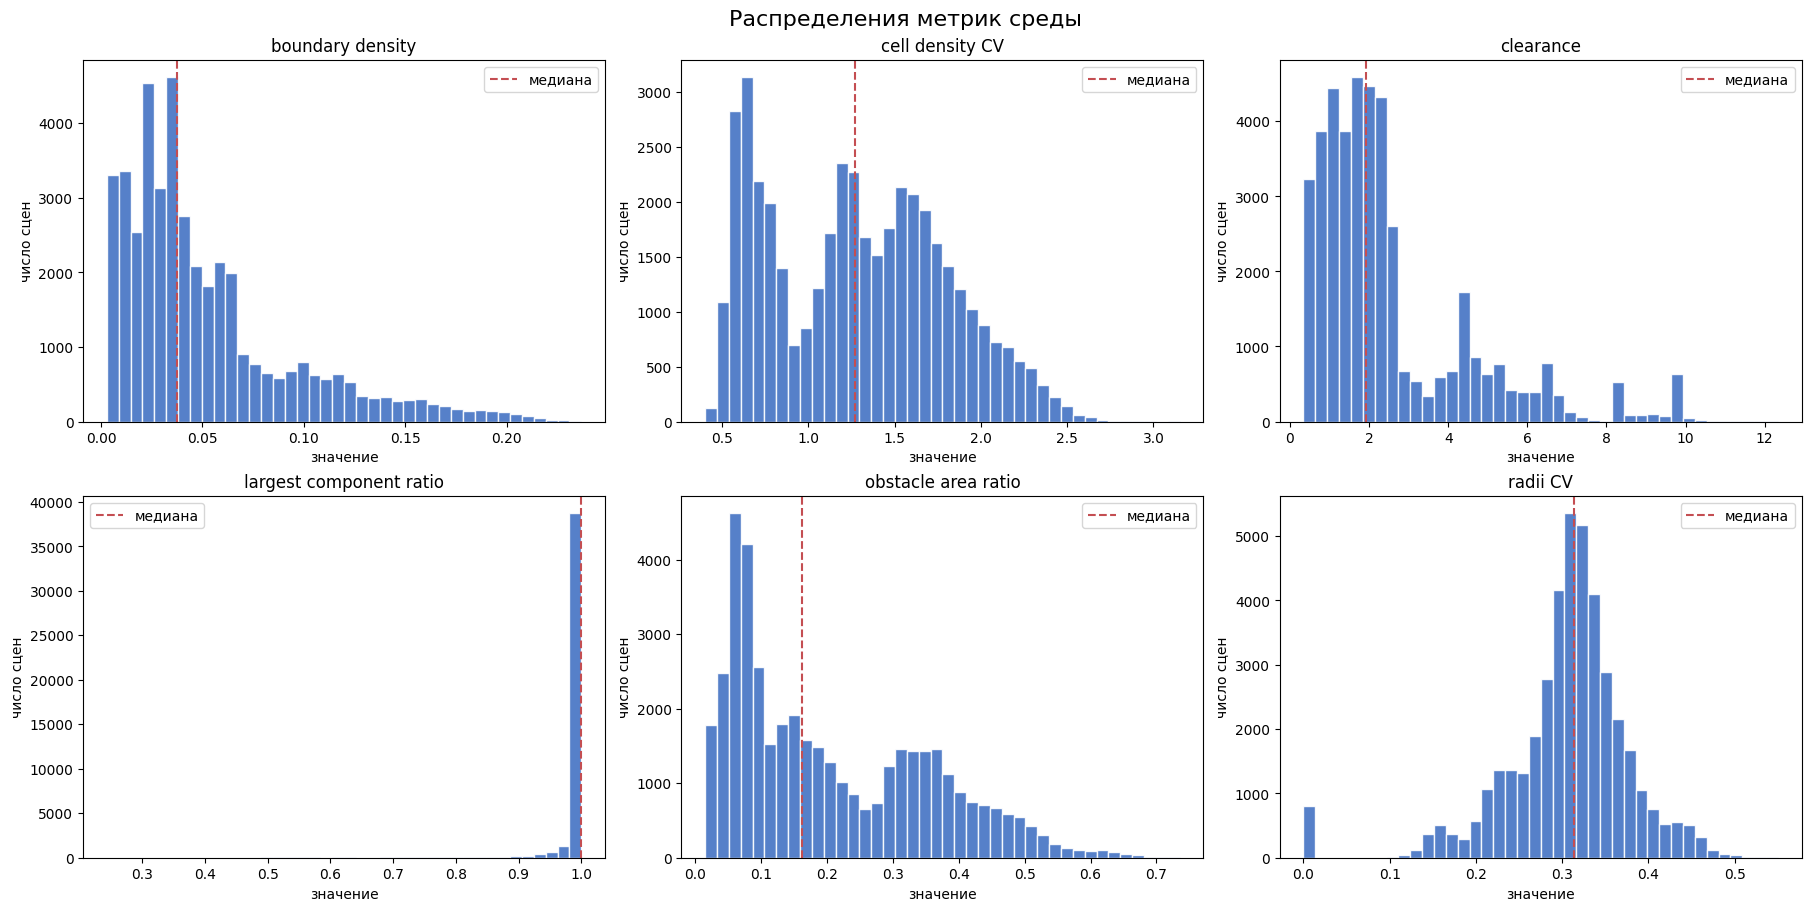

In [76]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
axes = axes.ravel()

for ax, metric in zip(axes, SCENE_METRIC_COLUMNS):
    values = scene_analysis_df[metric]
    ax.hist(values, bins=40, color='#4472c4', edgecolor='white', alpha=0.9)
    ax.axvline(values.median(), color='#c44e52', linestyle='--', linewidth=1.5, label='медиана')
    ax.set_title(SCENE_METRIC_LABELS[metric])
    ax.set_xlabel('значение')
    ax.set_ylabel('число сцен')
    ax.legend(loc='best')

fig.suptitle('Распределения метрик среды', fontsize=16)
metric_hist_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_histograms.png'
fig.savefig(metric_hist_path, dpi=180, bbox_inches='tight')
print('Saved:', metric_hist_path)
plt.show()

Распределения метрик среды в целом выглядят достаточно разнообразными и пригодными для анализа. Они не схлопнулись в константы, а значит сцены действительно различаются по структуре и сложности.

Для boundary_density, cell_density_cv, clearance и obstacle_area_ratio на графиках виден заметный разброс значений, что говорит о наличии в наборе как более простых, так и более сложных конфигураций среды. Это делает метрики содержательно полезными для сопоставления с результатами алгоритмов.

Для largest_component_ratio заметен выраженный пик вблизи 1.0. Это ожидаемо, поскольку значительная часть конфигов всё же ориентирована на проходимые и связные сцены. При этом метрика не вырождается полностью: сохраняется хвост меньших значений, соответствующий более сложным и частично фрагментированным случаям.

Отдельные пики и локальные сгущения на графиках в целом естественны и, вероятно, связаны с тем, что набор состоит из разных семейств конфигов с различной структурой сцен. Иными словами, это отражает не артефакт, а смешение нескольких типов сред в одной экспериментальной базе.

Для radii_cv вариативность выражена слабее, чем у остальных метрик, однако распределение всё равно не сводится к одному значению. В целом полученная картина не идеальна с точки зрения равномерности, но вполне достаточна для дальнейшего содержательного анализа.

## Практически значимые взаимосвязи метрик среды

Для основной части главы удобно показать не все возможные комбинации графиков, а компактный набор визуализаций, которые отвечают на три вопроса:
- действительно ли сцены различаются между собой;
- не сводятся ли метрики к одной и той же оси сложности;
- какие зависимости между показателями среды являются наиболее сильными и содержательно интерпретируемыми.

Ниже сначала рассматриваются несколько репрезентативных пар метрик, а затем анализируется общая корреляционная структура набора.

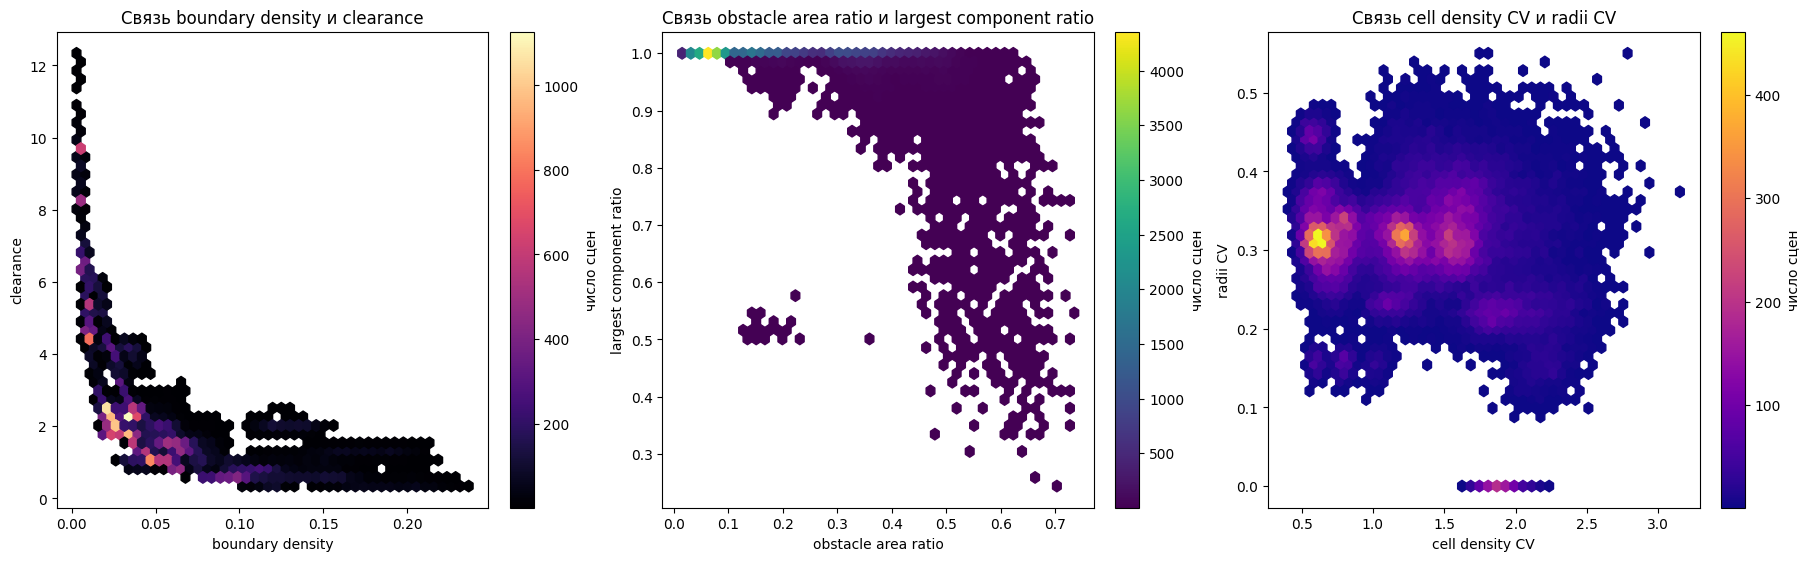

In [77]:
REPRESENTATIVE_PAIR_SPECS = [
    {
        'x': 'scene_metric_boundary_density',
        'y': 'scene_metric_clearance',
        'title': 'Связь boundary density и clearance',
        'cmap': 'magma',
    },
    {
        'x': 'scene_metric_obstacle_area_ratio',
        'y': 'scene_metric_largest_component_ratio',
        'title': 'Связь obstacle area ratio и largest component ratio',
        'cmap': 'viridis',
    },
    {
        'x': 'scene_metric_cell_density_cv',
        'y': 'scene_metric_radii_cv',
        'title': 'Связь cell density CV и radii CV',
        'cmap': 'plasma',
    },
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

for ax, spec in zip(axes, REPRESENTATIVE_PAIR_SPECS):
    hb = ax.hexbin(
        scene_analysis_df[spec['x']],
        scene_analysis_df[spec['y']],
        gridsize=45,
        cmap=spec['cmap'],
        mincnt=1,
    )
    ax.set_title(spec['title'])
    ax.set_xlabel(SCENE_METRIC_LABELS[spec['x']])
    ax.set_ylabel(SCENE_METRIC_LABELS[spec['y']])
    fig.colorbar(hb, ax=ax, label='число сцен')

In [78]:
fig.suptitle('Репрезентативные попарные связи метрик среды', fontsize=16)
metric_relation_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_relationships.png'
fig.savefig(metric_relation_path, dpi=180, bbox_inches='tight')
print('Saved:', metric_relation_path)
plt.show()

Saved: Q:\Diploma\python\analysis_outputs\final25_scene_metric_relationships.png


Репрезентативные `hexbin`-графики показывают, что наиболее сильные зависимости в наборе метрик являются содержательно интерпретируемыми. Рост `boundary density` сопровождается уменьшением `clearance`, а увеличение `obstacle area ratio` связано со снижением `largest component ratio`, то есть с ухудшением связности свободного пространства.

При этом пара `cell density CV` и `radii CV` демонстрирует существенно более размытое облако значений. Это важно для дипломной интерпретации: часть метрик действительно связана между собой, но набор не схлопывается в одну доминирующую ось сложности.

Для relative_path_length более высокие значения означают менее качественный путь. Поэтому положительные значения на правой heatmap отражают ухудшение качества при переходе к более сложным сценам.

Saved: Q:\Diploma\python\analysis_outputs\final25_config_metric_heatmap.png


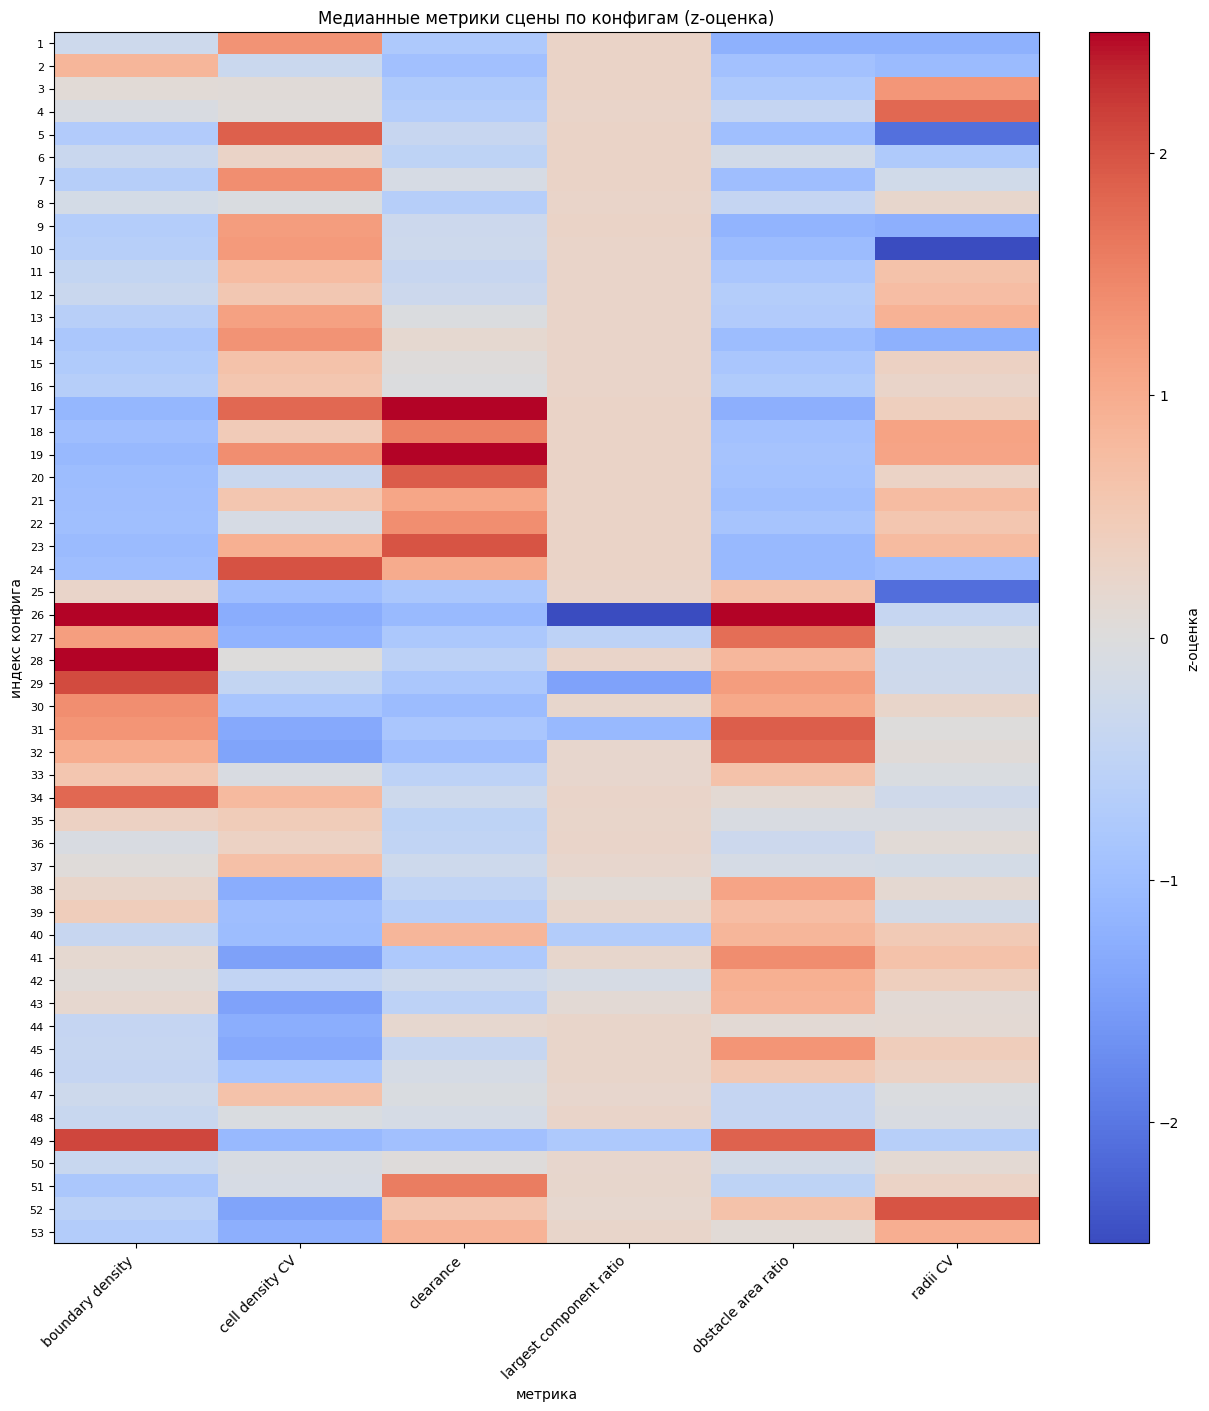

In [79]:
config_metric_median_df = scene_analysis_df.groupby('config_index')[SCENE_METRIC_COLUMNS].median()
config_metric_scaled_df = (
    config_metric_median_df - config_metric_median_df.mean(axis=0)
) / config_metric_median_df.std(axis=0, ddof=0).replace(0.0, 1.0)

fig, ax = plt.subplots(figsize=(12, 14), constrained_layout=True)
image = ax.imshow(config_metric_scaled_df.values, aspect='auto', cmap='coolwarm', vmin=-2.5, vmax=2.5)
ax.set_title('Медианные метрики сцены по конфигам (z-оценка)')
ax.set_xlabel('метрика')
ax.set_ylabel('индекс конфига')
ax.set_xticks(range(len(SCENE_METRIC_COLUMNS)))
ax.set_xticklabels(SCENE_METRIC_DISPLAY_NAMES, rotation=45, ha='right')
ax.set_yticks(range(len(config_metric_scaled_df.index)))
ax.set_yticklabels(config_metric_scaled_df.index.astype(str), fontsize=8)
fig.colorbar(image, ax=ax, label='z-оценка')
config_heatmap_path = OUTPUT_DIR / f'{DATASET_PREFIX}_config_metric_heatmap.png'
fig.savefig(config_heatmap_path, dpi=180, bbox_inches='tight')
print('Saved:', config_heatmap_path)
plt.show()

Конфиги реально различаются между собой, а не повторяют один и тот же сценарий с небольшим шумом. Это важно: поведение алгоритмов оценивается на гетерогенной экспериментальной базе.

## Корреляции метрик среды

Ниже вычисляются попарные корреляции между scene-метриками. Для основной интерпретации используется коэффициент `Spearman`, поскольку он устойчивее отражает монотонные, но не обязательно линейные зависимости.

Коэффициент `Pearson` также сохраняется в отдельный файл и может использоваться как дополнительная проверка линейных связей, однако для основной главы важнее ранжирование пар по `|Spearman|`.

In [80]:
pearson_corr_df = scene_analysis_df[SCENE_METRIC_COLUMNS].corr(method='pearson')
spearman_corr_df = scene_analysis_df[SCENE_METRIC_COLUMNS].corr(method='spearman')

def classify_correlation_strength(abs_value: float) -> str:
    if abs_value >= 0.7:
        return 'strong'
    if abs_value >= 0.5:
        return 'moderate'
    if abs_value >= 0.3:
        return 'weak-to-moderate'
    return 'weak'

correlation_pairs = []
for index, metric_a in enumerate(SCENE_METRIC_COLUMNS):
    for metric_b in SCENE_METRIC_COLUMNS[index + 1:]:
        pearson_value = pearson_corr_df.loc[metric_a, metric_b]
        spearman_value = spearman_corr_df.loc[metric_a, metric_b]
        abs_pearson = abs(pearson_value)
        abs_spearman = abs(spearman_value)
        correlation_pairs.append({
            'metric_a': metric_a,
            'metric_a_label': SCENE_METRIC_LABELS[metric_a],
            'metric_b': metric_b,
            'metric_b_label': SCENE_METRIC_LABELS[metric_b],
            'pair_label': f"{SCENE_METRIC_LABELS[metric_a]} - {SCENE_METRIC_LABELS[metric_b]}",
            'pearson': pearson_value,
            'spearman': spearman_value,
            'abs_pearson': abs_pearson,
            'abs_spearman': abs_spearman,
            'strength_category': classify_correlation_strength(abs_spearman),
        })

correlation_pairs_df = pd.DataFrame(correlation_pairs).sort_values(
    ['abs_spearman', 'abs_pearson'], ascending=False
).reset_index(drop=True)

correlation_strength_summary_df = (
    correlation_pairs_df.groupby('strength_category')
    .agg(
        pair_count=('strength_category', 'size'),
        share_of_pairs=('strength_category', lambda s: len(s) / len(correlation_pairs_df)),
        max_abs_spearman=('abs_spearman', 'max'),
        min_abs_spearman=('abs_spearman', 'min'),
    )
    .reindex(['strong', 'moderate', 'weak-to-moderate', 'weak'])
    .reset_index()
)

top_spearman_pairs_df = correlation_pairs_df[
    ['metric_a_label', 'metric_b_label', 'spearman', 'abs_spearman', 'strength_category']
].head(10).copy()

pearson_corr_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_pearson_corr.csv'
spearman_corr_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_spearman_corr.csv'
correlation_pairs_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_correlation_pairs.csv'
strength_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_correlation_strength_summary.csv'
top_pairs_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_top_spearman_pairs.csv'

pearson_corr_df.to_csv(pearson_corr_path)
spearman_corr_df.to_csv(spearman_corr_path)
correlation_pairs_df.to_csv(correlation_pairs_path, index=False)
correlation_strength_summary_df.to_csv(strength_summary_path, index=False)
top_spearman_pairs_df.to_csv(top_pairs_path, index=False)

print('Saved:', pearson_corr_path)
print('Saved:', spearman_corr_path)
print('Saved:', correlation_pairs_path)
print('Saved:', strength_summary_path)
print('Saved:', top_pairs_path)

with pd.option_context('display.max_columns', None, 'display.width', 2000):
    display(correlation_strength_summary_df)
    display(top_spearman_pairs_df)

Saved: Q:\Diploma\python\analysis_outputs\final25_scene_metric_pearson_corr.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_scene_metric_spearman_corr.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_scene_metric_correlation_pairs.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_scene_metric_correlation_strength_summary.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_scene_metric_top_spearman_pairs.csv


,strength_category,pair_count,share_of_pairs,max_abs_spearman,min_abs_spearman
0,strong,4,0.266667,0.871264,0.764198
1,moderate,4,0.266667,0.693079,0.546790
2,weak-to-moderate,3,0.200000,0.435132,0.330116
3,weak,4,0.266667,0.254472,0.005636


,metric_a_label,metric_b_label,spearman,abs_spearman,strength_category
0,boundary density,clearance,-0.871264,0.871264,strong
1,cell density CV,obstacle area ratio,-0.843637,0.843637,strong
2,largest component ratio,obstacle area ratio,-0.819817,0.819817,strong
3,boundary density,obstacle area ratio,0.764198,0.764198,strong
4,cell density CV,largest component ratio,0.693079,0.693079,moderate
5,boundary density,largest component ratio,-0.596861,0.596861,moderate
6,clearance,obstacle area ratio,-0.571394,0.571394,moderate
7,boundary density,cell density CV,-0.546790,0.546790,moderate
8,cell density CV,clearance,0.435132,0.435132,weak-to-moderate
9,clearance,largest component ratio,0.368380,0.368380,weak-to-moderate


Saved: Q:\Diploma\python\analysis_outputs\final25_scene_metric_correlation_summary.png


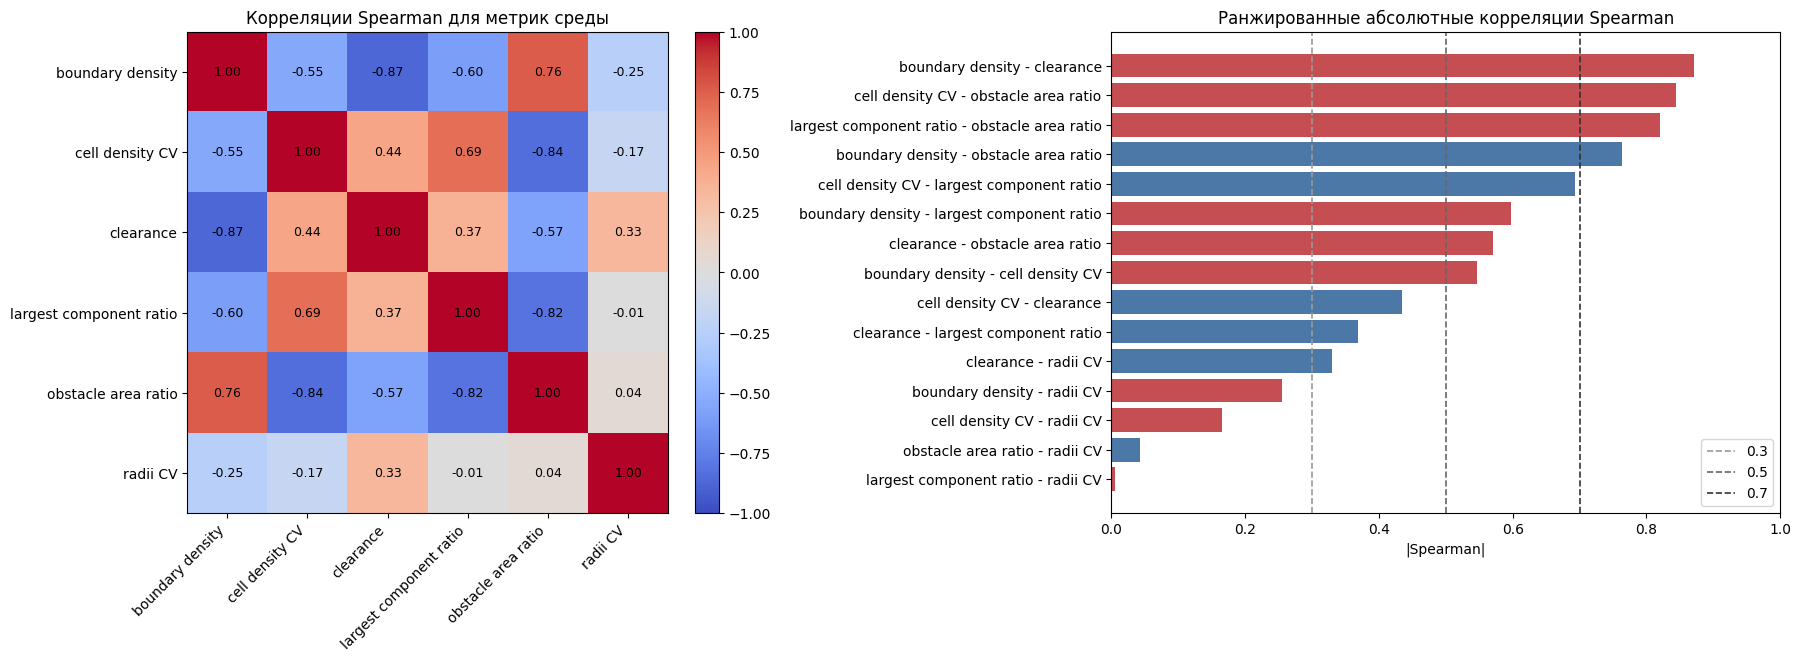

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), constrained_layout=True)

image = axes[0].imshow(spearman_corr_df.values, cmap='coolwarm', vmin=-1.0, vmax=1.0)
axes[0].set_title('Корреляции Spearman для метрик среды')
axes[0].set_xticks(range(len(SCENE_METRIC_COLUMNS)))
axes[0].set_yticks(range(len(SCENE_METRIC_COLUMNS)))
axes[0].set_xticklabels(SCENE_METRIC_DISPLAY_NAMES, rotation=45, ha='right')
axes[0].set_yticklabels(SCENE_METRIC_DISPLAY_NAMES)
for i in range(len(SCENE_METRIC_COLUMNS)):
    for j in range(len(SCENE_METRIC_COLUMNS)):
        axes[0].text(j, i, f'{spearman_corr_df.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9, color='black')
fig.colorbar(image, ax=axes[0], fraction=0.046, pad=0.04)

ranked_pairs_plot_df = correlation_pairs_df.sort_values(['abs_spearman', 'abs_pearson'], ascending=[True, True]).copy()
bar_colors = ['#c44e52' if value < 0 else '#4c78a8' for value in ranked_pairs_plot_df['spearman']]
axes[1].barh(ranked_pairs_plot_df['pair_label'], ranked_pairs_plot_df['abs_spearman'], color=bar_colors)
axes[1].axvline(0.3, color='#999999', linestyle='--', linewidth=1.2, label='0.3')
axes[1].axvline(0.5, color='#666666', linestyle='--', linewidth=1.2, label='0.5')
axes[1].axvline(0.7, color='#333333', linestyle='--', linewidth=1.2, label='0.7')
axes[1].set_title('Ранжированные абсолютные корреляции Spearman')
axes[1].set_xlabel('|Spearman|')
axes[1].set_xlim(0.0, 1.0)
axes[1].legend(loc='lower right')

corr_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_scene_metric_correlation_summary.png'
fig.savefig(corr_summary_path, dpi=180, bbox_inches='tight')
print('Saved:', corr_summary_path)
plt.show()

Корреляционный анализ показывает, что набор метрик среды не является ни полностью независимым, ни полностью вырожденным. Наиболее сильные связи сосредоточены в ограниченном числе пар и в целом соответствуют физическому смыслу показателей: рост плотности и покрытия препятствиями сопровождается уменьшением `clearance` и ухудшением связности свободного пространства.

Одновременно значительная часть пар остаётся в слабой или умеренной зоне по `|Spearman|`. Это означает, что показатели не дублируют друг друга полностью и действительно описывают разные аспекты сцены. Следовательно, использование нескольких метрик одновременно является содержательно оправданным: оно позволяет характеризовать сложность среды многомерно, а не сводить её к одному числу.

In [82]:
strong_pairs_df = correlation_pairs_df.loc[
    correlation_pairs_df['strength_category'] == 'strong',
    ['metric_a_label', 'metric_b_label', 'spearman', 'abs_spearman']
].copy()
moderate_pairs_df = correlation_pairs_df.loc[
    correlation_pairs_df['strength_category'] == 'moderate',
    ['metric_a_label', 'metric_b_label', 'spearman', 'abs_spearman']
].copy()
weak_pairs_df = correlation_pairs_df.loc[
    correlation_pairs_df['strength_category'] == 'weak',
    ['metric_a_label', 'metric_b_label', 'spearman', 'abs_spearman']
].copy().head(5)

print('Correlation strength summary:')
display(correlation_strength_summary_df)

print('Strong pairs (|Spearman| >= 0.7):', len(strong_pairs_df))
display(strong_pairs_df)

print('Moderate pairs (0.5 <= |Spearman| < 0.7):', len(moderate_pairs_df))
display(moderate_pairs_df)

print('Examples of weak pairs (|Spearman| < 0.3):')
display(weak_pairs_df)

Correlation strength summary:


,strength_category,pair_count,share_of_pairs,max_abs_spearman,min_abs_spearman
0,strong,4,0.266667,0.871264,0.764198
1,moderate,4,0.266667,0.693079,0.546790
2,weak-to-moderate,3,0.200000,0.435132,0.330116
3,weak,4,0.266667,0.254472,0.005636


Strong pairs (|Spearman| >= 0.7): 4


,metric_a_label,metric_b_label,spearman,abs_spearman
0,boundary density,clearance,-0.871264,0.871264
1,cell density CV,obstacle area ratio,-0.843637,0.843637
2,largest component ratio,obstacle area ratio,-0.819817,0.819817
3,boundary density,obstacle area ratio,0.764198,0.764198


Moderate pairs (0.5 <= |Spearman| < 0.7): 4


,metric_a_label,metric_b_label,spearman,abs_spearman
4,cell density CV,largest component ratio,0.693079,0.693079
5,boundary density,largest component ratio,-0.596861,0.596861
6,clearance,obstacle area ratio,-0.571394,0.571394
7,boundary density,cell density CV,-0.546790,0.546790


Examples of weak pairs (|Spearman| < 0.3):


,metric_a_label,metric_b_label,spearman,abs_spearman
11,boundary density,radii CV,-0.254472,0.254472
12,cell density CV,radii CV,-0.165206,0.165206
13,obstacle area ratio,radii CV,0.042255,0.042255
14,largest component ratio,radii CV,-0.005636,0.005636


Выделены наиболее связанные пары параметров. Эти зависимости важно учитывать при дальнейшей интерпретации результатов алгоритмов.

## Анализ работы алгоритмов

Для оценки качества работы алгоритмов используются только выполненные запуски (`algorithm_was_executed == True`), а для анализа качества пути — только успешные запуски (`path_found == True`). Строки `NotRun` сохраняются в общем датасете, но не должны влиять на содержательные выводы о работе планировщиков, так как относятся к несгенерированным сценам.

In [83]:
ALL_RUNS_DF = analysis_run_df.copy()
EXECUTED_RUNS_DF = ALL_RUNS_DF.loc[ALL_RUNS_DF['algorithm_was_executed']].copy()
SUCCESS_RUNS_DF = EXECUTED_RUNS_DF.loc[EXECUTED_RUNS_DF['path_found']].copy()

ALGORITHM_ORDER = sorted(ALL_RUNS_DF['algorithm_id'].dropna().unique())
ALGORITHM_COLORS = {
    'grid_astar': '#4c78a8',
    'grid_dijkstra': '#72b7b2',
    'rrt': '#f58518',
    'visibility_astar': '#e45756',
    'visibility_dijkstra': '#54a24b',
}
ALGORITHM_LABELS = {
    'grid_astar': 'Grid A*',
    'grid_dijkstra': 'Grid Dijkstra',
    'rrt': 'RRT',
    'visibility_astar': 'Visibility A*',
    'visibility_dijkstra': 'Visibility Dijkstra',
}
STATUS_ORDER = ['Success', 'NoPath', 'NotRun', 'Failed']
SHORT_METRIC_LABELS = {
    'scene_metric_obstacle_area_ratio': 'obstacle_area_ratio',
    'scene_metric_boundary_density': 'boundary_density',
    'scene_metric_clearance': 'clearance',
    'scene_metric_largest_component_ratio': 'largest_component_ratio',
    'scene_metric_cell_density_cv': 'cell_density_cv',
    'scene_metric_radii_cv': 'radii_cv',
    'scene_width': 'scene_width',
    'scene_height': 'scene_height',
    'scene_obstacle_count': 'scene_obstacle_count',
    'scene_direct_distance': 'scene_direct_distance',
}

In [84]:
status_counts_df = ALL_RUNS_DF.groupby(['algorithm_id', 'algorithm_status']).size().unstack(fill_value=0)
status_counts_df = status_counts_df.reindex(index=ALGORITHM_ORDER, columns=STATUS_ORDER, fill_value=0)

algorithm_overview_df = pd.DataFrame(index=ALGORITHM_ORDER)
algorithm_overview_df['total_slots'] = ALL_RUNS_DF.groupby('algorithm_id').size().reindex(ALGORITHM_ORDER)
algorithm_overview_df = algorithm_overview_df.join(status_counts_df)
algorithm_overview_df['executed_runs'] = algorithm_overview_df[['Success', 'NoPath', 'Failed']].sum(axis=1)
algorithm_overview_df['success_rate_executed'] = algorithm_overview_df['Success'] / algorithm_overview_df['executed_runs']
algorithm_overview_df['no_path_rate_executed'] = algorithm_overview_df['NoPath'] / algorithm_overview_df['executed_runs']
algorithm_overview_df['median_runtime_all_ms'] = EXECUTED_RUNS_DF.groupby('algorithm_id')['runtime_ms'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['median_runtime_success_ms'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['runtime_ms'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['p90_runtime_success_ms'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['runtime_ms'].quantile(0.9).reindex(ALGORITHM_ORDER)
algorithm_overview_df['mean_runtime_all_ms'] = EXECUTED_RUNS_DF.groupby('algorithm_id')['runtime_ms'].mean().reindex(ALGORITHM_ORDER)
algorithm_overview_df['median_path_length'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['path_length'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['median_relative_path_length'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['relative_path_length'].median().reindex(ALGORITHM_ORDER)
algorithm_overview_df['p90_relative_path_length'] = SUCCESS_RUNS_DF.groupby('algorithm_id')['relative_path_length'].quantile(0.9).reindex(ALGORITHM_ORDER)
algorithm_overview_df = algorithm_overview_df.sort_values(['success_rate_executed', 'median_runtime_success_ms'], ascending=[False, True])

In [85]:
config_success_df = EXECUTED_RUNS_DF.groupby(['config_index', 'algorithm_id']).agg(
    success_rate=('path_found', 'mean'),
    executed_runs=('algorithm_id', 'size'),
).reset_index()

config_runtime_df = SUCCESS_RUNS_DF.groupby(['config_index', 'algorithm_id']).agg(
    median_runtime_success_ms=('runtime_ms', 'median'),
    success_count=('algorithm_id', 'size'),
).reset_index()

config_quality_df = SUCCESS_RUNS_DF.groupby(['config_index', 'algorithm_id']).agg(
    median_relative_path_length=('relative_path_length', 'median'),
    median_path_length=('path_length', 'median'),
).reset_index()

config_runtime_winners_df = config_runtime_df.loc[config_runtime_df.groupby('config_index')['median_runtime_success_ms'].idxmin()].copy()
config_quality_winners_df = config_quality_df.loc[config_quality_df.groupby('config_index')['median_relative_path_length'].idxmin()].copy()

algorithm_overview_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_overview.csv'
config_success_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_success.csv'
config_runtime_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_runtime.csv'
config_quality_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_quality.csv'
algorithm_overview_df.reset_index(names='algorithm_id').to_csv(algorithm_overview_path, index=False)
config_success_df.to_csv(config_success_path, index=False)
config_runtime_df.to_csv(config_runtime_path, index=False)
config_quality_df.to_csv(config_quality_path, index=False)

with pd.option_context('display.max_columns', None, 'display.width', 2400):
    display(algorithm_overview_df.reset_index(names='algorithm_id'))

print('Saved:', algorithm_overview_path)
print('Saved:', config_success_path)
print('Saved:', config_runtime_path)
print('Saved:', config_quality_path)

,algorithm_id,total_slots,Success,NoPath,NotRun,Failed,executed_runs,success_rate_executed,no_path_rate_executed,median_runtime_all_ms,median_runtime_success_ms,p90_runtime_success_ms,mean_runtime_all_ms,median_path_length,median_relative_path_length,p90_relative_path_length
0,visibility_astar,42400,41216,1121,63,0,42337,0.973522,0.026478,109.7786,113.0564,5377.92195,1320.439524,327.316685,1.007930,1.133661
1,visibility_dijkstra,42400,41216,1121,63,0,42337,0.973522,0.026478,112.7131,116.5881,5386.64730,1327.814528,327.316685,1.007930,1.133661
2,grid_astar,42400,40309,2028,63,0,42337,0.952099,0.047901,158.6124,172.3630,5893.30600,2064.703058,356.113246,1.068425,1.232814
3,grid_dijkstra,42400,40309,2028,63,0,42337,0.952099,0.047901,161.4657,174.9076,5930.80356,2074.793473,356.113246,1.068425,1.232814
4,rrt,42400,39234,3103,63,0,42337,0.926707,0.073293,19.7762,15.8554,173.73389,105.085691,332.697240,1.062514,1.298626


Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_overview.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_config_success.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_config_runtime.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_config_quality.csv


In [86]:
best_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmax()
fastest_success_algorithm = algorithm_overview_df['median_runtime_success_ms'].idxmin()
best_quality_algorithm = algorithm_overview_df['median_relative_path_length'].idxmin()
weakest_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmin()

print(f"Лучшая успешность: {best_success_algorithm} ({algorithm_overview_df.loc[best_success_algorithm, 'success_rate_executed']:.2%})")
print(f"Наименьшая успешность: {weakest_success_algorithm} ({algorithm_overview_df.loc[weakest_success_algorithm, 'success_rate_executed']:.2%})")
print(f"Лучшее медианное время успешного запуска: {fastest_success_algorithm} ({algorithm_overview_df.loc[fastest_success_algorithm, 'median_runtime_success_ms']:.2f} мс)")
print(f"Лучшее медианное качество пути: {best_quality_algorithm} ({algorithm_overview_df.loc[best_quality_algorithm, 'median_relative_path_length']:.4f})")

print('Победители по конфигам по медианному времени успешного запуска:')
print(config_runtime_winners_df['algorithm_id'].value_counts().to_string())

print('Победители по конфигам по медианному качеству пути:')
print(config_quality_winners_df['algorithm_id'].value_counts().to_string())

Лучшая успешность: visibility_astar (97.35%)
Наименьшая успешность: rrt (92.67%)
Лучшее медианное время успешного запуска: rrt (15.86 мс)
Лучшее медианное качество пути: visibility_astar (1.0079)
Победители по конфигам по медианному времени успешного запуска:
rrt                    50
visibility_astar        1
grid_dijkstra           1
visibility_dijkstra     1
Победители по конфигам по медианному качеству пути:
visibility_astar    53


Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_overview.png


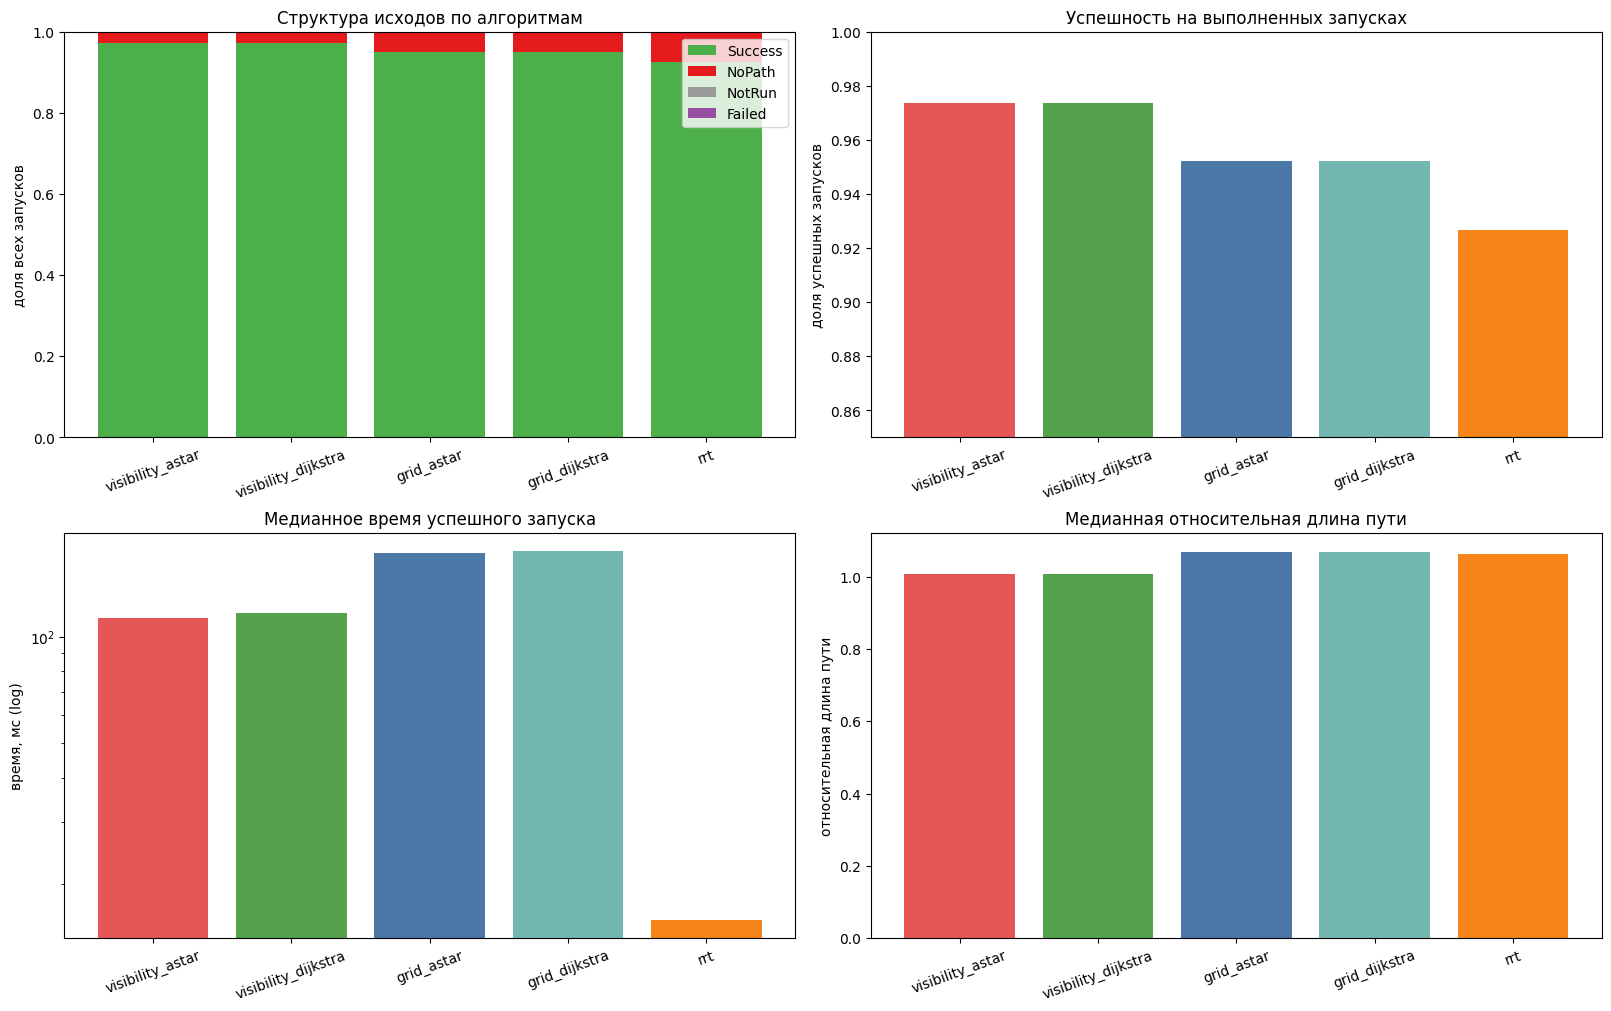

In [87]:
plot_order = algorithm_overview_df.index.tolist()
status_share_df = status_counts_df.loc[plot_order].div(status_counts_df.loc[plot_order].sum(axis=1), axis=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

bottom = np.zeros(len(plot_order))
for status, color in [('Success', '#4daf4a'), ('NoPath', '#e41a1c'), ('NotRun', '#999999'), ('Failed', '#984ea3')]:
    values = status_share_df[status].values
    axes[0, 0].bar(plot_order, values, bottom=bottom, color=color, label=status)
    bottom += values
axes[0, 0].set_title('Структура исходов по алгоритмам')
axes[0, 0].set_ylabel('доля всех запусков')
axes[0, 0].legend(loc='upper right')
axes[0, 0].tick_params(axis='x', rotation=20)

success_values = algorithm_overview_df.loc[plot_order, 'success_rate_executed']
axes[0, 1].bar(plot_order, success_values, color=[ALGORITHM_COLORS[a] for a in plot_order])
axes[0, 1].set_title('Успешность на выполненных запусках')
axes[0, 1].set_ylabel('доля успешных запусков')
axes[0, 1].set_ylim(0.85, 1.0)
axes[0, 1].tick_params(axis='x', rotation=20)

runtime_values = algorithm_overview_df.loc[plot_order, 'median_runtime_success_ms']
axes[1, 0].bar(plot_order, runtime_values, color=[ALGORITHM_COLORS[a] for a in plot_order])
axes[1, 0].set_yscale('log')
axes[1, 0].set_title('Медианное время успешного запуска')
axes[1, 0].set_ylabel('время, мс (log)')
axes[1, 0].tick_params(axis='x', rotation=20)

quality_values = algorithm_overview_df.loc[plot_order, 'median_relative_path_length']
axes[1, 1].bar(plot_order, quality_values, color=[ALGORITHM_COLORS[a] for a in plot_order])
axes[1, 1].set_title('Медианная относительная длина пути')
axes[1, 1].set_ylabel('относительная длина пути')
axes[1, 1].tick_params(axis='x', rotation=20)

overview_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_overview.png'
fig.savefig(overview_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', overview_figure_path)
plt.show()

На этом уровне уже видна основная картина: visibility-методы лидируют по успешности и качеству, RRT выигрывает по времени, а grid-подходы занимают компромиссную позицию с более высокой вычислительной ценой.

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_distributions_tradeoff.png


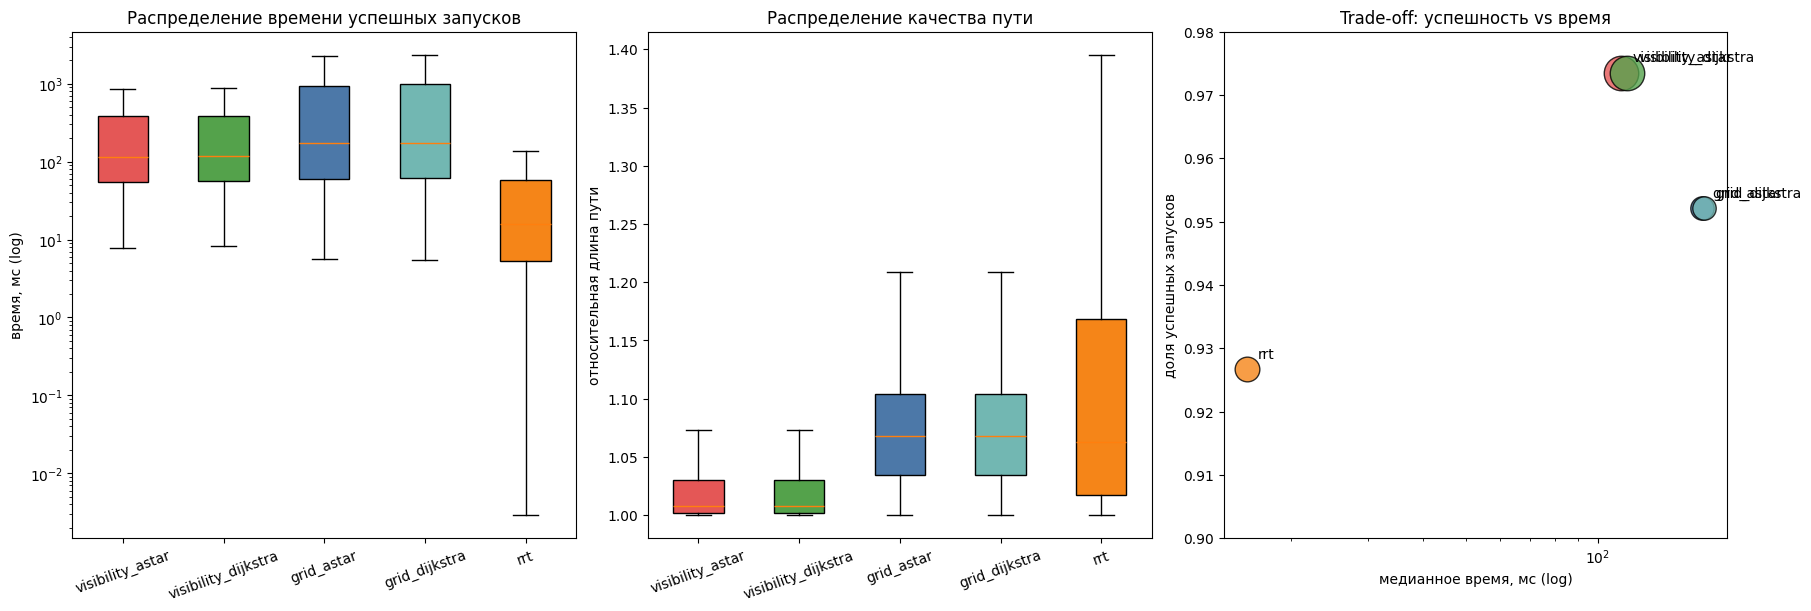

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

runtime_series = [SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'runtime_ms'].values for algorithm_id in plot_order]
runtime_box = axes[0].boxplot(runtime_series, tick_labels=plot_order, showfliers=False, patch_artist=True)
for patch, algorithm_id in zip(runtime_box['boxes'], plot_order):
    patch.set_facecolor(ALGORITHM_COLORS[algorithm_id])
axes[0].set_yscale('log')
axes[0].set_title('Распределение времени успешных запусков')
axes[0].set_ylabel('время, мс (log)')
axes[0].tick_params(axis='x', rotation=20)

quality_series = [SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'relative_path_length'].values for algorithm_id in plot_order]
quality_box = axes[1].boxplot(quality_series, tick_labels=plot_order, showfliers=False, patch_artist=True)
for patch, algorithm_id in zip(quality_box['boxes'], plot_order):
    patch.set_facecolor(ALGORITHM_COLORS[algorithm_id])
axes[1].set_title('Распределение качества пути')
axes[1].set_ylabel('относительная длина пути')
axes[1].tick_params(axis='x', rotation=20)

tradeoff_df = algorithm_overview_df.loc[plot_order].reset_index(names='algorithm_id')
for _, row in tradeoff_df.iterrows():
    marker_size = max(120.0, 5500.0 * (1.12 - min(row['median_relative_path_length'], 1.11)))
    axes[2].scatter(
        row['median_runtime_success_ms'],
        row['success_rate_executed'],
        s=marker_size,
        color=ALGORITHM_COLORS[row['algorithm_id']],
        alpha=0.8,
        edgecolors='black',
    )
    axes[2].annotate(row['algorithm_id'], (row['median_runtime_success_ms'], row['success_rate_executed']), xytext=(8, 8), textcoords='offset points')
axes[2].set_xscale('log')
axes[2].set_title('Trade-off: успешность vs время')
axes[2].set_xlabel('медианное время, мс (log)')
axes[2].set_ylabel('доля успешных запусков')
axes[2].set_ylim(0.9, 0.98)

distribution_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_distributions_tradeoff.png'
fig.savefig(distribution_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', distribution_figure_path)
plt.show()

Медианы не описывают всю картину. Распределения показывают, насколько устойчиво алгоритмы удерживают преимущество по всему массиву сцен, а не только в среднем.

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_config_heatmaps.png


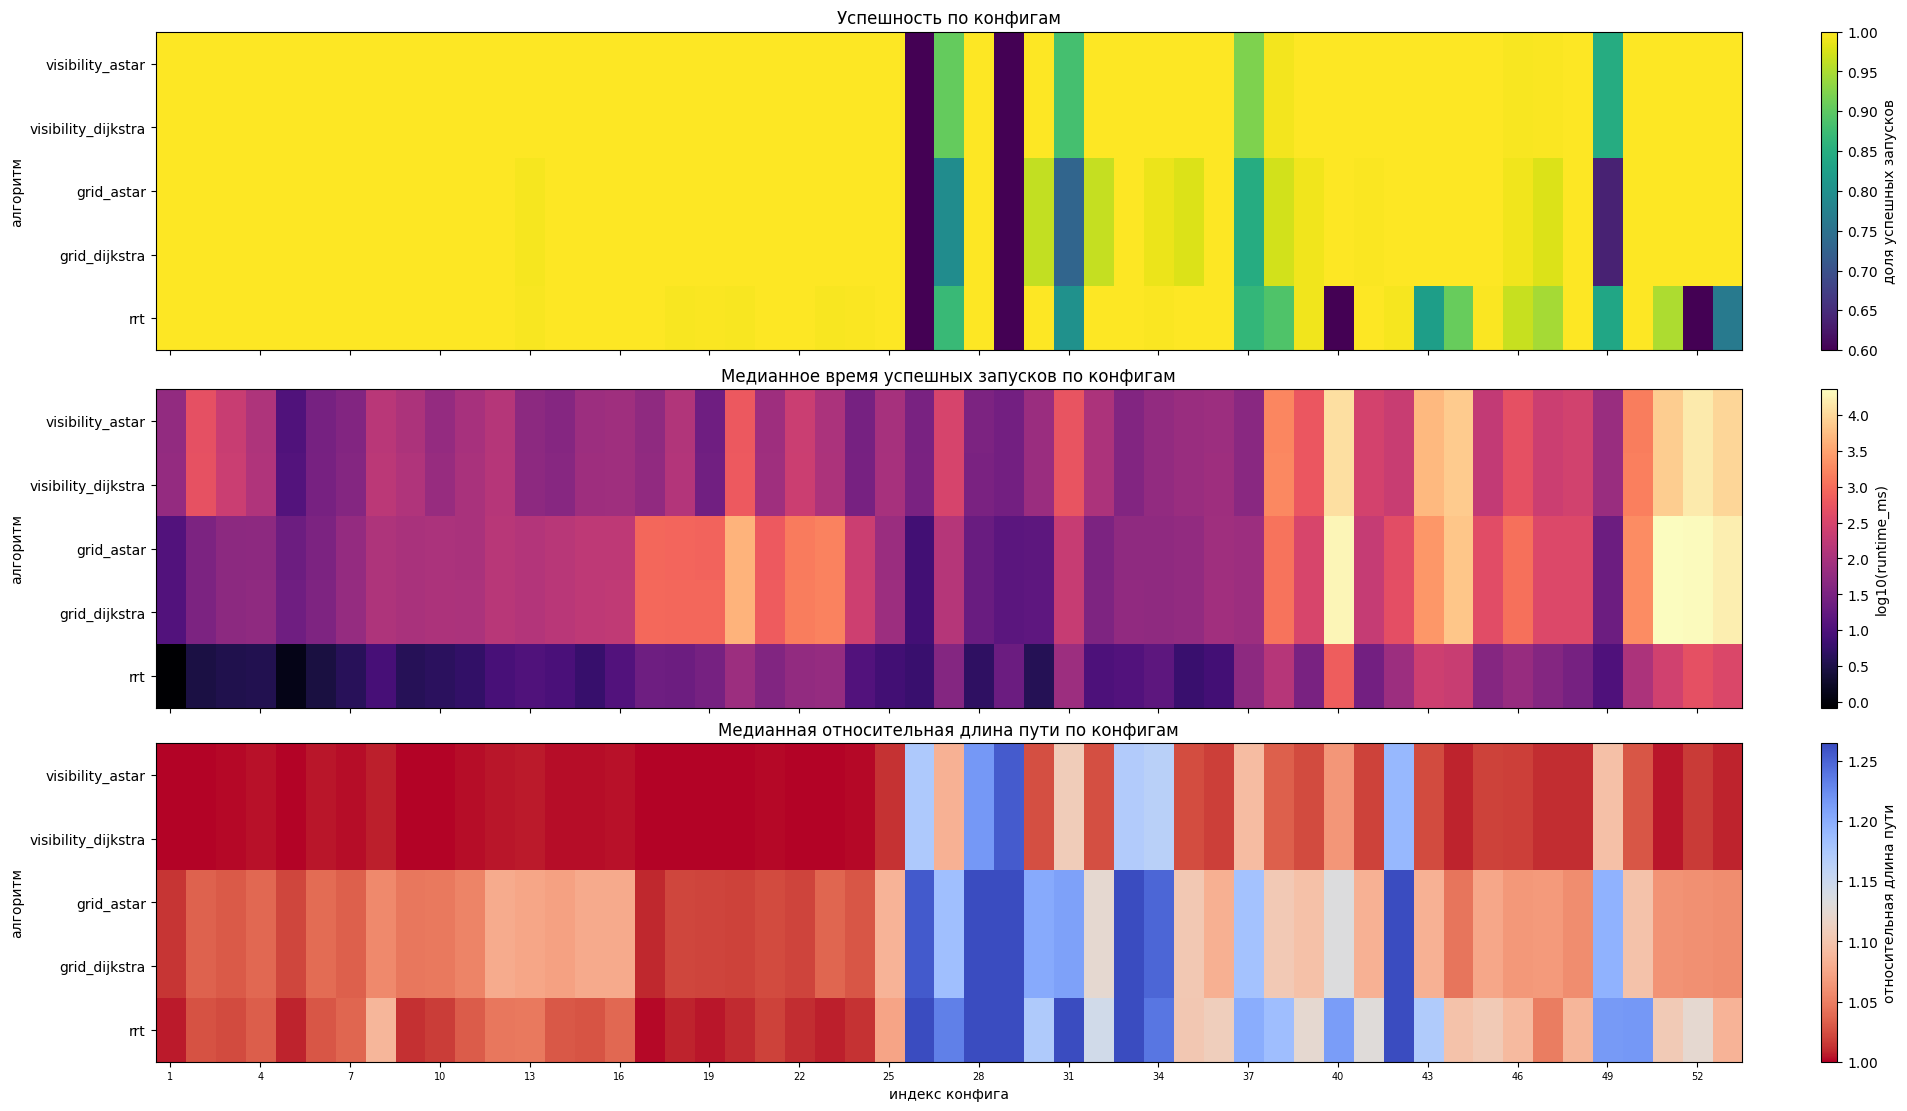

In [89]:
success_heatmap_df = config_success_df.pivot(index='algorithm_id', columns='config_index', values='success_rate').reindex(plot_order)
runtime_heatmap_df = config_runtime_df.pivot(index='algorithm_id', columns='config_index', values='median_runtime_success_ms').reindex(plot_order)
quality_heatmap_df = config_quality_df.pivot(index='algorithm_id', columns='config_index', values='median_relative_path_length').reindex(plot_order)

fig, axes = plt.subplots(3, 1, figsize=(19, 11), constrained_layout=True, sharex=True)
xtick_positions = list(range(0, len(success_heatmap_df.columns), 3))
xtick_labels = success_heatmap_df.columns.astype(int).tolist()[::3]

image = axes[0].imshow(success_heatmap_df.values, aspect='auto', cmap='viridis', vmin=0.6, vmax=1.0)
axes[0].set_title('Успешность по конфигам')
axes[0].set_ylabel('алгоритм')
axes[0].set_yticks(range(len(plot_order)))
axes[0].set_yticklabels(plot_order)
fig.colorbar(image, ax=axes[0], label='доля успешных запусков')

runtime_log_values = np.log10(runtime_heatmap_df.values)
image = axes[1].imshow(runtime_log_values, aspect='auto', cmap='magma')
axes[1].set_title('Медианное время успешных запусков по конфигам')
axes[1].set_ylabel('алгоритм')
axes[1].set_yticks(range(len(plot_order)))
axes[1].set_yticklabels(plot_order)
fig.colorbar(image, ax=axes[1], label='log10(runtime_ms)')

quality_limit = np.nanpercentile(quality_heatmap_df.values, 95)
image = axes[2].imshow(quality_heatmap_df.values, aspect='auto', cmap='coolwarm_r', vmin=1.0, vmax=quality_limit)
axes[2].set_title('Медианная относительная длина пути по конфигам')
axes[2].set_ylabel('алгоритм')
axes[2].set_xlabel('индекс конфига')
axes[2].set_yticks(range(len(plot_order)))
axes[2].set_yticklabels(plot_order)
axes[2].set_xticks(xtick_positions)
axes[2].set_xticklabels(xtick_labels, rotation=0, fontsize=7)
fig.colorbar(image, ax=axes[2], label='относительная длина пути')

config_heatmap_algo_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_heatmaps.png'
fig.savefig(config_heatmap_algo_path, dpi=180, bbox_inches='tight')
print('Saved:', config_heatmap_algo_path)
plt.show()

Различия между алгоритмами зависят от семейства конфигураций. На более тяжелых сценах расслоение между методами становится заметно сильнее.

In [90]:
def build_tie_aware_share_matrix(pivot_df):
    algorithms = list(pivot_df.columns)
    share_matrix = pd.DataFrame(index=algorithms, columns=algorithms, dtype=float)
    support_matrix = pd.DataFrame(index=algorithms, columns=algorithms, dtype=float)
    for algorithm_a in algorithms:
        for algorithm_b in algorithms:
            common = pivot_df[[algorithm_a, algorithm_b]].dropna()
            support_matrix.loc[algorithm_a, algorithm_b] = len(common)
            if len(common) == 0:
                share_matrix.loc[algorithm_a, algorithm_b] = np.nan
            elif algorithm_a == algorithm_b:
                share_matrix.loc[algorithm_a, algorithm_b] = 0.5
            else:
                better_share = (common[algorithm_a] < common[algorithm_b]).mean()
                tie_share = (common[algorithm_a] == common[algorithm_b]).mean()
                share_matrix.loc[algorithm_a, algorithm_b] = better_share + 0.5 * tie_share
    return share_matrix.astype(float), support_matrix.astype(int)

In [91]:
runtime_pivot_df = SUCCESS_RUNS_DF.pivot_table(index=['config_index', 'scene_id'], columns='algorithm_id', values='runtime_ms')
quality_pivot_df = SUCCESS_RUNS_DF.pivot_table(index=['config_index', 'scene_id'], columns='algorithm_id', values='relative_path_length')
runtime_pairwise_df, runtime_support_df = build_tie_aware_share_matrix(runtime_pivot_df)
quality_pairwise_df, quality_support_df = build_tie_aware_share_matrix(quality_pivot_df)

runtime_pairwise_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_pairwise.csv'
quality_pairwise_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_pairwise.csv'
runtime_pairwise_df.to_csv(runtime_pairwise_path)
quality_pairwise_df.to_csv(quality_pairwise_path)

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_runtime_pairwise.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_quality_pairwise.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_pairwise_dominance.png


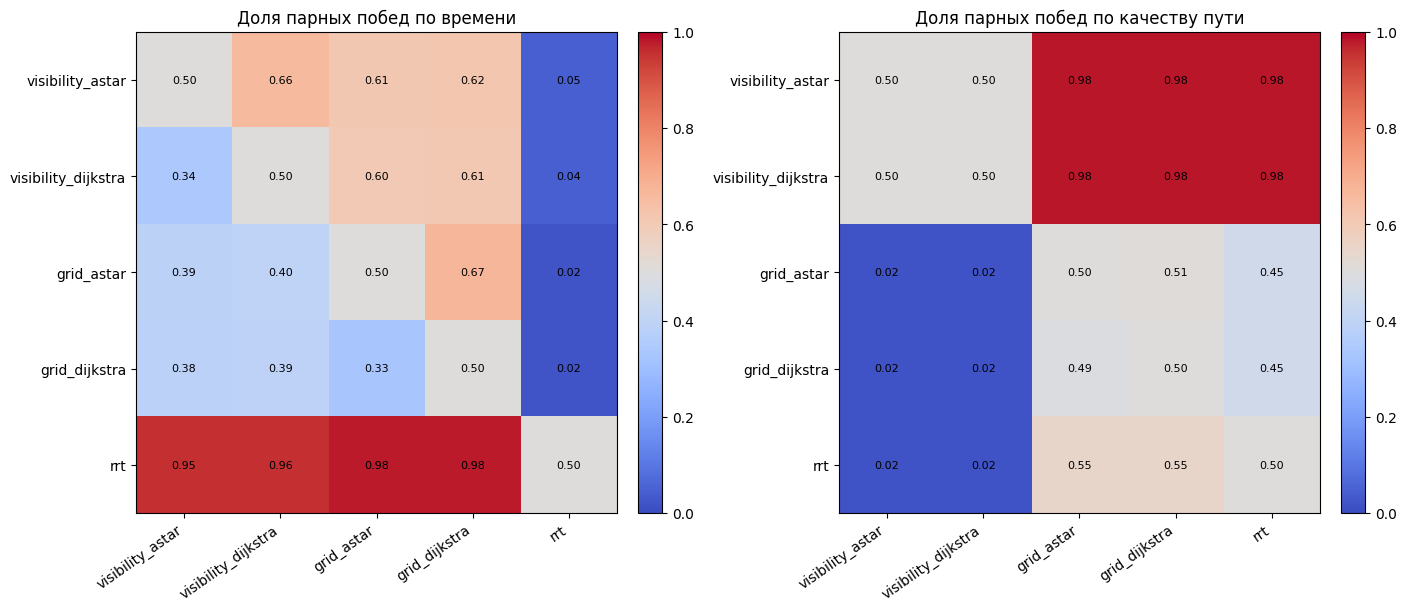

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, matrix_df, title in [
    (axes[0], runtime_pairwise_df.reindex(index=plot_order, columns=plot_order), 'Доля парных побед по времени'),
    (axes[1], quality_pairwise_df.reindex(index=plot_order, columns=plot_order), 'Доля парных побед по качеству пути'),
]:
    image = ax.imshow(matrix_df.values, cmap='coolwarm', vmin=0.0, vmax=1.0)
    ax.set_title(title)
    ax.set_xticks(range(len(plot_order)))
    ax.set_yticks(range(len(plot_order)))
    ax.set_xticklabels(plot_order, rotation=35, ha='right')
    ax.set_yticklabels(plot_order)
    for i in range(len(plot_order)):
        for j in range(len(plot_order)):
            ax.text(j, i, f'{matrix_df.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

pairwise_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_pairwise_dominance.png'
fig.savefig(pairwise_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', runtime_pairwise_path)
print('Saved:', quality_pairwise_path)
print('Saved:', pairwise_figure_path)
plt.show()

## Связь параметров среды с успешностью алгоритмов

Для интерпретации успешности важно разделить два уровня анализа. Сначала оценивается общая доля успешных запусков по алгоритмам, а затем — то, как эта доля меняется при усложнении среды по отдельным scene-метрикам и их сочетаниям.

Ниже используются только выполненные запуски (`algorithm_was_executed == True`), поэтому строки `NotRun` не искажают выводы об устойчивости планировщиков.

### Подготовка метрик успешности

Задаются метрики среды и ранговое представление, которое делает сравнение простых и сложных сцен устойчивее к масштабу признаков.

In [93]:
ALGO_CORRELATION_METRICS = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_width',
    'scene_height',
    'scene_obstacle_count',
    'scene_direct_distance',
]

SUCCESS_METRICS = SCENE_METRIC_COLUMNS.copy()

def add_quantile_ranks(df, value_column, rank_column, q):
    temp_df = df.copy()
    if temp_df[value_column].nunique(dropna=True) < 2:
        temp_df[rank_column] = pd.Series(pd.NA, index=temp_df.index, dtype='Int64')
        return temp_df, 0
    try:
        quantile_bins = pd.qcut(temp_df[value_column], q=q, duplicates='drop')
    except ValueError:
        temp_df[rank_column] = pd.Series(pd.NA, index=temp_df.index, dtype='Int64')
        return temp_df, 0
    temp_df[rank_column] = pd.Series(quantile_bins.cat.codes + 1, index=temp_df.index, dtype='Int64')
    temp_df.loc[quantile_bins.isna(), rank_column] = pd.NA
    return temp_df, int(temp_df[rank_column].dropna().nunique())

### Корреляции успешности с параметрами среды

Для каждого алгоритма оценивается связь успешности с метриками сцены и готовится матрица для heatmap.

In [94]:
correlation_rows = []
for algorithm_id, algorithm_df in EXECUTED_RUNS_DF.groupby('algorithm_id'):
    for metric in ALGO_CORRELATION_METRICS:
        metric_df = algorithm_df[[metric, 'path_found', 'runtime_ms', 'relative_path_length']].dropna(subset=[metric]).copy()
        success_subset = metric_df[[metric, 'path_found']].dropna()
        runtime_subset = metric_df.loc[metric_df['runtime_ms'] >= 0, [metric, 'runtime_ms']].dropna()
        quality_subset = metric_df.loc[metric_df['path_found'], [metric, 'relative_path_length']].dropna()

        success_corr = success_subset.corr(method='spearman').iloc[0, 1] if len(success_subset) >= 2 else np.nan
        runtime_corr = runtime_subset.corr(method='spearman').iloc[0, 1] if len(runtime_subset) >= 2 else np.nan
        quality_corr = quality_subset.corr(method='spearman').iloc[0, 1] if len(quality_subset) >= 2 else np.nan

        correlation_rows.append({
            'algorithm_id': algorithm_id,
            'metric': metric,
            'success_spearman': success_corr,
            'runtime_spearman': runtime_corr,
            'quality_spearman': quality_corr,
            'success_sample_size': len(success_subset),
            'runtime_sample_size': len(runtime_subset),
            'quality_sample_size': len(quality_subset),
        })

algorithm_metric_correlations_df = pd.DataFrame(correlation_rows)
algorithm_metric_correlations_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_metric_correlations.csv'
algorithm_metric_correlations_df.to_csv(algorithm_metric_correlations_path, index=False)

success_correlation_pairs_df = (
    algorithm_metric_correlations_df.loc[
        algorithm_metric_correlations_df['metric'].isin(SUCCESS_METRICS),
        ['algorithm_id', 'metric', 'success_spearman', 'success_sample_size']
    ]
    .copy()
)
success_corr_heatmap_df = (
    success_correlation_pairs_df
    .pivot(index='algorithm_id', columns='metric', values='success_spearman')
    .reindex(index=plot_order, columns=SUCCESS_METRICS)
)

### Чувствительность успешности к сложности сцены

Сравниваются нижние и верхние квантили метрик среды, чтобы увидеть, где успешность алгоритмов падает сильнее всего.

In [95]:
sensitivity_rows = []
for algorithm_id, algorithm_df in EXECUTED_RUNS_DF.groupby('algorithm_id'):
    for metric in SUCCESS_METRICS:
        metric_df = algorithm_df[[metric, 'path_found']].dropna().copy()
        metric_df, quantile_count = add_quantile_ranks(metric_df, metric, 'metric_quantile_rank', q=4)
        metric_df = metric_df.dropna(subset=['metric_quantile_rank']).copy()
        if metric_df.empty or quantile_count < 2:
            continue
        profile_df = (
            metric_df.groupby('metric_quantile_rank')
            .agg(
                metric_value=(metric, 'median'),
                success_rate=('path_found', 'mean'),
                sample_count=('path_found', 'size'),
            )
            .reset_index()
            .sort_values('metric_value')
            .reset_index(drop=True)
        )
        low_row = profile_df.iloc[0]
        high_row = profile_df.iloc[-1]

        sensitivity_rows.append({
            'algorithm_id': algorithm_id,
            'metric': metric,
            'low_metric_value': low_row['metric_value'],
            'high_metric_value': high_row['metric_value'],
            'low_quantile_success_rate': low_row['success_rate'],
            'high_quantile_success_rate': high_row['success_rate'],
            'low_quantile_sample_count': low_row['sample_count'],
            'high_quantile_sample_count': high_row['sample_count'],
            'delta_success_high_minus_low': high_row['success_rate'] - low_row['success_rate'],
            'abs_delta_success': abs(high_row['success_rate'] - low_row['success_rate']),
            'quantile_count': quantile_count,
        })

success_sensitivity_df = pd.DataFrame(sensitivity_rows)
success_sensitivity_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_sensitivity.csv'
success_sensitivity_df.to_csv(success_sensitivity_path, index=False)

success_sensitivity_heatmap_df = (
    success_sensitivity_df
    .pivot(index='algorithm_id', columns='metric', values='delta_success_high_minus_low')
    .reindex(index=plot_order, columns=SUCCESS_METRICS)
)

success_metric_summary_df = (
    success_correlation_pairs_df
    .merge(success_sensitivity_df, on=['algorithm_id', 'metric'], how='left')
    .assign(
        algorithm_label=lambda df: df['algorithm_id'].map(ALGORITHM_LABELS).fillna(df['algorithm_id']),
        metric_label=lambda df: df['metric'].map(SCENE_METRIC_LABELS).fillna(df['metric']),
    )
)
success_metric_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_metric_summary.csv'
success_metric_summary_df.to_csv(success_metric_summary_path, index=False)

success_top_links_df = (
    success_metric_summary_df
    .assign(abs_success_spearman=lambda df: df['success_spearman'].abs())
    .sort_values('abs_success_spearman', ascending=False)
    .reset_index(drop=True)
)
success_top_deltas_df = (
    success_metric_summary_df
    .sort_values('abs_delta_success', ascending=False)
    .reset_index(drop=True)
)

overall_success_plot_df = (
    algorithm_overview_df.loc[plot_order, ['success_rate_executed', 'executed_runs']]
    .reset_index(names='algorithm_id')
    .assign(algorithm_label=lambda df: df['algorithm_id'].map(ALGORITHM_LABELS).fillna(df['algorithm_id']))
)
overall_success_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_overview.csv'
overall_success_plot_df.to_csv(overall_success_path, index=False)
min_success = max(0.0, float(overall_success_plot_df['success_rate_executed'].min()) - 0.02)
delta_abs_max = np.nanmax(np.abs(success_sensitivity_heatmap_df.values))
delta_abs_max = max(0.02, float(delta_abs_max if np.isfinite(delta_abs_max) else 0.02))

### Сводная визуализация успешности

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_metric_correlations.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_success_sensitivity.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_success_metric_summary.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_success_overview.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_success_metric_summary.png


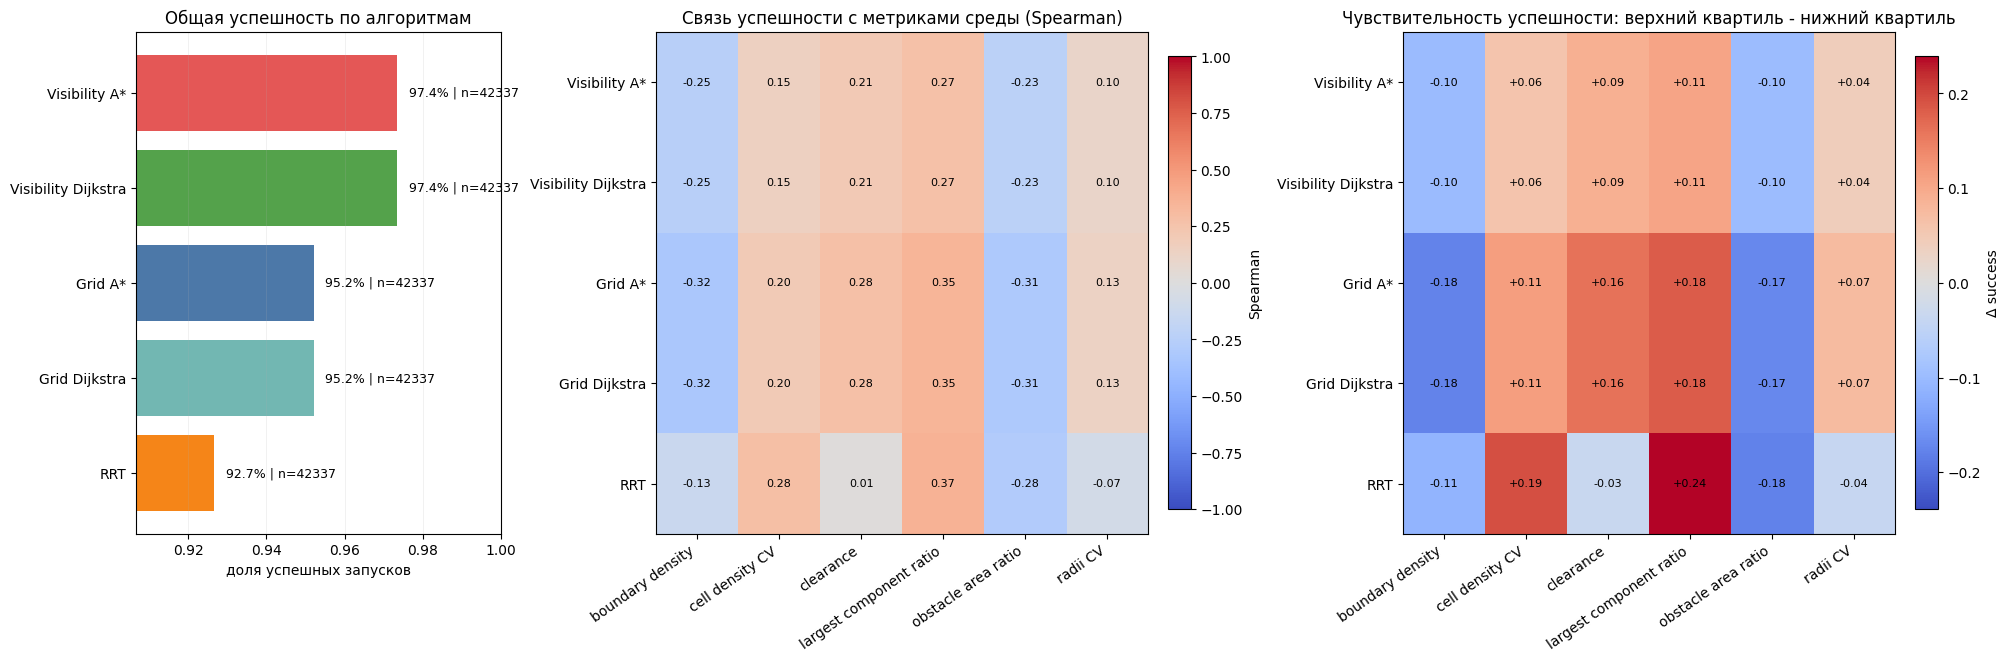

In [96]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 6.5),
    constrained_layout=True,
    gridspec_kw={'width_ratios': [1.0, 1.35, 1.35]},
)

y_positions = np.arange(len(overall_success_plot_df))
axes[0].barh(
    y_positions,
    overall_success_plot_df['success_rate_executed'],
    color=[ALGORITHM_COLORS[algorithm_id] for algorithm_id in overall_success_plot_df['algorithm_id']],
)
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(overall_success_plot_df['algorithm_label'])
axes[0].invert_yaxis()
axes[0].set_xlim(min_success, 1.0)
axes[0].set_xlabel('доля успешных запусков')
axes[0].set_title('Общая успешность по алгоритмам')
axes[0].grid(axis='x', alpha=0.25, linewidth=0.5)
for y_pos, row in enumerate(overall_success_plot_df.itertuples(index=False)):
    axes[0].text(
        min(row.success_rate_executed + 0.003, 0.996),
        y_pos,
        f'{row.success_rate_executed:.1%} | n={int(row.executed_runs)}',
        va='center',
        fontsize=9,
    )

plot_corr_df = success_corr_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
corr_image = axes[1].imshow(plot_corr_df.values, aspect='auto', cmap='coolwarm', vmin=-1.0, vmax=1.0)
axes[1].set_title('Связь успешности с метриками среды (Spearman)')
axes[1].set_yticks(range(len(plot_corr_df.index)))
axes[1].set_yticklabels(plot_corr_df.index)
axes[1].set_xticks(range(len(plot_corr_df.columns)))
axes[1].set_xticklabels(plot_corr_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_corr_df.index)):
    for col_index in range(len(plot_corr_df.columns)):
        value = plot_corr_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[1].text(col_index, row_index, f'{value:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(corr_image, ax=axes[1], fraction=0.046, pad=0.04, label='Spearman')

plot_delta_df = success_sensitivity_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
delta_image = axes[2].imshow(
    plot_delta_df.values,
    aspect='auto',
    cmap='coolwarm',
    vmin=-delta_abs_max,
    vmax=delta_abs_max,
)
axes[2].set_title('Чувствительность успешности: верхний квартиль - нижний квартиль')
axes[2].set_yticks(range(len(plot_delta_df.index)))
axes[2].set_yticklabels(plot_delta_df.index)
axes[2].set_xticks(range(len(plot_delta_df.columns)))
axes[2].set_xticklabels(plot_delta_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_delta_df.index)):
    for col_index in range(len(plot_delta_df.columns)):
        value = plot_delta_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[2].text(col_index, row_index, f'{value:+.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(delta_image, ax=axes[2], fraction=0.046, pad=0.04, label='Δ success')

success_summary_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_metric_summary.png'
fig.savefig(success_summary_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', algorithm_metric_correlations_path)
print('Saved:', success_sensitivity_path)
print('Saved:', success_metric_summary_path)
print('Saved:', overall_success_path)
print('Saved:', success_summary_figure_path)

### Таблицы ключевых связей успешности

In [97]:
success_top_link_display_df = success_top_links_df[
    [
        'algorithm_label',
        'metric_label',
        'success_spearman',
        'delta_success_high_minus_low',
        'low_quantile_success_rate',
        'high_quantile_success_rate',
    ]
]
success_top_delta_display_df = success_top_deltas_df[
    [
        'algorithm_label',
        'metric_label',
        'delta_success_high_minus_low',
        'success_spearman',
        'low_quantile_success_rate',
        'high_quantile_success_rate',
    ]
]

with pd.option_context('display.max_columns', None, 'display.width', 2200):
    display(success_top_link_display_df.head(12))
    display(success_top_delta_display_df.head(12))

plt.show()

,algorithm_label,metric_label,success_spearman,delta_success_high_minus_low,low_quantile_success_rate,high_quantile_success_rate
0,RRT,largest component ratio,0.365617,0.239112,0.759282,0.998394
1,Grid A*,largest component ratio,0.345807,0.181341,0.817950,0.999291
2,Grid Dijkstra,largest component ratio,0.345807,0.181341,0.817950,0.999291
3,Grid A*,boundary density,-0.322360,-0.176115,0.999906,0.823791
4,Grid Dijkstra,boundary density,-0.322360,-0.176115,0.999906,0.823791
5,Grid Dijkstra,obstacle area ratio,-0.311323,-0.171423,0.999906,0.828482
6,Grid A*,obstacle area ratio,-0.311323,-0.171423,0.999906,0.828482
7,RRT,obstacle area ratio,-0.284669,-0.178230,0.998963,0.820733
8,RRT,cell density CV,0.282766,0.194142,0.801039,0.995181
9,Grid A*,clearance,0.278003,0.161171,0.837600,0.998772


,algorithm_label,metric_label,delta_success_high_minus_low,success_spearman,low_quantile_success_rate,high_quantile_success_rate
0,RRT,largest component ratio,0.239112,0.365617,0.759282,0.998394
1,RRT,cell density CV,0.194142,0.282766,0.801039,0.995181
2,Grid A*,largest component ratio,0.181341,0.345807,0.817950,0.999291
3,Grid Dijkstra,largest component ratio,0.181341,0.345807,0.817950,0.999291
4,RRT,obstacle area ratio,-0.178230,-0.284669,0.998963,0.820733
5,Grid Dijkstra,boundary density,-0.176115,-0.322360,0.999906,0.823791
6,Grid A*,boundary density,-0.176115,-0.322360,0.999906,0.823791
7,Grid A*,obstacle area ratio,-0.171423,-0.311323,0.999906,0.828482
8,Grid Dijkstra,obstacle area ratio,-0.171423,-0.311323,0.999906,0.828482
9,Grid Dijkstra,clearance,0.161171,0.278003,0.837600,0.998772


Эта панель дает сводку по успешности: общий уровень по алгоритмам, направление связи с метриками среды и чувствительность к переходу от простых сцен к более сложным.

## Связь параметров среды со временем выполнения

Здесь анализируется не вероятность найти путь, а то, насколько сцена замедляет планировщик при выполненном запуске.

### Корреляции времени выполнения с параметрами среды

In [98]:
RUNTIME_METRICS = SUCCESS_METRICS.copy()
runtime_source_df = EXECUTED_RUNS_DF.loc[EXECUTED_RUNS_DF['runtime_ms'] > 0].copy()

runtime_correlation_pairs_df = (
    algorithm_metric_correlations_df.loc[
        algorithm_metric_correlations_df['metric'].isin(RUNTIME_METRICS),
        ['algorithm_id', 'metric', 'runtime_spearman', 'runtime_sample_size']
    ]
    .copy()
)
runtime_corr_heatmap_df = (
    runtime_correlation_pairs_df
    .pivot(index='algorithm_id', columns='metric', values='runtime_spearman')
    .reindex(index=plot_order, columns=RUNTIME_METRICS)
)

### Чувствительность времени выполнения к усложнению сцены

In [99]:
runtime_sensitivity_rows = []
for algorithm_id, algorithm_df in runtime_source_df.groupby('algorithm_id'):
    for metric in RUNTIME_METRICS:
        metric_df = algorithm_df[[metric, 'runtime_ms']].dropna().copy()
        metric_df, quantile_count = add_quantile_ranks(metric_df, metric, 'metric_quantile_rank', q=4)
        metric_df = metric_df.dropna(subset=['metric_quantile_rank']).copy()
        if metric_df.empty or quantile_count < 2:
            continue

        profile_df = (
            metric_df.groupby('metric_quantile_rank')
            .agg(
                metric_value=(metric, 'median'),
                median_runtime_ms=('runtime_ms', 'median'),
                p90_runtime_ms=('runtime_ms', lambda s: s.quantile(0.9)),
                sample_count=('runtime_ms', 'size'),
            )
            .reset_index()
            .sort_values('metric_value')
            .reset_index(drop=True)
        )

        low_row = profile_df.iloc[0]
        high_row = profile_df.iloc[-1]
        runtime_ratio = high_row['median_runtime_ms'] / low_row['median_runtime_ms'] if low_row['median_runtime_ms'] > 0 else np.nan
        log2_runtime_ratio = np.log2(runtime_ratio) if pd.notna(runtime_ratio) and runtime_ratio > 0 else np.nan

        runtime_sensitivity_rows.append({
            'algorithm_id': algorithm_id,
            'metric': metric,
            'low_metric_value': low_row['metric_value'],
            'high_metric_value': high_row['metric_value'],
            'low_quantile_median_runtime_ms': low_row['median_runtime_ms'],
            'high_quantile_median_runtime_ms': high_row['median_runtime_ms'],
            'low_quantile_p90_runtime_ms': low_row['p90_runtime_ms'],
            'high_quantile_p90_runtime_ms': high_row['p90_runtime_ms'],
            'low_quantile_sample_count': low_row['sample_count'],
            'high_quantile_sample_count': high_row['sample_count'],
            'runtime_ratio_high_to_low': runtime_ratio,
            'log2_runtime_ratio_high_to_low': log2_runtime_ratio,
            'quantile_count': quantile_count,
        })

runtime_sensitivity_df = pd.DataFrame(runtime_sensitivity_rows)
runtime_sensitivity_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_sensitivity.csv'
runtime_sensitivity_df.to_csv(runtime_sensitivity_path, index=False)

runtime_ratio_heatmap_df = (
    runtime_sensitivity_df
    .pivot(index='algorithm_id', columns='metric', values='log2_runtime_ratio_high_to_low')
    .reindex(index=plot_order, columns=RUNTIME_METRICS)
)

runtime_metric_summary_df = (
    runtime_correlation_pairs_df
    .merge(runtime_sensitivity_df, on=['algorithm_id', 'metric'], how='left')
    .assign(
        algorithm_label=lambda df: df['algorithm_id'].map(ALGORITHM_LABELS).fillna(df['algorithm_id']),
        metric_label=lambda df: df['metric'].map(SCENE_METRIC_LABELS).fillna(df['metric']),
    )
)
runtime_metric_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_metric_summary.csv'
runtime_metric_summary_df.to_csv(runtime_metric_summary_path, index=False)

runtime_top_links_df = (
    runtime_metric_summary_df
    .assign(abs_runtime_spearman=lambda df: df['runtime_spearman'].abs())
    .sort_values('abs_runtime_spearman', ascending=False)
    .reset_index(drop=True)
)
runtime_top_ratios_df = (
    runtime_metric_summary_df
    .assign(abs_log2_runtime_ratio=lambda df: df['log2_runtime_ratio_high_to_low'].abs())
    .sort_values('abs_log2_runtime_ratio', ascending=False)
    .reset_index(drop=True)
)

runtime_ratio_abs_max = np.nanmax(np.abs(runtime_ratio_heatmap_df.values))
runtime_ratio_abs_max = max(0.1, float(runtime_ratio_abs_max if np.isfinite(runtime_ratio_abs_max) else 0.1))

### Сводная визуализация времени выполнения

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_runtime_sensitivity.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_runtime_metric_summary.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_runtime_metric_summary.png


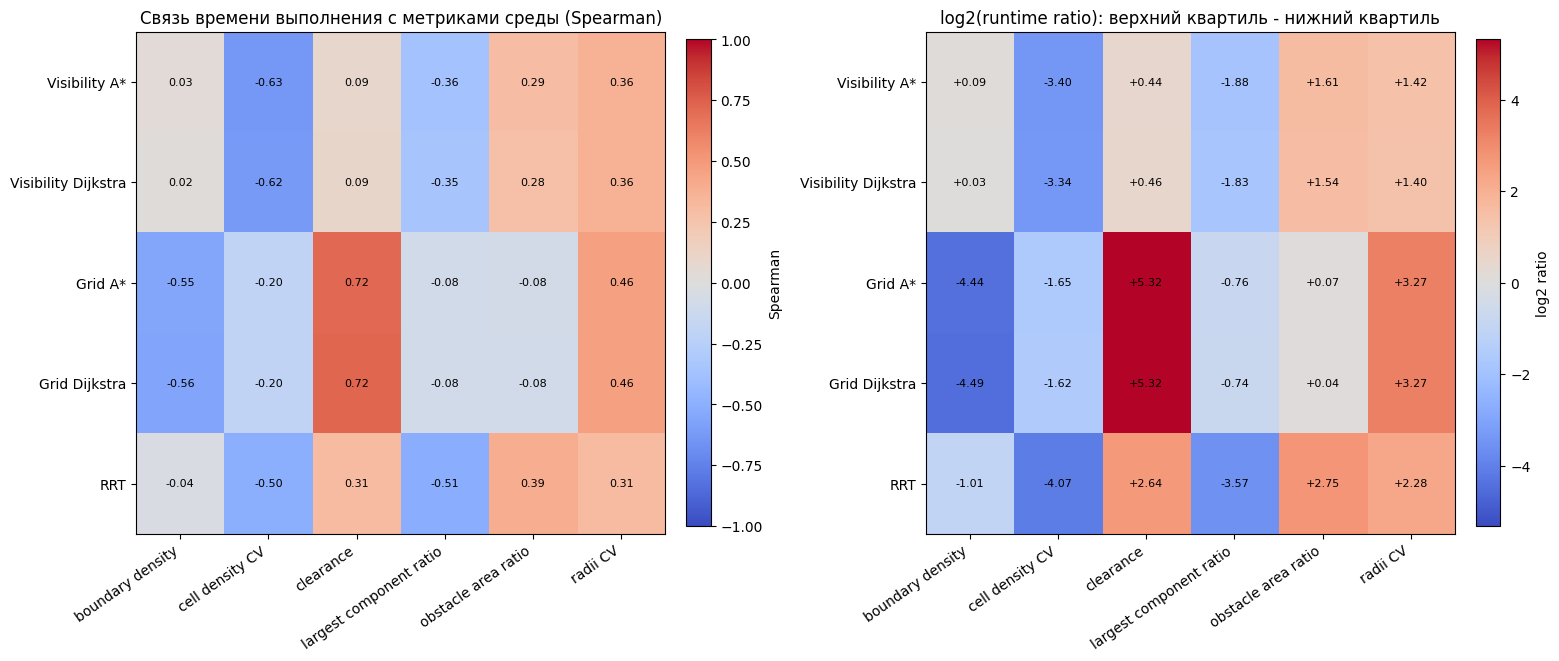

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.5), constrained_layout=True)

plot_runtime_corr_df = runtime_corr_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
runtime_corr_image = axes[0].imshow(plot_runtime_corr_df.values, aspect='auto', cmap='coolwarm', vmin=-1.0, vmax=1.0)
axes[0].set_title('Связь времени выполнения с метриками среды (Spearman)')
axes[0].set_yticks(range(len(plot_runtime_corr_df.index)))
axes[0].set_yticklabels(plot_runtime_corr_df.index)
axes[0].set_xticks(range(len(plot_runtime_corr_df.columns)))
axes[0].set_xticklabels(plot_runtime_corr_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_runtime_corr_df.index)):
    for col_index in range(len(plot_runtime_corr_df.columns)):
        value = plot_runtime_corr_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[0].text(col_index, row_index, f'{value:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(runtime_corr_image, ax=axes[0], fraction=0.046, pad=0.04, label='Spearman')

plot_runtime_ratio_df = runtime_ratio_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
runtime_ratio_image = axes[1].imshow(
    plot_runtime_ratio_df.values,
    aspect='auto',
    cmap='coolwarm',
    vmin=-runtime_ratio_abs_max,
    vmax=runtime_ratio_abs_max,
)
axes[1].set_title('log2(runtime ratio): верхний квартиль - нижний квартиль')
axes[1].set_yticks(range(len(plot_runtime_ratio_df.index)))
axes[1].set_yticklabels(plot_runtime_ratio_df.index)
axes[1].set_xticks(range(len(plot_runtime_ratio_df.columns)))
axes[1].set_xticklabels(plot_runtime_ratio_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_runtime_ratio_df.index)):
    for col_index in range(len(plot_runtime_ratio_df.columns)):
        value = plot_runtime_ratio_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[1].text(col_index, row_index, f'{value:+.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(runtime_ratio_image, ax=axes[1], fraction=0.046, pad=0.04, label='log2 ratio')

runtime_summary_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_metric_summary.png'
fig.savefig(runtime_summary_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', runtime_sensitivity_path)
print('Saved:', runtime_metric_summary_path)
print('Saved:', runtime_summary_figure_path)

### Таблицы ключевых связей времени выполнения

In [101]:
runtime_top_link_display_df = runtime_top_links_df[
    [
        'algorithm_label',
        'metric_label',
        'runtime_spearman',
        'runtime_ratio_high_to_low',
        'low_quantile_median_runtime_ms',
        'high_quantile_median_runtime_ms',
    ]
]
runtime_top_ratio_display_df = runtime_top_ratios_df[
    [
        'algorithm_label',
        'metric_label',
        'runtime_ratio_high_to_low',
        'log2_runtime_ratio_high_to_low',
        'runtime_spearman',
        'low_quantile_median_runtime_ms',
        'high_quantile_median_runtime_ms',
    ]
]

with pd.option_context('display.max_columns', None, 'display.width', 2200):
    display(runtime_top_link_display_df.head(12))
    display(runtime_top_ratio_display_df.head(12))

plt.show()

,algorithm_label,metric_label,runtime_spearman,runtime_ratio_high_to_low,low_quantile_median_runtime_ms,high_quantile_median_runtime_ms
0,Grid Dijkstra,clearance,0.720611,39.922043,37.1940,1484.86045
1,Grid A*,clearance,0.718561,39.945289,36.7190,1466.75105
2,Visibility A*,cell density CV,-0.630745,0.094586,523.8623,49.55015
3,Visibility Dijkstra,cell density CV,-0.622809,0.098749,525.9128,51.93325
4,Grid Dijkstra,boundary density,-0.556202,0.044558,847.1177,37.74620
5,Grid A*,boundary density,-0.552208,0.046100,808.9482,37.29265
6,RRT,largest component ratio,-0.508582,0.084030,88.4448,7.43205
7,RRT,cell density CV,-0.504150,0.059408,105.1850,6.24880
8,Grid A*,radii CV,0.463106,9.661588,58.8149,568.24535
9,Grid Dijkstra,radii CV,0.462714,9.634133,60.2059,580.03165


,algorithm_label,metric_label,runtime_ratio_high_to_low,log2_runtime_ratio_high_to_low,runtime_spearman,low_quantile_median_runtime_ms,high_quantile_median_runtime_ms
0,Grid A*,clearance,39.945289,5.319953,0.718561,36.7190,1466.75105
1,Grid Dijkstra,clearance,39.922043,5.319114,0.720611,37.1940,1484.86045
2,Grid Dijkstra,boundary density,0.044558,-4.488159,-0.556202,847.1177,37.74620
3,Grid A*,boundary density,0.046100,-4.439084,-0.552208,808.9482,37.29265
4,RRT,cell density CV,0.059408,-4.073206,-0.504150,105.1850,6.24880
5,RRT,largest component ratio,0.084030,-3.572945,-0.508582,88.4448,7.43205
6,Visibility A*,cell density CV,0.094586,-3.402226,-0.630745,523.8623,49.55015
7,Visibility Dijkstra,cell density CV,0.098749,-3.340093,-0.622809,525.9128,51.93325
8,Grid A*,radii CV,9.661588,3.272260,0.463106,58.8149,568.24535
9,Grid Dijkstra,radii CV,9.634133,3.268155,0.462714,60.2059,580.03165


### Профили успешности по квантилям метрик

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_success_profiles.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_success_profiles.png


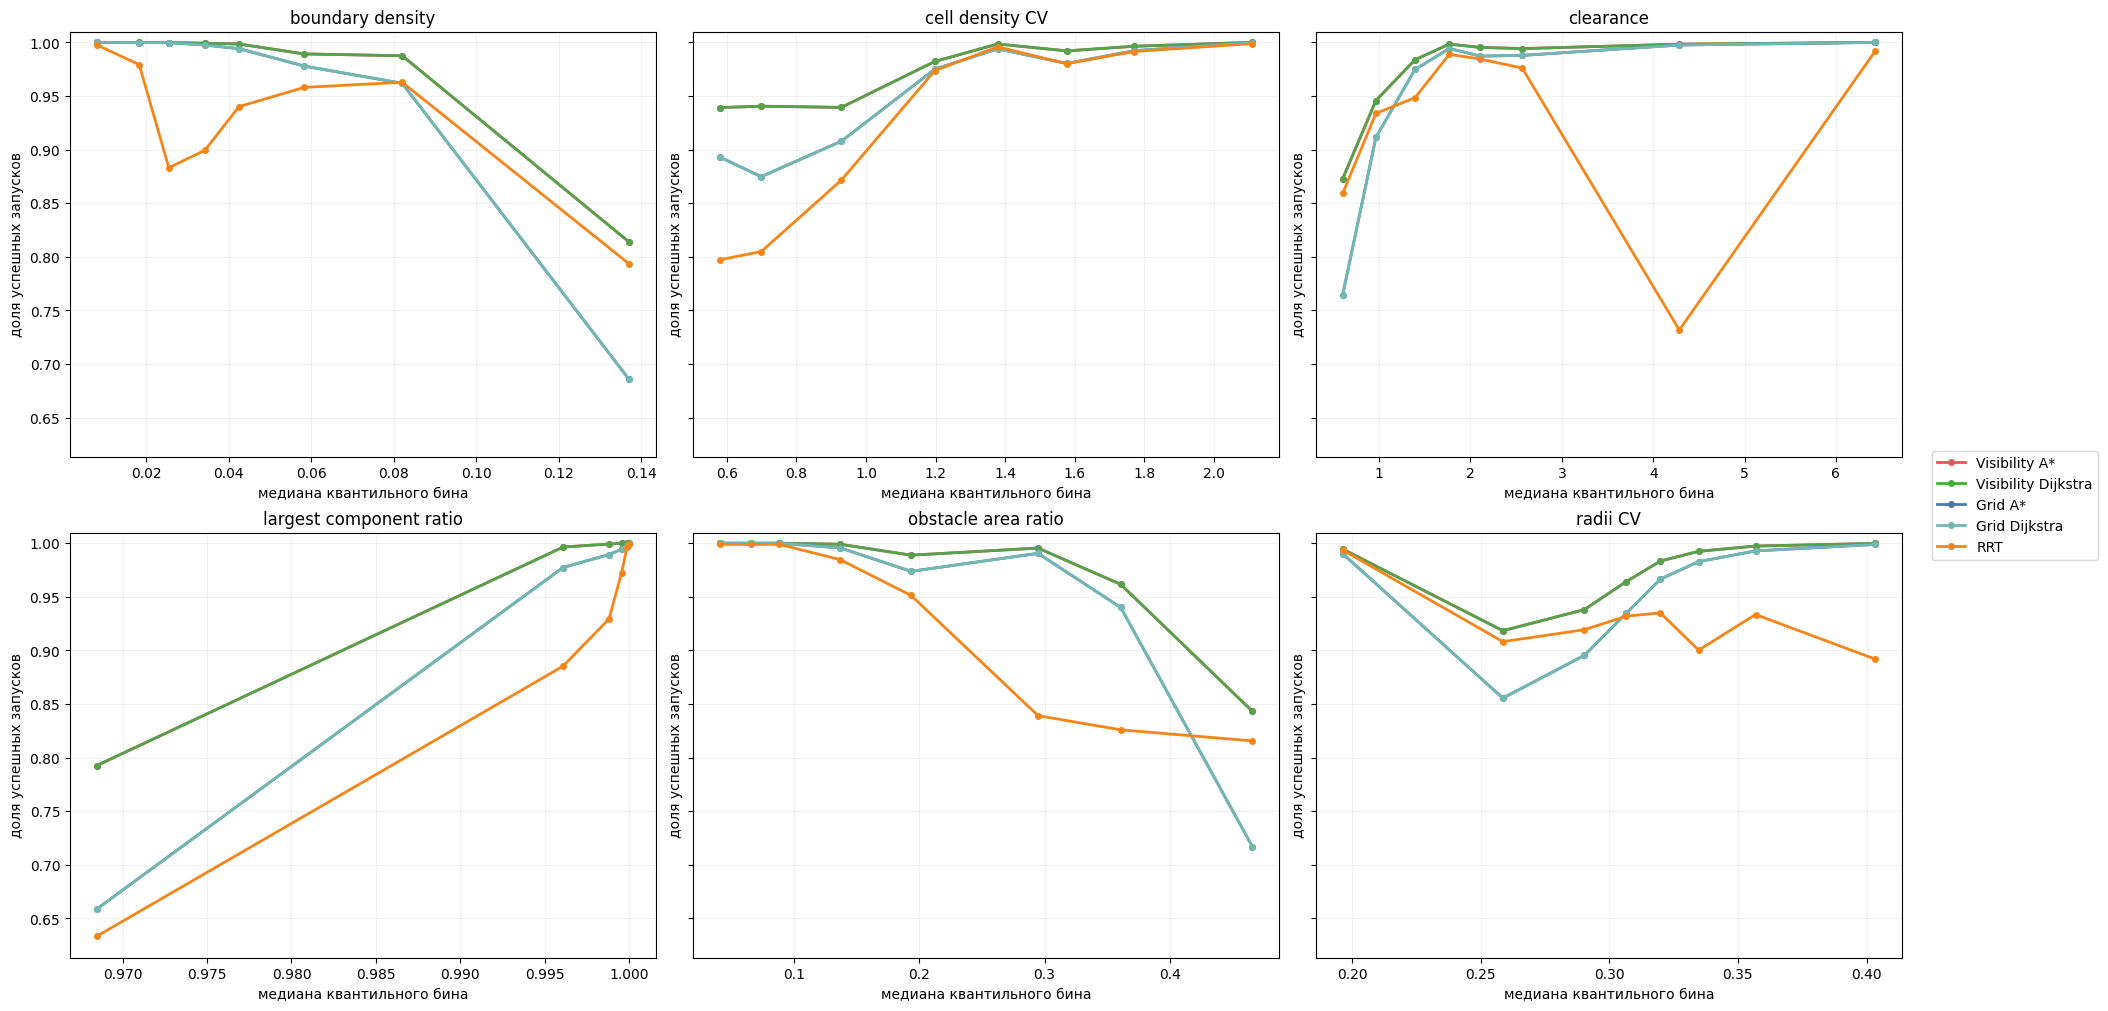

In [102]:
SUCCESS_PROFILE_METRICS = SUCCESS_METRICS.copy()
PROFILE_QUANTILES = 8

profile_frames = []
for metric in SUCCESS_PROFILE_METRICS:
    success_temp_df = EXECUTED_RUNS_DF[[metric, 'algorithm_id', 'path_found']].dropna().copy()
    success_temp_df, metric_bin_count = add_quantile_ranks(success_temp_df, metric, 'metric_bin_rank', q=PROFILE_QUANTILES)
    success_temp_df = success_temp_df.dropna(subset=['metric_bin_rank']).copy()
    if success_temp_df.empty or metric_bin_count < 2:
        continue
    success_profile_df = (
        success_temp_df.groupby(['algorithm_id', 'metric_bin_rank'])
        .agg(
            metric_value=(metric, 'median'),
            success_rate=('path_found', 'mean'),
            sample_count=('path_found', 'size'),
        )
        .reset_index()
        .sort_values(['algorithm_id', 'metric_value'])
        .reset_index(drop=True)
    )
    success_profile_df['metric'] = metric
    success_profile_df['metric_label'] = SCENE_METRIC_LABELS[metric]
    profile_frames.append(success_profile_df)

algorithm_profiles_df = pd.concat(profile_frames, ignore_index=True)
algorithm_profiles_df['algorithm_label'] = algorithm_profiles_df['algorithm_id'].map(ALGORITHM_LABELS).fillna(algorithm_profiles_df['algorithm_id'])
algorithm_profiles_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_profiles.csv'
algorithm_profiles_df.to_csv(algorithm_profiles_path, index=False)

success_profile_floor = max(0.6, float(algorithm_profiles_df['success_rate'].min()) - 0.02)

fig, axes = plt.subplots(2, 3, figsize=(19, 10), constrained_layout=True, sharey=True)
for ax, metric in zip(axes.ravel(), SUCCESS_PROFILE_METRICS):
    metric_df = algorithm_profiles_df.loc[algorithm_profiles_df['metric'] == metric].copy()
    for algorithm_id in plot_order:
        line_df = metric_df.loc[metric_df['algorithm_id'] == algorithm_id].sort_values('metric_value')
        ax.plot(
            line_df['metric_value'],
            line_df['success_rate'],
            marker='o',
            linewidth=2,
            markersize=4,
            label=ALGORITHM_LABELS.get(algorithm_id, algorithm_id),
            color=ALGORITHM_COLORS[algorithm_id],
        )
    ax.set_title(SCENE_METRIC_LABELS[metric])
    ax.set_xlabel('медиана квантильного бина')
    ax.set_ylabel('доля успешных запусков')
    ax.set_ylim(success_profile_floor, 1.01)
    ax.grid(alpha=0.25, linewidth=0.5)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.01, 0.5))
profile_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_profiles.png'
fig.savefig(profile_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', algorithm_profiles_path)
print('Saved:', profile_figure_path)
plt.show()

### Двумерные зоны риска по успешности

In [103]:
PAIR_PLOT_SPECS = [
    {
        'x': 'scene_metric_boundary_density',
        'y': 'scene_metric_clearance',
    },
    {
        'x': 'scene_metric_obstacle_area_ratio',
        'y': 'scene_metric_largest_component_ratio',
    },
]
PAIR_HEATMAP_ALGORITHMS = [best_success_algorithm, weakest_success_algorithm]
MIN_PAIR_SUPPORT = 40

pair_frames = []
pair_axis_label_map = {}
for spec in PAIR_PLOT_SPECS:
    pair_source_df = EXECUTED_RUNS_DF[['algorithm_id', spec['x'], spec['y'], 'path_found']].dropna().copy()
    pair_source_df, x_bin_count = add_quantile_ranks(pair_source_df, spec['x'], 'x_bin_rank', q=8)
    pair_source_df, y_bin_count = add_quantile_ranks(pair_source_df, spec['y'], 'y_bin_rank', q=8)
    pair_source_df = pair_source_df.dropna(subset=['x_bin_rank', 'y_bin_rank']).copy()
    if pair_source_df.empty or min(x_bin_count, y_bin_count) < 2:
        continue

    pair_title = f"{SCENE_METRIC_LABELS[spec['x']]} × {SCENE_METRIC_LABELS[spec['y']]}"

    pair_axis_label_map[(spec['x'], spec['y'])] = {
        'x': pair_source_df.groupby('x_bin_rank')[spec['x']].median().sort_index(),
        'y': pair_source_df.groupby('y_bin_rank')[spec['y']].median().sort_index(),
    }

    pair_profile_df = (
        pair_source_df.groupby(['algorithm_id', 'x_bin_rank', 'y_bin_rank'])
        .agg(
            x_value=(spec['x'], 'median'),
            y_value=(spec['y'], 'median'),
            success_rate=('path_found', 'mean'),
            sample_count=('path_found', 'size'),
        )
        .reset_index()
    )
    pair_profile_df['x_metric'] = spec['x']
    pair_profile_df['y_metric'] = spec['y']
    pair_profile_df['pair_title'] = pair_title
    pair_profile_df['algorithm_label'] = pair_profile_df['algorithm_id'].map(ALGORITHM_LABELS).fillna(pair_profile_df['algorithm_id'])
    pair_frames.append(pair_profile_df)

pair_success_df = pd.concat(pair_frames, ignore_index=True)
pair_success_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_pairs.csv'
pair_success_df.to_csv(pair_success_path, index=False)

supported_pair_df = pair_success_df.loc[pair_success_df['sample_count'] >= MIN_PAIR_SUPPORT].copy()
pair_success_floor = max(0.6, float(supported_pair_df['success_rate'].min()) - 0.03) if not supported_pair_df.empty else 0.6
pair_low_success_cells_df = (
    supported_pair_df
    .assign(
        x_metric_label=lambda df: df['x_metric'].map(SCENE_METRIC_LABELS).fillna(df['x_metric']),
        y_metric_label=lambda df: df['y_metric'].map(SCENE_METRIC_LABELS).fillna(df['y_metric']),
    )
    .sort_values(['success_rate', 'sample_count'], ascending=[True, False])
    .reset_index(drop=True)
)
pair_low_success_cells_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_pair_low_cells.csv'
pair_low_success_cells_df.to_csv(pair_low_success_cells_path, index=False)

### Heatmap успешности по парам метрик

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_success_pairs.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_success_pair_low_cells.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_success_pair_heatmaps.png


,algorithm_label,pair_title,success_rate,sample_count,x_value,y_value
0,RRT,boundary density × clearance,0.061776,259,0.039638,4.015899
1,RRT,boundary density × clearance,0.362534,742,0.032698,3.926940
2,Grid A*,obstacle area ratio × largest component ratio,0.512272,2852,0.496750,0.944086
3,Grid Dijkstra,obstacle area ratio × largest component ratio,0.512272,2852,0.496750,0.944086
4,Grid A*,boundary density × clearance,0.541284,763,0.121948,0.928571
5,Grid Dijkstra,boundary density × clearance,0.541284,763,0.121948,0.928571
6,RRT,obstacle area ratio × largest component ratio,0.561644,584,0.311650,0.983609
7,RRT,boundary density × clearance,0.566011,1424,0.026211,3.840862
8,RRT,obstacle area ratio × largest component ratio,0.569251,1509,0.361700,0.976390
9,Grid A*,boundary density × clearance,0.587345,2908,0.135191,0.553611


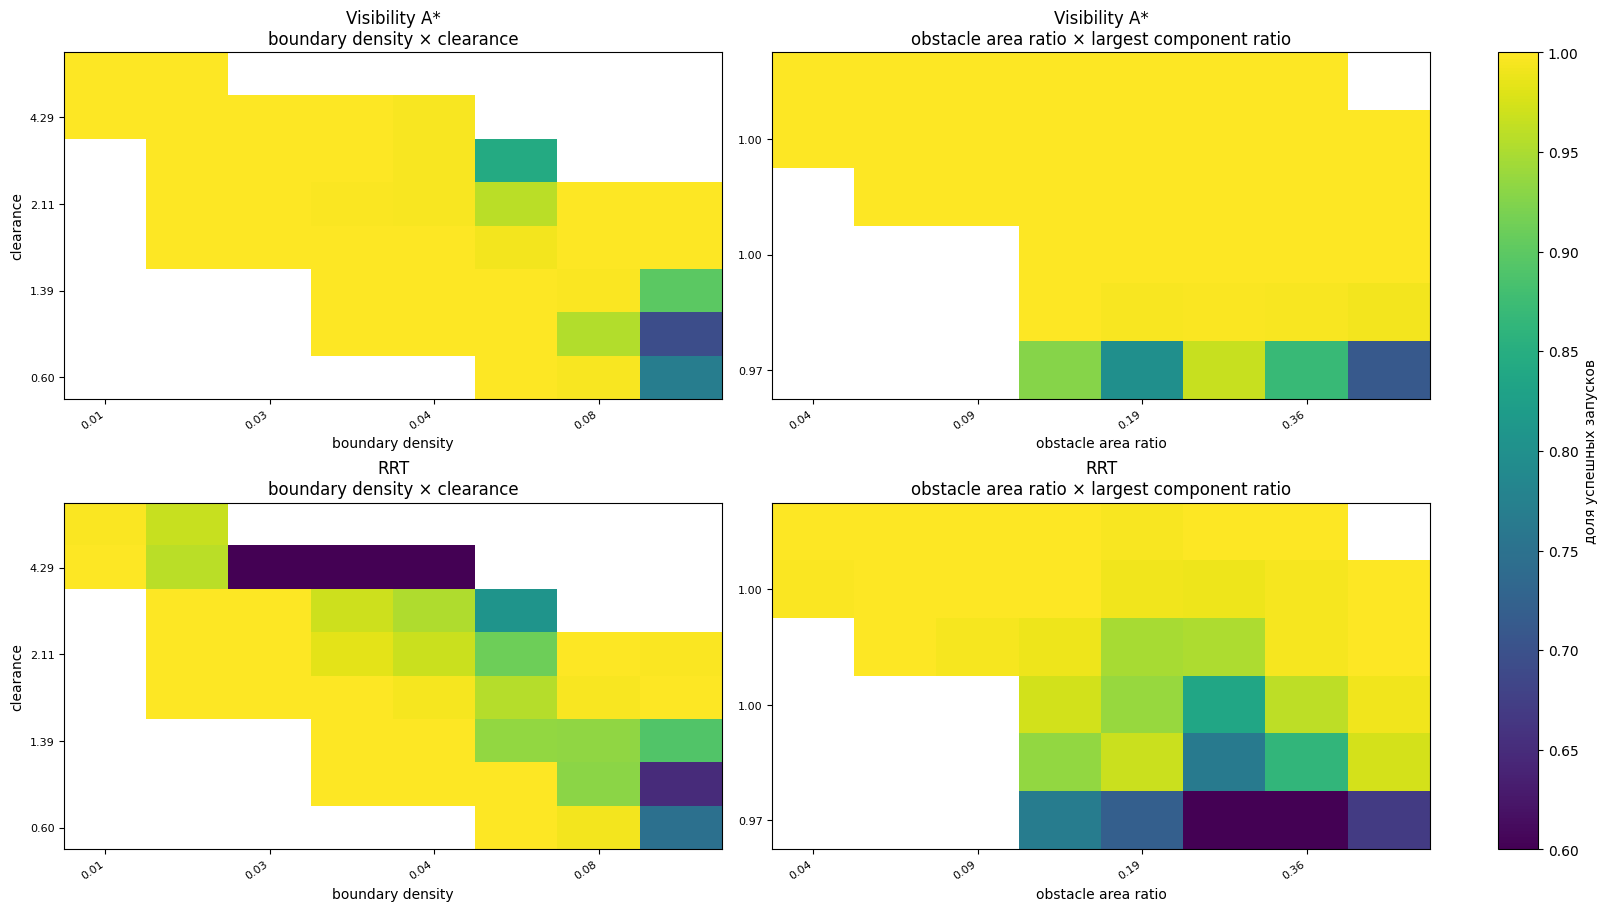

In [104]:
fig, axes = plt.subplots(
    len(PAIR_HEATMAP_ALGORITHMS),
    len(PAIR_PLOT_SPECS),
    figsize=(16, 9),
    constrained_layout=True,
)
if len(PAIR_HEATMAP_ALGORITHMS) == 1:
    axes = np.asarray([axes])

last_image = None
for row_index, algorithm_id in enumerate(PAIR_HEATMAP_ALGORITHMS):
    for col_index, spec in enumerate(PAIR_PLOT_SPECS):
        ax = axes[row_index, col_index]
        plot_df = pair_success_df.loc[
            (pair_success_df['algorithm_id'] == algorithm_id)
            & (pair_success_df['x_metric'] == spec['x'])
            & (pair_success_df['y_metric'] == spec['y'])
        ].copy()

        x_labels = pair_axis_label_map[(spec['x'], spec['y'])]['x']
        y_labels = pair_axis_label_map[(spec['x'], spec['y'])]['y']
        x_size = int(x_labels.index.max())
        y_size = int(y_labels.index.max())

        rate_matrix = np.full((y_size, x_size), np.nan)
        for row in plot_df.itertuples():
            if row.sample_count >= MIN_PAIR_SUPPORT:
                rate_matrix[int(row.y_bin_rank) - 1, int(row.x_bin_rank) - 1] = row.success_rate

        last_image = ax.imshow(
            rate_matrix,
            origin='lower',
            aspect='auto',
            cmap='viridis',
            vmin=pair_success_floor,
            vmax=1.0,
        )
        pair_title = plot_df['pair_title'].iloc[0] if not plot_df.empty else f"{SCENE_METRIC_LABELS[spec['x']]} × {SCENE_METRIC_LABELS[spec['y']]}"
        ax.set_title(f"{ALGORITHM_LABELS.get(algorithm_id, algorithm_id)}\n{pair_title}")
        ax.set_xlabel(SCENE_METRIC_LABELS[spec['x']])
        if col_index == 0:
            ax.set_ylabel(SCENE_METRIC_LABELS[spec['y']])

        x_tick_positions = list(range(0, x_size, 2))
        y_tick_positions = list(range(0, y_size, 2))
        ax.set_xticks(x_tick_positions)
        ax.set_xticklabels(
            [f'{x_labels.iloc[pos]:.2f}' for pos in x_tick_positions],
            rotation=35,
            ha='right',
            fontsize=8,
        )
        ax.set_yticks(y_tick_positions)
        ax.set_yticklabels([f'{y_labels.iloc[pos]:.2f}' for pos in y_tick_positions], fontsize=8)

fig.colorbar(last_image, ax=axes, label='доля успешных запусков')
pair_heatmap_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_success_pair_heatmaps.png'
fig.savefig(pair_heatmap_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', pair_success_path)
print('Saved:', pair_low_success_cells_path)
print('Saved:', pair_heatmap_figure_path)

with pd.option_context('display.max_columns', None, 'display.width', 2200):
    display(pair_low_success_cells_df[['algorithm_label', 'pair_title', 'success_rate', 'sample_count', 'x_value', 'y_value']].head(12))

plt.show()

Линейные профили показывают форму зависимости успешности от каждой метрики среды, а двумерные heatmap-графики помогают локализовать сочетания параметров, где алгоритмы теряют устойчивость.

Для relative_path_length более высокие значения означают менее качественный путь. Поэтому положительные значения на правой heatmap отражают ухудшение качества при переходе к более сложным сценам, а отрицательные значения указывают на отсутствие заметной деградации или на слабую чувствительность алгоритма к соответствующей метрике.

### Корреляции качества пути с параметрами среды

In [105]:
QUALITY_METRICS = SCENE_METRIC_COLUMNS.copy()
quality_source_df = SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['relative_path_length'] > 0].copy()

quality_correlation_pairs_df = (
    algorithm_metric_correlations_df.loc[
        algorithm_metric_correlations_df['metric'].isin(QUALITY_METRICS),
        ['algorithm_id', 'metric', 'quality_spearman', 'quality_sample_size']
    ]
    .copy()
)
quality_corr_heatmap_df = (
    quality_correlation_pairs_df
    .pivot(index='algorithm_id', columns='metric', values='quality_spearman')
    .reindex(index=plot_order, columns=QUALITY_METRICS)
)

### Чувствительность качества пути к усложнению сцены

In [106]:
quality_sensitivity_rows = []
for algorithm_id, algorithm_df in quality_source_df.groupby('algorithm_id'):
    for metric in QUALITY_METRICS:
        metric_df = algorithm_df[[metric, 'relative_path_length']].dropna().copy()
        metric_df, quantile_count = add_quantile_ranks(metric_df, metric, 'metric_quantile_rank', q=4)
        metric_df = metric_df.dropna(subset=['metric_quantile_rank']).copy()
        if metric_df.empty or quantile_count < 2:
            continue

        profile_df = (
            metric_df.groupby('metric_quantile_rank')
            .agg(
                metric_value=(metric, 'median'),
                median_relative_path_length=('relative_path_length', 'median'),
                p90_relative_path_length=('relative_path_length', lambda s: s.quantile(0.9)),
                sample_count=('relative_path_length', 'size'),
            )
            .reset_index()
            .sort_values('metric_value')
            .reset_index(drop=True)
        )

        low_row = profile_df.iloc[0]
        high_row = profile_df.iloc[-1]
        delta_quality = high_row['median_relative_path_length'] - low_row['median_relative_path_length']

        quality_sensitivity_rows.append({
            'algorithm_id': algorithm_id,
            'metric': metric,
            'low_metric_value': low_row['metric_value'],
            'high_metric_value': high_row['metric_value'],
            'low_quantile_median_relative_path_length': low_row['median_relative_path_length'],
            'high_quantile_median_relative_path_length': high_row['median_relative_path_length'],
            'low_quantile_p90_relative_path_length': low_row['p90_relative_path_length'],
            'high_quantile_p90_relative_path_length': high_row['p90_relative_path_length'],
            'low_quantile_sample_count': low_row['sample_count'],
            'high_quantile_sample_count': high_row['sample_count'],
            'delta_relative_path_length': delta_quality,
            'quantile_count': quantile_count,
        })

quality_sensitivity_df = pd.DataFrame(quality_sensitivity_rows)
quality_sensitivity_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_sensitivity.csv'
quality_sensitivity_df.to_csv(quality_sensitivity_path, index=False)

quality_delta_heatmap_df = (
    quality_sensitivity_df
    .pivot(index='algorithm_id', columns='metric', values='delta_relative_path_length')
    .reindex(index=plot_order, columns=QUALITY_METRICS)
)

quality_metric_summary_df = (
    quality_correlation_pairs_df
    .merge(quality_sensitivity_df, on=['algorithm_id', 'metric'], how='left')
    .assign(
        algorithm_label=lambda df: df['algorithm_id'].map(ALGORITHM_LABELS).fillna(df['algorithm_id']),
        metric_label=lambda df: df['metric'].map(SCENE_METRIC_LABELS).fillna(df['metric']),
    )
)
quality_metric_summary_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_metric_summary.csv'
quality_metric_summary_df.to_csv(quality_metric_summary_path, index=False)

quality_top_links_df = (
    quality_metric_summary_df
    .assign(abs_quality_spearman=lambda df: df['quality_spearman'].abs())
    .sort_values('abs_quality_spearman', ascending=False)
    .reset_index(drop=True)
)
quality_top_deltas_df = (
    quality_metric_summary_df
    .assign(abs_delta_relative_path_length=lambda df: df['delta_relative_path_length'].abs())
    .sort_values('abs_delta_relative_path_length', ascending=False)
    .reset_index(drop=True)
)

quality_delta_abs_max = np.nanmax(np.abs(quality_delta_heatmap_df.values))
quality_delta_abs_max = max(0.002, float(quality_delta_abs_max if np.isfinite(quality_delta_abs_max) else 0.002))

### Сводная визуализация качества пути

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_quality_sensitivity.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_quality_metric_summary.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_quality_metric_summary.png


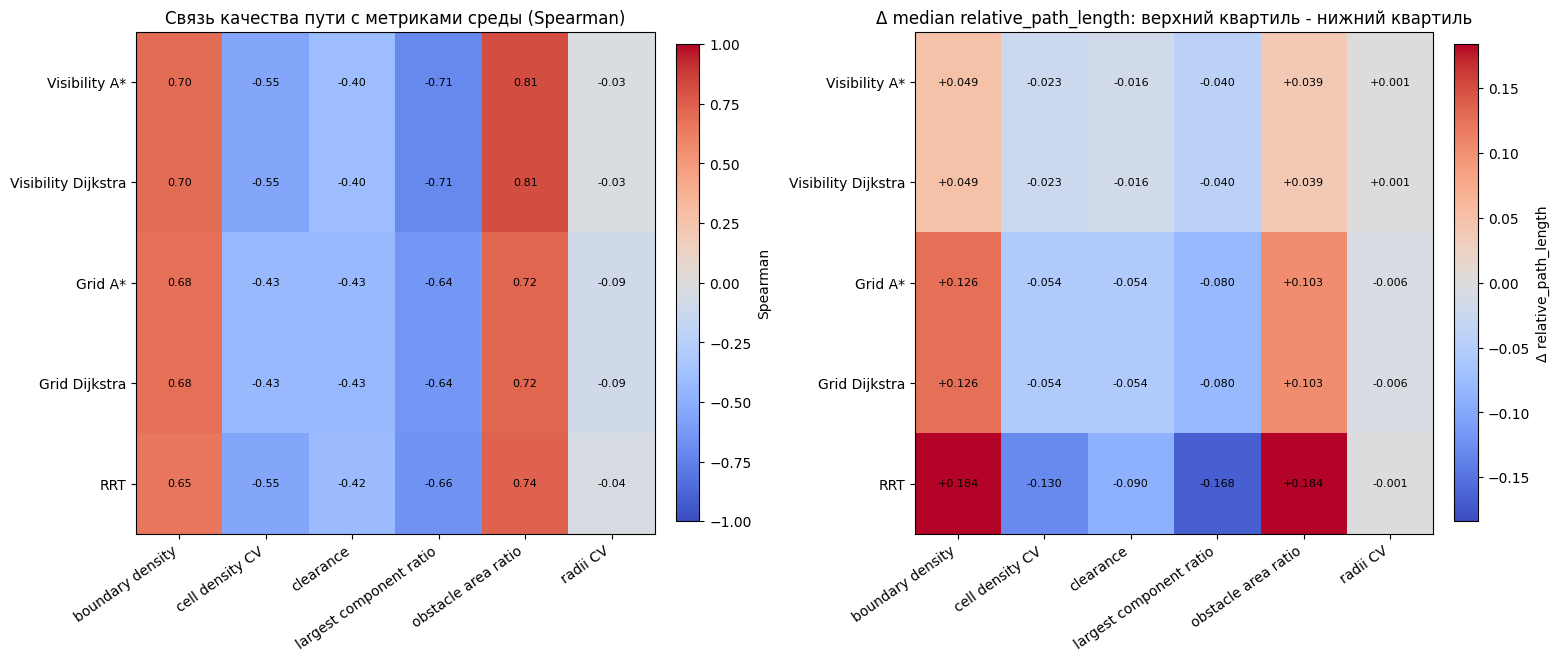

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.5), constrained_layout=True)

plot_quality_corr_df = quality_corr_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
quality_corr_image = axes[0].imshow(plot_quality_corr_df.values, aspect='auto', cmap='coolwarm', vmin=-1.0, vmax=1.0)
axes[0].set_title('Связь качества пути с метриками среды (Spearman)')
axes[0].set_yticks(range(len(plot_quality_corr_df.index)))
axes[0].set_yticklabels(plot_quality_corr_df.index)
axes[0].set_xticks(range(len(plot_quality_corr_df.columns)))
axes[0].set_xticklabels(plot_quality_corr_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_quality_corr_df.index)):
    for col_index in range(len(plot_quality_corr_df.columns)):
        value = plot_quality_corr_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[0].text(col_index, row_index, f'{value:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(quality_corr_image, ax=axes[0], fraction=0.046, pad=0.04, label='Spearman')

plot_quality_delta_df = quality_delta_heatmap_df.rename(index=ALGORITHM_LABELS, columns=SCENE_METRIC_LABELS)
quality_delta_image = axes[1].imshow(
    plot_quality_delta_df.values,
    aspect='auto',
    cmap='coolwarm',
    vmin=-quality_delta_abs_max,
    vmax=quality_delta_abs_max,
)
axes[1].set_title('Δ median relative_path_length: верхний квартиль - нижний квартиль')
axes[1].set_yticks(range(len(plot_quality_delta_df.index)))
axes[1].set_yticklabels(plot_quality_delta_df.index)
axes[1].set_xticks(range(len(plot_quality_delta_df.columns)))
axes[1].set_xticklabels(plot_quality_delta_df.columns, rotation=35, ha='right')
for row_index in range(len(plot_quality_delta_df.index)):
    for col_index in range(len(plot_quality_delta_df.columns)):
        value = plot_quality_delta_df.iloc[row_index, col_index]
        if pd.notna(value):
            axes[1].text(col_index, row_index, f'{value:+.3f}', ha='center', va='center', fontsize=8)
fig.colorbar(quality_delta_image, ax=axes[1], fraction=0.046, pad=0.04, label='Δ relative_path_length')

quality_summary_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_metric_summary.png'
fig.savefig(quality_summary_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', quality_sensitivity_path)
print('Saved:', quality_metric_summary_path)
print('Saved:', quality_summary_figure_path)

### Таблицы ключевых связей качества пути

In [108]:
quality_top_link_display_df = quality_top_links_df[
    [
        'algorithm_label',
        'metric_label',
        'quality_spearman',
        'delta_relative_path_length',
        'low_quantile_median_relative_path_length',
        'high_quantile_median_relative_path_length',
    ]
]
quality_top_delta_display_df = quality_top_deltas_df[
    [
        'algorithm_label',
        'metric_label',
        'delta_relative_path_length',
        'quality_spearman',
        'low_quantile_median_relative_path_length',
        'high_quantile_median_relative_path_length',
    ]
]

with pd.option_context('display.max_columns', None, 'display.width', 2200):
    display(quality_top_link_display_df.head(12))
    display(quality_top_delta_display_df.head(12))

plt.show()

,algorithm_label,metric_label,quality_spearman,delta_relative_path_length,low_quantile_median_relative_path_length,high_quantile_median_relative_path_length
0,Visibility Dijkstra,obstacle area ratio,0.813448,0.038766,1.000803,1.039569
1,Visibility A*,obstacle area ratio,0.813448,0.038766,1.000803,1.039569
2,RRT,obstacle area ratio,0.737049,0.183871,1.011404,1.195276
3,Grid A*,obstacle area ratio,0.722728,0.102912,1.028025,1.130937
4,Grid Dijkstra,obstacle area ratio,0.722728,0.102912,1.028025,1.130937
5,Visibility Dijkstra,largest component ratio,-0.713549,-0.040483,1.042243,1.001760
6,Visibility A*,largest component ratio,-0.713549,-0.040483,1.042243,1.001760
7,Visibility Dijkstra,boundary density,0.696099,0.049143,1.001191,1.050333
8,Visibility A*,boundary density,0.696099,0.049143,1.001191,1.050333
9,Grid Dijkstra,boundary density,0.684438,0.126081,1.028202,1.154283


,algorithm_label,metric_label,delta_relative_path_length,quality_spearman,low_quantile_median_relative_path_length,high_quantile_median_relative_path_length
0,RRT,obstacle area ratio,0.183871,0.737049,1.011404,1.195276
1,RRT,boundary density,0.183845,0.654088,1.012192,1.196037
2,RRT,largest component ratio,-0.167790,-0.662441,1.188642,1.020851
3,RRT,cell density CV,-0.129604,-0.548810,1.144015,1.014410
4,Grid Dijkstra,boundary density,0.126081,0.684438,1.028202,1.154283
5,Grid A*,boundary density,0.126081,0.684438,1.028202,1.154283
6,Grid Dijkstra,obstacle area ratio,0.102912,0.722728,1.028025,1.130937
7,Grid A*,obstacle area ratio,0.102912,0.722728,1.028025,1.130937
8,RRT,clearance,-0.090408,-0.418764,1.106266,1.015857
9,Grid Dijkstra,largest component ratio,-0.079919,-0.637072,1.117850,1.037931


Для relative_path_length более высокие значения означают менее качественный путь. Поэтому положительные значения на правой heatmap отражают ухудшение качества при переходе к более сложным сценам, а отрицательные значения указывают на отсутствие заметной деградации или на слабую чувствительность алгоритма к соответствующей метрике.

### Приоритет метрик для анализа качества пути

In [109]:
quality_metric_priority_df = (
    quality_metric_summary_df
    .assign(
        abs_quality_spearman=lambda df: df['quality_spearman'].abs(),
        abs_delta_relative_path_length=lambda df: df['delta_relative_path_length'].abs(),
    )
    .groupby('metric', as_index=False)
    .agg(
        max_abs_quality_spearman=('abs_quality_spearman', 'max'),
        max_abs_delta_relative_path_length=('abs_delta_relative_path_length', 'max'),
    )
    .sort_values(['max_abs_quality_spearman', 'max_abs_delta_relative_path_length'], ascending=False)
    .reset_index(drop=True)
)
quality_metric_priority_df['metric_label'] = quality_metric_priority_df['metric'].map(SCENE_METRIC_LABELS).fillna(quality_metric_priority_df['metric'])
quality_metric_priority_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_metric_priority.csv'
quality_metric_priority_df.to_csv(quality_metric_priority_path, index=False)

### Профили качества пути по квантилям

In [110]:
QUALITY_PROFILE_METRICS = quality_metric_priority_df['metric'].head(min(3, len(quality_metric_priority_df))).tolist()

quality_profile_metric_count = max(1, len(QUALITY_PROFILE_METRICS))

quality_profile_rows = []
for algorithm_id, algorithm_df in quality_source_df.groupby('algorithm_id'):
    for metric in QUALITY_PROFILE_METRICS:
        metric_df = algorithm_df[[metric, 'relative_path_length']].dropna().copy()
        metric_df, quantile_count = add_quantile_ranks(metric_df, metric, 'metric_quantile_rank', q=6)
        metric_df = metric_df.dropna(subset=['metric_quantile_rank']).copy()
        if metric_df.empty or quantile_count < 3:
            continue

        profile_df = (
            metric_df.groupby('metric_quantile_rank')
            .agg(
                metric_value=(metric, 'median'),
                median_relative_path_length=('relative_path_length', 'median'),
                q25_relative_path_length=('relative_path_length', lambda s: s.quantile(0.25)),
                q75_relative_path_length=('relative_path_length', lambda s: s.quantile(0.75)),
                sample_count=('relative_path_length', 'size'),
            )
            .reset_index()
            .sort_values('metric_value')
            .reset_index(drop=True)
        )
        profile_df['algorithm_id'] = algorithm_id
        profile_df['algorithm_label'] = ALGORITHM_LABELS.get(algorithm_id, algorithm_id)
        profile_df['metric'] = metric
        profile_df['metric_label'] = SCENE_METRIC_LABELS.get(metric, metric)
        profile_df['quantile_count'] = quantile_count
        quality_profile_rows.append(profile_df)

quality_profiles_df = pd.concat(quality_profile_rows, ignore_index=True) if quality_profile_rows else pd.DataFrame()
quality_profiles_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_profiles.csv'
quality_profiles_df.to_csv(quality_profiles_path, index=False)

### Визуализация профилей качества

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_quality_metric_priority.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_quality_profiles.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_quality_profiles.png


,metric,max_abs_quality_spearman,max_abs_delta_relative_path_length,metric_label
0,scene_metric_obstacle_area_ratio,0.813448,0.183871,obstacle area ratio
1,scene_metric_largest_component_ratio,0.713549,0.167790,largest component ratio
2,scene_metric_boundary_density,0.696099,0.183845,boundary density
3,scene_metric_cell_density_cv,0.552543,0.129604,cell density CV
4,scene_metric_clearance,0.434125,0.090408,clearance
5,scene_metric_radii_cv,0.094682,0.006348,radii CV


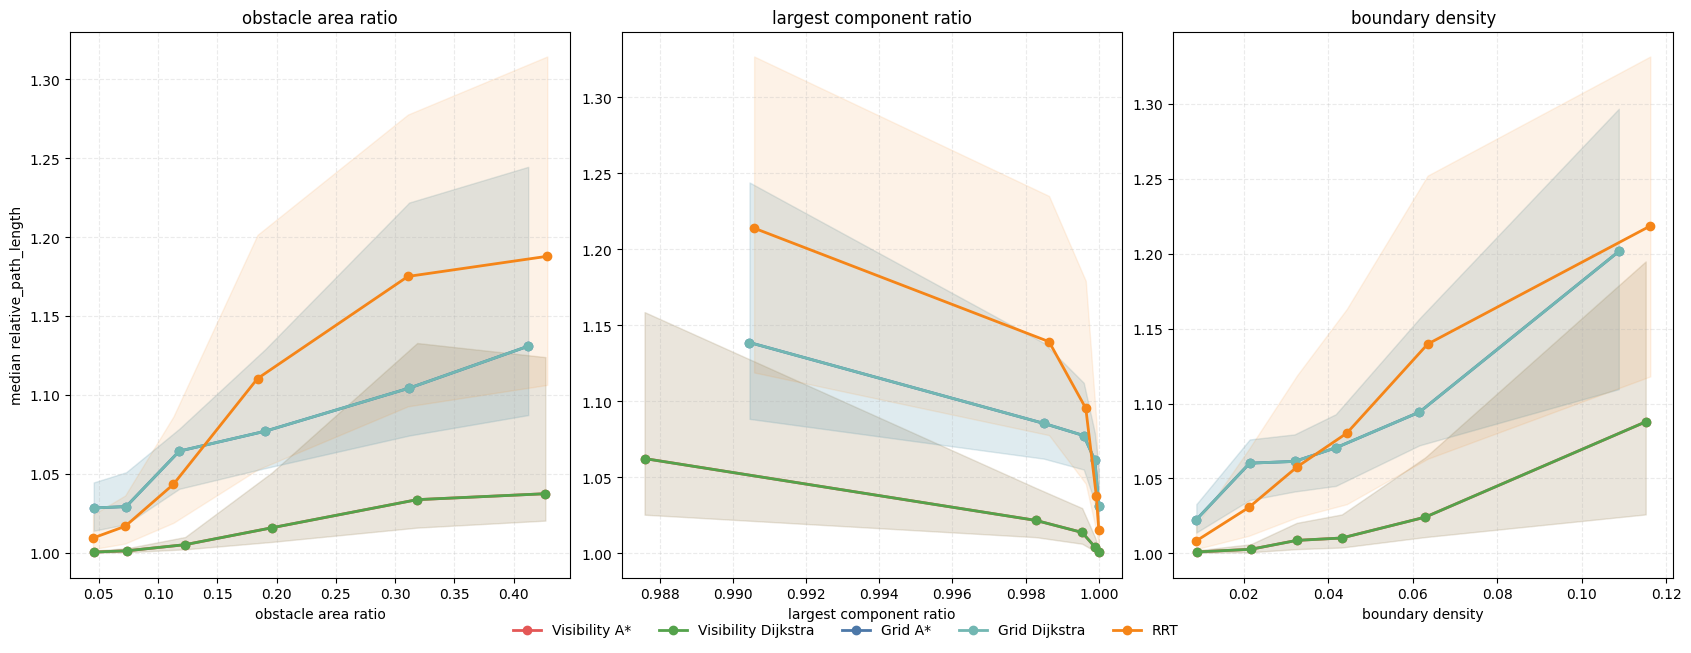

In [111]:
fig, axes = plt.subplots(1, quality_profile_metric_count, figsize=(5.6 * quality_profile_metric_count, 6.2), constrained_layout=True, squeeze=False)
axes = axes.ravel()

if QUALITY_PROFILE_METRICS and not quality_profiles_df.empty:
    for axis_index, metric in enumerate(QUALITY_PROFILE_METRICS):
        ax = axes[axis_index]
        metric_plot_df = quality_profiles_df.loc[quality_profiles_df['metric'] == metric].copy()
        for algorithm_id in plot_order:
            algo_df = metric_plot_df.loc[metric_plot_df['algorithm_id'] == algorithm_id].sort_values('metric_value')
            if algo_df.empty:
                continue

            x_values = algo_df['metric_value'].to_numpy()
            y_values = algo_df['median_relative_path_length'].to_numpy()
            lower_values = algo_df['q25_relative_path_length'].to_numpy()
            upper_values = algo_df['q75_relative_path_length'].to_numpy()
            color = ALGORITHM_COLORS[algorithm_id]

            ax.plot(
                x_values,
                y_values,
                marker='o',
                linewidth=2,
                color=color,
                label=ALGORITHM_LABELS.get(algorithm_id, algorithm_id),
            )
            ax.fill_between(x_values, lower_values, upper_values, color=color, alpha=0.10)

        ax.set_title(SCENE_METRIC_LABELS.get(metric, metric))
        ax.set_xlabel(SCENE_METRIC_LABELS.get(metric, metric))
        if axis_index == 0:
            ax.set_ylabel('median relative_path_length')
        ax.grid(alpha=0.25, linestyle='--')

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.04), ncol=min(5, len(handles)), frameon=False)
else:
    axes[0].axis('off')
    axes[0].text(0.5, 0.5, 'Недостаточно данных для quality-профилей', ha='center', va='center')

quality_profiles_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_profiles.png'
fig.savefig(quality_profiles_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', quality_metric_priority_path)
print('Saved:', quality_profiles_path)
print('Saved:', quality_profiles_figure_path)

with pd.option_context('display.max_columns', None, 'display.width', 2200):
    display(quality_metric_priority_df.head(6))

plt.show()

### Scatter-сравнение качества пути

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_quality_algorithm_scatter.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_quality_algorithm_scatter.png


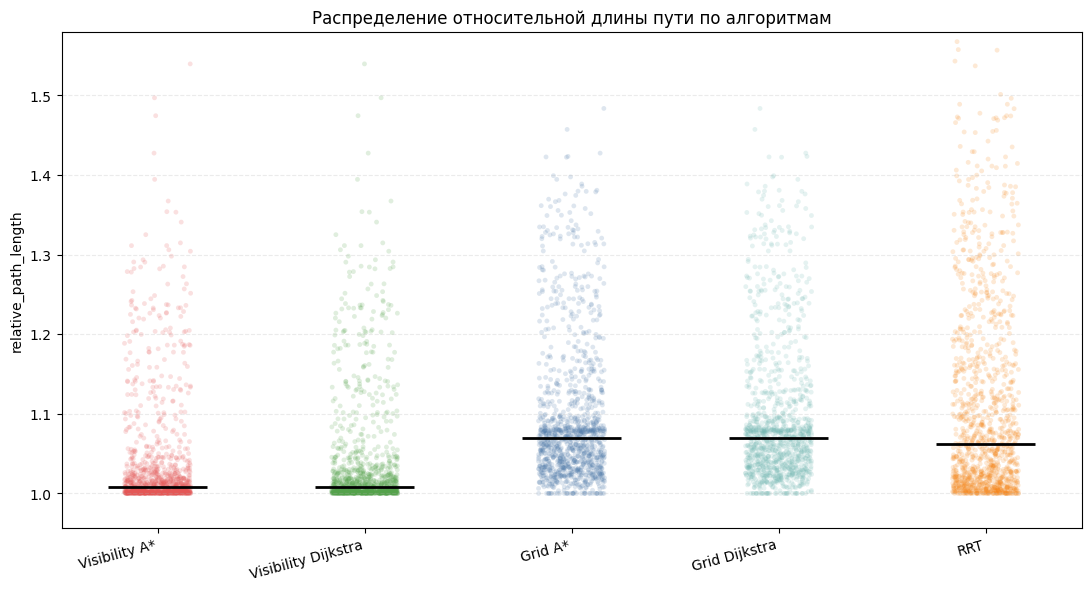

In [112]:
quality_scatter_frames = []
for algorithm_id, algorithm_df in quality_source_df.groupby('algorithm_id'):
    sample_size = min(len(algorithm_df), 1200)
    sample_df = algorithm_df.sample(sample_size, random_state=42).copy() if sample_size > 0 else algorithm_df.head(0).copy()
    if sample_df.empty:
        continue
    sample_df['algorithm_label'] = ALGORITHM_LABELS.get(algorithm_id, algorithm_id)
    quality_scatter_frames.append(sample_df[['algorithm_id', 'algorithm_label', 'relative_path_length']])

quality_algorithm_scatter_df = pd.concat(quality_scatter_frames, ignore_index=True) if quality_scatter_frames else pd.DataFrame(columns=['algorithm_id', 'algorithm_label', 'relative_path_length'])
quality_algorithm_scatter_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_algorithm_scatter.csv'
quality_algorithm_scatter_df.to_csv(quality_algorithm_scatter_path, index=False)

fig, ax = plt.subplots(figsize=(10.8, 5.8), constrained_layout=True)
rng = np.random.default_rng(42)
for axis_index, algorithm_id in enumerate(plot_order):
    algo_df = quality_algorithm_scatter_df.loc[quality_algorithm_scatter_df['algorithm_id'] == algorithm_id].copy()
    if algo_df.empty:
        continue

    x_values = np.full(len(algo_df), axis_index, dtype=float) + rng.uniform(-0.16, 0.16, len(algo_df))
    y_values = algo_df['relative_path_length'].to_numpy()
    color = ALGORITHM_COLORS[algorithm_id]

    ax.scatter(x_values, y_values, s=12, alpha=0.18, color=color, edgecolors='none')
    ax.hlines(np.median(y_values), axis_index - 0.24, axis_index + 0.24, color='black', linewidth=2)

ax.set_xticks(range(len(plot_order)))
ax.set_xticklabels([ALGORITHM_LABELS.get(algorithm_id, algorithm_id) for algorithm_id in plot_order], rotation=15, ha='right')
ax.set_ylabel('relative_path_length')
ax.set_title('Распределение относительной длины пути по алгоритмам')
ax.grid(axis='y', alpha=0.25, linestyle='--')

if not quality_algorithm_scatter_df.empty:
    upper_limit = quality_algorithm_scatter_df['relative_path_length'].quantile(0.995)
    lower_limit = quality_algorithm_scatter_df['relative_path_length'].quantile(0.005)
    if pd.notna(lower_limit) and pd.notna(upper_limit) and upper_limit > lower_limit:
        margin = max(0.002, (upper_limit - lower_limit) * 0.08)
        ax.set_ylim(lower_limit - margin, upper_limit + margin)

quality_algorithm_scatter_figure_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_quality_algorithm_scatter.png'
fig.savefig(quality_algorithm_scatter_figure_path, dpi=180, bbox_inches='tight')
print('Saved:', quality_algorithm_scatter_path)
print('Saved:', quality_algorithm_scatter_figure_path)

plt.show()

Для relative_path_length более высокие значения означают менее качественный путь. Поэтому положительные значения на правой heatmap отражают ухудшение качества при переходе к более сложным сценам, а отрицательные значения указывают на отсутствие заметной деградации или на слабую чувствительность алгоритма к соответствующей метрике.

## Дополнительные визуализации и итоговая интерпретация

В этой части добавлены более наглядные визуальные представления результатов: линейные профили по конфигам, круговые диаграммы исходов и победителей, ECDF-кривые, scatter-графики и итоговый текстовый вывод.

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_config_lines.png


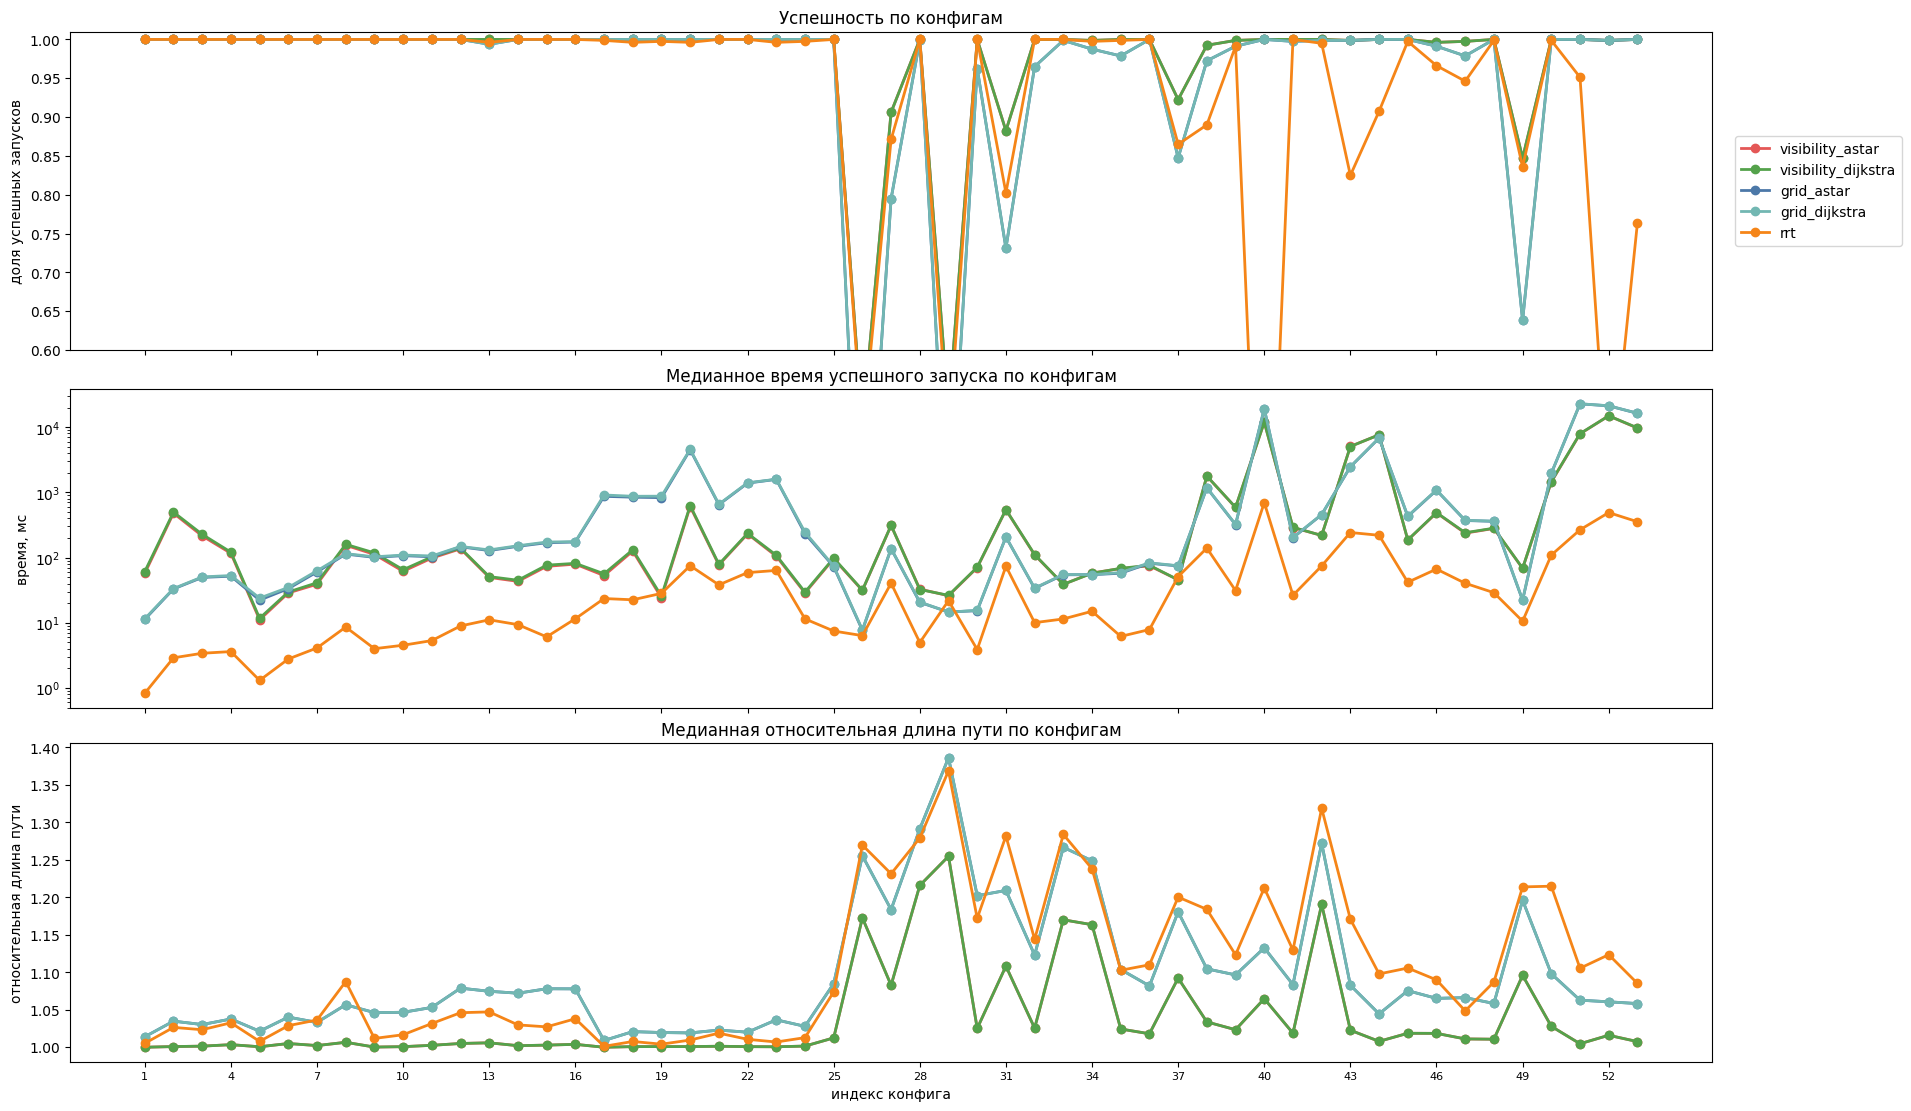

In [113]:
fig, axes = plt.subplots(3, 1, figsize=(19, 11), constrained_layout=True, sharex=True)

for algorithm_id in plot_order:
    algo_success_df = config_success_df.loc[config_success_df['algorithm_id'] == algorithm_id].sort_values('config_index')
    axes[0].plot(algo_success_df['config_index'], algo_success_df['success_rate'], marker='o', linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[0].set_title('Успешность по конфигам')
axes[0].set_ylabel('доля успешных запусков')
axes[0].set_ylim(0.6, 1.01)
axes[0].legend(loc='center left', bbox_to_anchor=(1.01, 0.5))

for algorithm_id in plot_order:
    algo_runtime_df = config_runtime_df.loc[config_runtime_df['algorithm_id'] == algorithm_id].sort_values('config_index')
    axes[1].plot(algo_runtime_df['config_index'], algo_runtime_df['median_runtime_success_ms'], marker='o', linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[1].set_title('Медианное время успешного запуска по конфигам')
axes[1].set_ylabel('время, мс')
axes[1].set_yscale('log')

for algorithm_id in plot_order:
    algo_quality_df = config_quality_df.loc[config_quality_df['algorithm_id'] == algorithm_id].sort_values('config_index')
    axes[2].plot(algo_quality_df['config_index'], algo_quality_df['median_relative_path_length'], marker='o', linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[2].set_title('Медианная относительная длина пути по конфигам')
axes[2].set_ylabel('относительная длина пути')
axes[2].set_xlabel('индекс конфига')

for ax in axes:
    ax.set_xticks(range(1, int(config_success_df['config_index'].max()) + 1, 3))
    ax.tick_params(axis='x', labelrotation=0, labelsize=8)

config_lines_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_config_lines.png'
fig.savefig(config_lines_path, dpi=180, bbox_inches='tight')
print('Saved:', config_lines_path)
plt.show()

Линейные графики показывают, на каких конфигурациях алгоритмы начинают резко расходиться. Это полезно для выделения семейств сцен, где преимущества конкретного метода становятся критически важными.

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_outcome_donuts.png


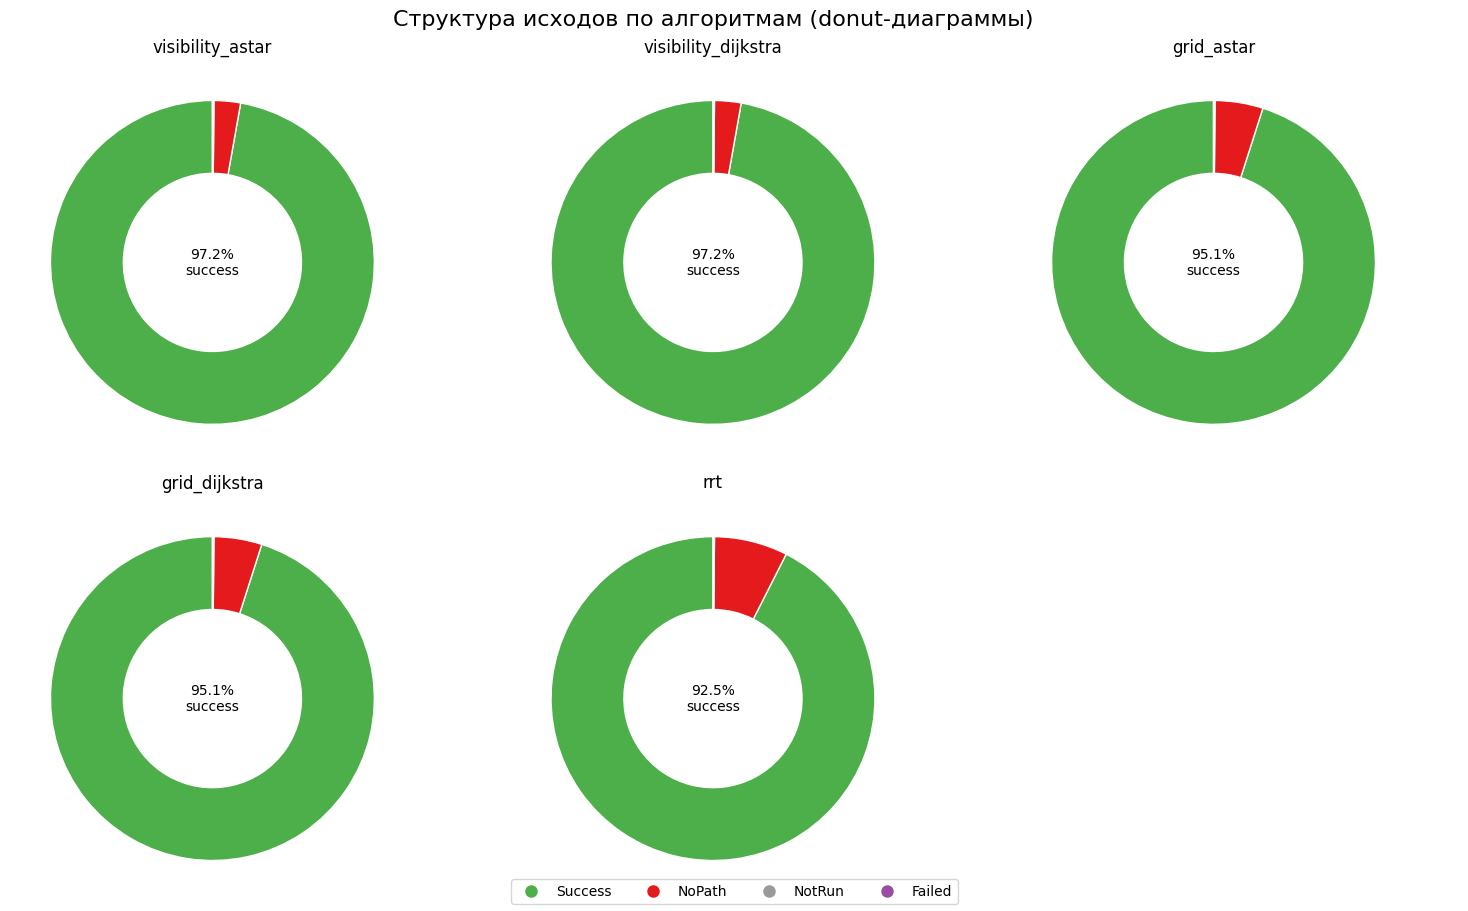

In [114]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
axes = axes.ravel()
status_colors = {'Success': '#4daf4a', 'NoPath': '#e41a1c', 'NotRun': '#999999', 'Failed': '#984ea3'}

for axis_index, algorithm_id in enumerate(plot_order):
    ax = axes[axis_index]
    status_counts = status_counts_df.loc[algorithm_id, STATUS_ORDER]
    labels = [label for label in STATUS_ORDER if status_counts[label] > 0]
    values = [status_counts[label] for label in labels]
    colors = [status_colors[label] for label in labels]

    ax.pie(
        values,
        startangle=90,
        colors=colors,
        wedgeprops={'width': 0.45, 'edgecolor': 'white'}
    )
    ax.set_title(algorithm_id)
    ax.text(
        0, 0,
        f"{status_counts['Success'] / status_counts.sum():.1%}\nsuccess",
        ha='center',
        va='center',
        fontsize=10
    )

axes[-1].axis('off')
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=status_colors[label], markersize=10)
    for label in status_colors
]
fig.legend(legend_handles, list(status_colors.keys()), loc='lower center', ncol=4)
fig.suptitle('Структура исходов по алгоритмам (donut-диаграммы)', fontsize=16)

outcome_donuts_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_outcome_donuts.png'
fig.savefig(outcome_donuts_path, dpi=180, bbox_inches='tight')
print('Saved:', outcome_donuts_path)
plt.show()

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_winner_pies.png


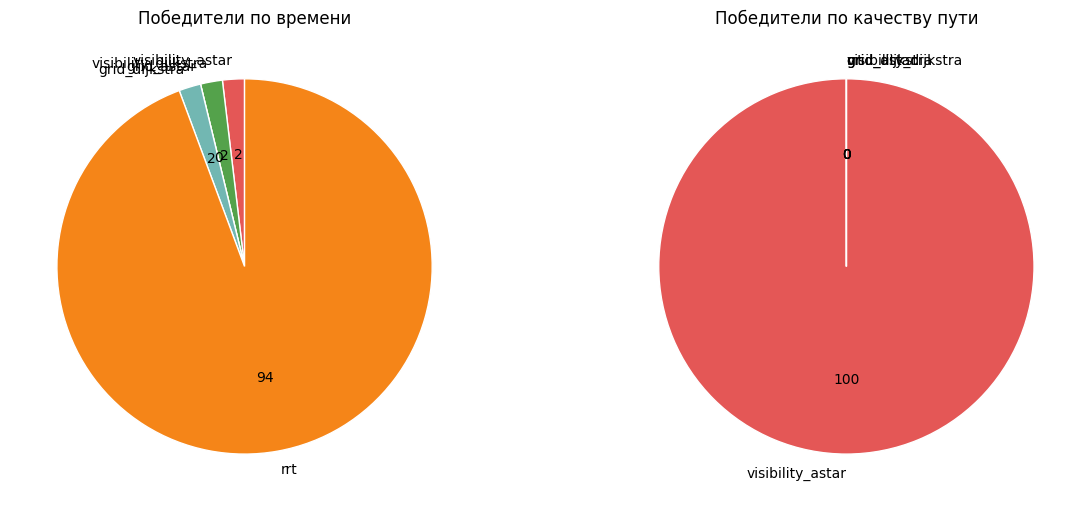

In [115]:
runtime_winner_counts = config_runtime_winners_df['algorithm_id'].value_counts().reindex(plot_order, fill_value=0)
quality_winner_counts = config_quality_winners_df['algorithm_id'].value_counts().reindex(plot_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, counts, title in [
    (axes[0], runtime_winner_counts, 'Победители по времени'),
    (axes[1], quality_winner_counts, 'Победители по качеству пути'),
]:
    labels = counts.index.tolist()
    values = counts.values
    colors = [ALGORITHM_COLORS[label] for label in labels]
    ax.pie(values, labels=labels, autopct='%1.0f', startangle=90, colors=colors, wedgeprops={'edgecolor': 'white'})
    ax.set_title(title)

winner_pies_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_winner_pies.png'
fig.savefig(winner_pies_path, dpi=180, bbox_inches='tight')
print('Saved:', winner_pies_path)
plt.show()

Один алгоритм может доминировать по времени, другой - по качеству пути. Поэтому итоговая рекомендация должна учитывать компромисс, а не только один показатель.

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_ecdf.png


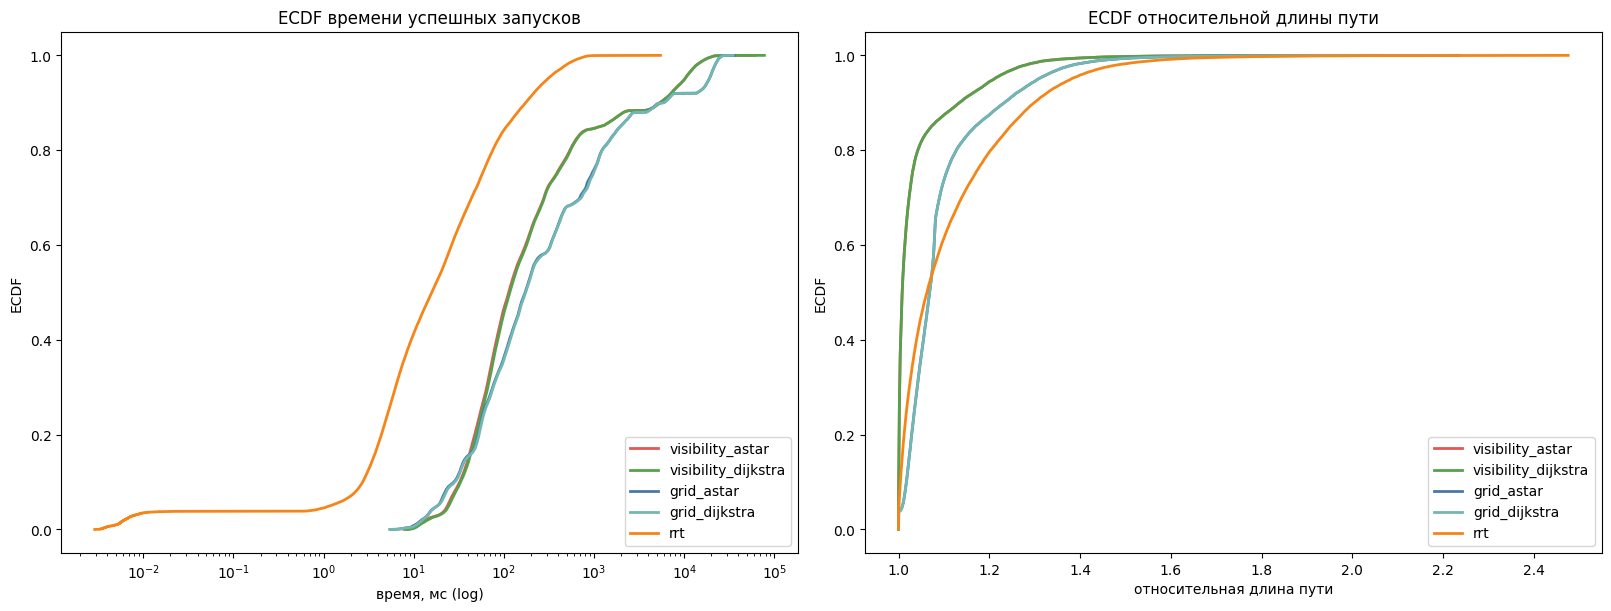

In [116]:
def build_ecdf(values):
    values = np.sort(np.asarray(values, dtype=float))
    y = np.arange(1, len(values) + 1) / len(values)
    return values, y

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
for algorithm_id in plot_order:
    runtime_values = SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'runtime_ms'].values
    x, y = build_ecdf(runtime_values)
    axes[0].plot(x, y, linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[0].set_xscale('log')
axes[0].set_title('ECDF времени успешных запусков')
axes[0].set_xlabel('время, мс (log)')
axes[0].set_ylabel('ECDF')
axes[0].legend(loc='lower right')

for algorithm_id in plot_order:
    quality_values = SUCCESS_RUNS_DF.loc[SUCCESS_RUNS_DF['algorithm_id'] == algorithm_id, 'relative_path_length'].values
    x, y = build_ecdf(quality_values)
    axes[1].plot(x, y, linewidth=2, label=algorithm_id, color=ALGORITHM_COLORS[algorithm_id])
axes[1].set_title('ECDF относительной длины пути')
axes[1].set_xlabel('относительная длина пути')
axes[1].set_ylabel('ECDF')
axes[1].legend(loc='lower right')

ecdf_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_ecdf.png'
fig.savefig(ecdf_path, dpi=180, bbox_inches='tight')
print('Saved:', ecdf_path)
plt.show()

ECDF-графики показывают всю функцию распределения. По ним можно судить о стабильности преимущества алгоритма, а не только о точечных статистиках вроде медианы.

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_runtime_quality_scatter.png


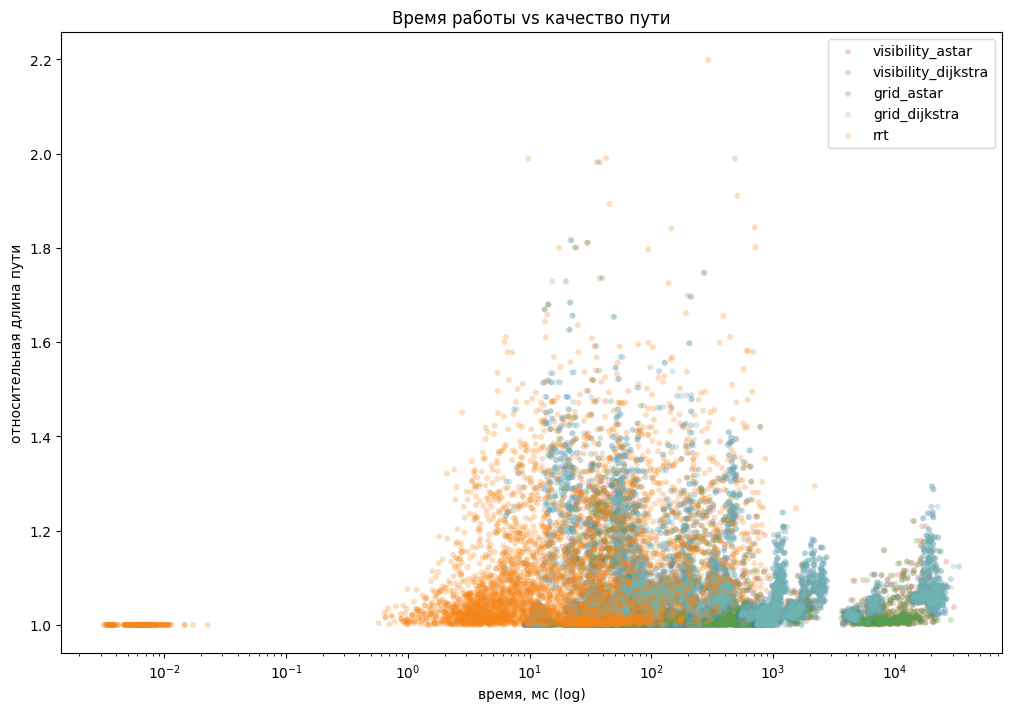

In [117]:
scatter_sample_df = SUCCESS_RUNS_DF.groupby('algorithm_id', group_keys=False).apply(lambda df: df.sample(min(len(df), 4000), random_state=42)).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
for algorithm_id in plot_order:
    algo_df = scatter_sample_df.loc[scatter_sample_df['algorithm_id'] == algorithm_id]
    ax.scatter(
        algo_df['runtime_ms'],
        algo_df['relative_path_length'],
        s=18,
        alpha=0.28,
        color=ALGORITHM_COLORS[algorithm_id],
        label=algorithm_id,
        edgecolors='none',
    )
ax.set_xscale('log')
ax.set_title('Время работы vs качество пути')
ax.set_xlabel('время, мс (log)')
ax.set_ylabel('относительная длина пути')
ax.legend(loc='upper right')

runtime_quality_scatter_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_runtime_quality_scatter.png'
fig.savefig(runtime_quality_scatter_path, dpi=180, bbox_inches='tight')
print('Saved:', runtime_quality_scatter_path)
plt.show()

Scatter-представление хорошо показывает пространство trade-off между скоростью и качеством маршрута. По нему видно, какие алгоритмы ближе к быстрой, а какие - к качественной части фронта решений.

### Итоговые таблицы по алгоритмам

In [118]:
summary_rows = []
for algorithm_id in plot_order:
    algo_corr_df = algorithm_metric_correlations_df.loc[
        algorithm_metric_correlations_df['algorithm_id'] == algorithm_id
    ].copy()

    top_success_row = algo_corr_df.iloc[algo_corr_df['success_spearman'].abs().argmax()]
    top_runtime_row = algo_corr_df.iloc[algo_corr_df['runtime_spearman'].abs().argmax()]
    top_quality_row = algo_corr_df.iloc[algo_corr_df['quality_spearman'].abs().argmax()]

    summary_rows.append({
        'algorithm_id': algorithm_id,
        'top_success_metric': SHORT_METRIC_LABELS[top_success_row['metric']],
        'top_success_corr': top_success_row['success_spearman'],
        'top_runtime_metric': SHORT_METRIC_LABELS[top_runtime_row['metric']],
        'top_runtime_corr': top_runtime_row['runtime_spearman'],
        'top_quality_metric': SHORT_METRIC_LABELS[top_quality_row['metric']],
        'top_quality_corr': top_quality_row['quality_spearman'],
    })

algorithm_summary_metrics_df = pd.DataFrame(summary_rows)

best_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmax()
weakest_success_algorithm = algorithm_overview_df['success_rate_executed'].idxmin()
fastest_success_algorithm = algorithm_overview_df['median_runtime_success_ms'].idxmin()
best_quality_algorithm = algorithm_overview_df['median_relative_path_length'].idxmin()

algorithm_key_results_df = pd.DataFrame([
    {
        'criterion': 'best_success_rate',
        'algorithm_id': best_success_algorithm,
        'value': algorithm_overview_df.loc[best_success_algorithm, 'success_rate_executed'],
    },
    {
        'criterion': 'weakest_success_rate',
        'algorithm_id': weakest_success_algorithm,
        'value': algorithm_overview_df.loc[weakest_success_algorithm, 'success_rate_executed'],
    },
    {
        'criterion': 'fastest_successful_runtime',
        'algorithm_id': fastest_success_algorithm,
        'value': algorithm_overview_df.loc[fastest_success_algorithm, 'median_runtime_success_ms'],
    },
    {
        'criterion': 'best_median_path_quality',
        'algorithm_id': best_quality_algorithm,
        'value': algorithm_overview_df.loc[best_quality_algorithm, 'median_relative_path_length'],
    },
])
algorithm_key_results_df['algorithm_label'] = algorithm_key_results_df['algorithm_id'].map(ALGORITHM_LABELS)

algorithm_summary_metrics_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_summary_metrics.csv'
algorithm_key_results_path = OUTPUT_DIR / f'{DATASET_PREFIX}_algorithm_key_results.csv'
algorithm_summary_metrics_df.to_csv(algorithm_summary_metrics_path, index=False)
algorithm_key_results_df.to_csv(algorithm_key_results_path, index=False)

print('Saved:', algorithm_summary_metrics_path)
print('Saved:', algorithm_key_results_path)

display(algorithm_key_results_df)
display(algorithm_summary_metrics_df)

Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_summary_metrics.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_algorithm_key_results.csv


,criterion,algorithm_id,value,algorithm_label
0,best_success_rate,visibility_astar,0.973522,Visibility A*
1,weakest_success_rate,rrt,0.926707,RRT
2,fastest_successful_runtime,rrt,15.855400,RRT
3,best_median_path_quality,visibility_astar,1.007930,Visibility A*


,algorithm_id,top_success_metric,top_success_corr,top_runtime_metric,top_runtime_corr,top_quality_metric,top_quality_corr
0,visibility_astar,largest_component_ratio,0.269994,scene_obstacle_count,0.956537,obstacle_area_ratio,0.813448
1,visibility_dijkstra,largest_component_ratio,0.269994,scene_obstacle_count,0.952961,obstacle_area_ratio,0.813448
2,grid_astar,largest_component_ratio,0.345807,scene_direct_distance,0.973229,obstacle_area_ratio,0.722728
3,grid_dijkstra,largest_component_ratio,0.345807,scene_direct_distance,0.973436,obstacle_area_ratio,0.722728
4,rrt,largest_component_ratio,0.365617,scene_direct_distance,0.661835,obstacle_area_ratio,0.737049


Итоговая интерпретация: универсально лучшего алгоритма по всем критериям нет. Если важнее надежность и качество пути, предпочтительны visibility-подходы; если приоритетом является скорость, наиболее выгоден RRT; grid-алгоритмы можно рассматривать как компромиссный вариант.

## Практические рекомендации

## Прогнозирование предпочтительного алгоритма по характеристикам сцены

Финальный блок строит модель, которая по параметрам сцены выбирает предпочтительный алгоритм. Целевая переменная формируется через score: успешность имеет приоритет, далее учитываются качество пути, время выполнения и устойчивость компромисса.

### Импорты и классы алгоритмов

In [119]:
from itertools import product

from sklearn.base import clone
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

RECOMMENDATION_ALGORITHMS = ['visibility_astar', 'grid_astar', 'rrt']
GRAPH_ALGORITHMS = ['visibility_astar', 'grid_astar']
RRT_ALGORITHM = 'rrt'
GRAPH_CLASS_LABEL = 'graph'

RECOMMENDATION_LABELS = {algorithm_id: ALGORITHM_LABELS[algorithm_id] for algorithm_id in RECOMMENDATION_ALGORITHMS}
SCENE_KEY_COLUMNS = ['config_index', 'scene_id']

### Признаки модели

Список включает исходные scene-level метрики и инженерные признаки, которые добавляются перед обучением.

In [120]:
RAW_SCENE_FEATURE_COLUMNS = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_obstacle_count',
    'scene_width',
    'scene_height',
    'scene_area',
    'scene_direct_distance',
    'scene_start_x',
    'scene_start_y',
    'scene_goal_x',
    'scene_goal_y',
    'config_start_goal_min_distance',
]

ENGINEERED_ML_FEATURE_COLUMNS = [
    'scene_obstacle_density',
    'scene_direct_distance_ratio',
    'scene_clearance_component_interaction',
    'scene_boundary_area_interaction',
    'scene_obstacle_clearance_ratio',
    'scene_radii_cell_interaction',
    'scene_obstacle_count_log',
    'scene_area_log',
    'scene_direct_distance_log',
    'scene_aspect_ratio',
    'scene_start_x_norm',
    'scene_start_y_norm',
    'scene_goal_x_norm',
    'scene_goal_y_norm',
    'scene_start_goal_dx_norm',
    'scene_start_goal_dy_norm',
    'scene_start_border_distance_norm',
    'scene_goal_border_distance_norm',
    'scene_start_center_distance_norm',
    'scene_goal_center_distance_norm',
    'scene_direct_distance_min_ratio',
]

ML_FEATURE_COLUMNS = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_obstacle_count',
    'scene_width',
    'scene_height',
    'scene_area',
    'scene_direct_distance',
    *ENGINEERED_ML_FEATURE_COLUMNS,
]

ML_FEATURE_LABELS = {
    'scene_metric_obstacle_area_ratio': 'obstacle area ratio',
    'scene_metric_boundary_density': 'boundary density',
    'scene_metric_cell_density_cv': 'cell density CV',
    'scene_metric_radii_cv': 'radii CV',
    'scene_metric_clearance': 'clearance',
    'scene_metric_largest_component_ratio': 'largest component ratio',
    'scene_obstacle_count': 'obstacle count',
    'scene_width': 'scene width',
    'scene_height': 'scene height',
    'scene_area': 'scene area',
    'scene_direct_distance': 'direct distance',
    'scene_obstacle_density': 'obstacle density',
    'scene_direct_distance_ratio': 'distance / sqrt(area)',
    'scene_clearance_component_interaction': 'clearance * component',
    'scene_boundary_area_interaction': 'boundary * area ratio',
    'scene_obstacle_clearance_ratio': 'area ratio / clearance',
    'scene_radii_cell_interaction': 'radii CV * cell CV',
    'scene_obstacle_count_log': 'log obstacle count',
    'scene_area_log': 'log scene area',
    'scene_direct_distance_log': 'log direct distance',
    'scene_aspect_ratio': 'scene aspect ratio',
    'scene_start_x_norm': 'start x / width',
    'scene_start_y_norm': 'start y / height',
    'scene_goal_x_norm': 'goal x / width',
    'scene_goal_y_norm': 'goal y / height',
    'scene_start_goal_dx_norm': '|goal x - start x| / width',
    'scene_start_goal_dy_norm': '|goal y - start y| / height',
    'scene_start_border_distance_norm': 'start border distance',
    'scene_goal_border_distance_norm': 'goal border distance',
    'scene_start_center_distance_norm': 'start center distance',
    'scene_goal_center_distance_norm': 'goal center distance',
    'scene_direct_distance_min_ratio': 'distance / min required distance',
}

### Параметры score и обучения

Успешный запуск имеет приоритет над неуспешным. Весовые коэффициенты score подбираются по сетке, чтобы не получать почти постоянную рекомендацию одного алгоритма.

In [121]:
EPSILON = 1e-9

SCORE_ALPHA = 2.0
FAILURE_SCORE_PENALTY = 1.0

DEFAULT_SCORE_BETA = 0.55
DEFAULT_SCORE_GAMMA = 0.70
DEFAULT_SCORE_DELTA = 0.90

SCORE_BETA_GRID = [0.30, 0.45, 0.60, 0.75, 0.90]
SCORE_GAMMA_GRID = [0.45, 0.60, 0.75, 0.90, 1.05]
SCORE_DELTA_GRID = [0.40, 0.60, 0.80, 1.00, 1.25, 1.50]

QUALITY_RUNTIME_TOLERANCE = 0.15
TARGET_MIN_CLASS_SHARE = 0.03
AUTOTUNE_CANDIDATE_LIMIT = 18
AUTOTUNE_PROXY_TEST_SIZE = 0.25
AUTOTUNE_MIN_CLASS_COUNT = 250
USE_AUTOTUNED_SCORE_PARAMS = True

MULTICLASS_BIAS_GRID = [0.80, 0.90, 1.00, 1.10, 1.25]
PERMUTATION_IMPORTANCE_REPEATS = 4

RANDOM_STATE = 42
TEST_SIZE = 0.20
VALIDATION_SIZE = 0.20
MODEL_OUTPUT_PREFIX = f'{DATASET_PREFIX}_ml_algorithm_recommendation'

### Формирование признаков, score и целевой переменной

Здесь подготавливаются признаки сцены, рассчитывается score для каждой пары сцена-алгоритм и выбирается целевой алгоритм для обучения модели.

### Исходная таблица для рекомендаций

In [122]:
missing_scene_feature_columns = [column for column in RAW_SCENE_FEATURE_COLUMNS if column not in analysis_run_df.columns]
if missing_scene_feature_columns:
    raise KeyError(f'Missing raw scene feature columns in analysis_run_df: {missing_scene_feature_columns}')

recommendation_source_columns = [
    *SCENE_KEY_COLUMNS,
    'config_name',
    'algorithm_id',
    'algorithm_status',
    'algorithm_was_executed',
    'path_found',
    'runtime_ms',
    'relative_path_length',
]

recommendation_source_df = (
    analysis_run_df.loc[
        analysis_run_df['algorithm_id'].isin(RECOMMENDATION_ALGORITHMS)
        & analysis_run_df['algorithm_was_executed'].fillna(False),
        recommendation_source_columns,
    ]
    .copy()
    .sort_values([*SCENE_KEY_COLUMNS, 'algorithm_id'])
    .reset_index(drop=True)
)

if recommendation_source_df.empty:
    raise ValueError('Recommendation source dataframe is empty. Check filters and dataset loading.')

scene_algorithm_duplicates = recommendation_source_df.duplicated(subset=[*SCENE_KEY_COLUMNS, 'algorithm_id']).sum()
if scene_algorithm_duplicates > 0:
    raise ValueError(f'Found duplicated scene/algorithm rows in recommendation_source_df: {scene_algorithm_duplicates}')

scene_feature_source_columns = [*SCENE_KEY_COLUMNS, 'config_name', *RAW_SCENE_FEATURE_COLUMNS]
scene_feature_df = (
    analysis_run_df[scene_feature_source_columns]
    .drop_duplicates(subset=[*SCENE_KEY_COLUMNS, 'config_name'])
    .reset_index(drop=True)
)

if scene_feature_df.empty:
    raise ValueError('Scene feature dataframe is empty. Check analysis_run_df construction.')

### Инженерные признаки сцены

In [123]:
def minmax_normalize(series: pd.Series, default_value: float = 0.0) -> pd.Series:
    numeric_series = pd.to_numeric(series, errors='coerce')
    if numeric_series.dropna().empty:
        return pd.Series(default_value, index=series.index, dtype=float)

    min_value = float(numeric_series.min(skipna=True))
    max_value = float(numeric_series.max(skipna=True))
    if not np.isfinite(min_value) or not np.isfinite(max_value) or np.isclose(min_value, max_value):
        return pd.Series(default_value, index=series.index, dtype=float)

    return ((numeric_series - min_value) / (max_value - min_value)).clip(lower=0.0, upper=1.0)


def add_engineered_ml_features(scene_df: pd.DataFrame) -> pd.DataFrame:
    feature_df = scene_df.copy()

    scene_area = pd.to_numeric(feature_df['scene_area'], errors='coerce').fillna(0.0).clip(lower=0.0)
    scene_width = pd.to_numeric(feature_df['scene_width'], errors='coerce').fillna(0.0).clip(lower=0.0)
    scene_height = pd.to_numeric(feature_df['scene_height'], errors='coerce').fillna(0.0).clip(lower=0.0)
    direct_distance = pd.to_numeric(feature_df['scene_direct_distance'], errors='coerce').fillna(0.0).clip(lower=0.0)
    obstacle_count = pd.to_numeric(feature_df['scene_obstacle_count'], errors='coerce').fillna(0.0).clip(lower=0.0)

    obstacle_area_ratio = pd.to_numeric(feature_df['scene_metric_obstacle_area_ratio'], errors='coerce').fillna(0.0).clip(lower=0.0)
    boundary_density = pd.to_numeric(feature_df['scene_metric_boundary_density'], errors='coerce').fillna(0.0).clip(lower=0.0)
    cell_density_cv = pd.to_numeric(feature_df['scene_metric_cell_density_cv'], errors='coerce').fillna(0.0).clip(lower=0.0)
    radii_cv = pd.to_numeric(feature_df['scene_metric_radii_cv'], errors='coerce').fillna(0.0).clip(lower=0.0)
    clearance = pd.to_numeric(feature_df['scene_metric_clearance'], errors='coerce').fillna(0.0).clip(lower=0.0)
    largest_component_ratio = pd.to_numeric(feature_df['scene_metric_largest_component_ratio'], errors='coerce').fillna(0.0).clip(lower=0.0)

    start_x = pd.to_numeric(feature_df['scene_start_x'], errors='coerce').fillna(0.0).clip(lower=0.0)
    start_y = pd.to_numeric(feature_df['scene_start_y'], errors='coerce').fillna(0.0).clip(lower=0.0)
    goal_x = pd.to_numeric(feature_df['scene_goal_x'], errors='coerce').fillna(0.0).clip(lower=0.0)
    goal_y = pd.to_numeric(feature_df['scene_goal_y'], errors='coerce').fillna(0.0).clip(lower=0.0)
    config_start_goal_min_distance = pd.to_numeric(feature_df['config_start_goal_min_distance'], errors='coerce').fillna(0.0).clip(lower=0.0)

    sqrt_area = np.sqrt(np.clip(scene_area, EPSILON, None))
    min_scene_side = np.minimum(scene_width, scene_height).clip(lower=EPSILON)
    half_width = scene_width / 2.0
    half_height = scene_height / 2.0

    feature_df['scene_obstacle_density'] = obstacle_count / np.clip(scene_area, EPSILON, None)
    feature_df['scene_direct_distance_ratio'] = direct_distance / sqrt_area
    feature_df['scene_clearance_component_interaction'] = clearance * largest_component_ratio
    feature_df['scene_boundary_area_interaction'] = boundary_density * obstacle_area_ratio
    feature_df['scene_obstacle_clearance_ratio'] = obstacle_area_ratio / np.clip(clearance, EPSILON, None)
    feature_df['scene_radii_cell_interaction'] = radii_cv * cell_density_cv
    feature_df['scene_obstacle_count_log'] = np.log1p(obstacle_count)
    feature_df['scene_area_log'] = np.log1p(scene_area)
    feature_df['scene_direct_distance_log'] = np.log1p(direct_distance)
    feature_df['scene_aspect_ratio'] = np.maximum(scene_width, scene_height) / min_scene_side

    feature_df['scene_start_x_norm'] = start_x / np.clip(scene_width, EPSILON, None)
    feature_df['scene_start_y_norm'] = start_y / np.clip(scene_height, EPSILON, None)
    feature_df['scene_goal_x_norm'] = goal_x / np.clip(scene_width, EPSILON, None)
    feature_df['scene_goal_y_norm'] = goal_y / np.clip(scene_height, EPSILON, None)
    feature_df['scene_start_goal_dx_norm'] = np.abs(goal_x - start_x) / np.clip(scene_width, EPSILON, None)
    feature_df['scene_start_goal_dy_norm'] = np.abs(goal_y - start_y) / np.clip(scene_height, EPSILON, None)

    start_border_distance = np.minimum.reduce([start_x, np.clip(scene_width - start_x, 0.0, None), start_y, np.clip(scene_height - start_y, 0.0, None)])
    goal_border_distance = np.minimum.reduce([goal_x, np.clip(scene_width - goal_x, 0.0, None), goal_y, np.clip(scene_height - goal_y, 0.0, None)])
    start_center_distance = np.sqrt((start_x - half_width) ** 2 + (start_y - half_height) ** 2)
    goal_center_distance = np.sqrt((goal_x - half_width) ** 2 + (goal_y - half_height) ** 2)

    feature_df['scene_start_border_distance_norm'] = start_border_distance / min_scene_side
    feature_df['scene_goal_border_distance_norm'] = goal_border_distance / min_scene_side
    feature_df['scene_start_center_distance_norm'] = start_center_distance / sqrt_area
    feature_df['scene_goal_center_distance_norm'] = goal_center_distance / sqrt_area
    feature_df['scene_direct_distance_min_ratio'] = direct_distance / np.clip(config_start_goal_min_distance, 1.0, None)

    return feature_df


scene_feature_df = add_engineered_ml_features(scene_feature_df)

missing_all_ml_features = [column for column in ML_FEATURE_COLUMNS if column not in scene_feature_df.columns]
if missing_all_ml_features:
    raise KeyError(f'Missing engineered ML feature columns after augmentation: {missing_all_ml_features}')

### Подготовка trade-off признаков и весов

In [124]:
def prepare_scene_tradeoff_frame(scene_group: pd.DataFrame) -> pd.DataFrame:
    group = scene_group.copy()
    success_mask = group['path_found'].fillna(False)
    group['success_value'] = success_mask.astype(float)
    group['scene_has_success'] = bool(success_mask.any())

    runtime_series = pd.to_numeric(group['runtime_ms'], errors='coerce').where(lambda s: s >= 0)
    runtime_fill = runtime_series.fillna(runtime_series.max(skipna=True) if runtime_series.notna().any() else 0.0)
    group['runtime_norm_scene'] = minmax_normalize(np.log1p(runtime_fill))

    relative_length = pd.to_numeric(group['relative_path_length'], errors='coerce')
    success_quality = np.clip(relative_length.fillna(1.0) - 1.0, 0.0, None)
    failure_proxy = float(success_quality.loc[success_mask].max()) + 1.0 if success_mask.any() else 1.0
    quality_raw = pd.Series(np.where(success_mask, success_quality, failure_proxy), index=group.index, dtype=float)
    group['quality_penalty_raw'] = quality_raw
    group['quality_norm_scene'] = minmax_normalize(quality_raw)

    group['tradeoff_imbalance'] = (group['runtime_norm_scene'] - group['quality_norm_scene']).abs()
    group['algorithm_label'] = group['algorithm_id'].map(ALGORITHM_LABELS)
    group['scene_uid'] = group['config_index'].astype(str) + '::' + group['scene_id'].astype(str)
    return group


def build_margin_weight_from_series(score_margin_series: pd.Series, base_weight: float = 0.75, scale: float = 100.0) -> pd.Series:
    margin_series = pd.to_numeric(score_margin_series, errors='coerce').fillna(0.0).clip(lower=0.0)
    return base_weight + minmax_normalize(np.log1p(margin_series * scale), default_value=0.0)


def build_training_sample_weight(scene_df: pd.DataFrame, index: pd.Index, target_series: pd.Series) -> pd.Series:
    margin_weight = build_margin_weight_from_series(scene_df.loc[index, 'score_margin_to_second'])
    class_weight = pd.Series(compute_sample_weight(class_weight='balanced', y=target_series), index=index, dtype=float)
    sample_weight = (margin_weight * class_weight).astype(float)
    return pd.Series(sample_weight.to_numpy(), index=index, dtype=float)


prepared_scene_frames = []
for _, scene_group in recommendation_source_df.groupby(SCENE_KEY_COLUMNS, sort=False):
    prepared_scene_frames.append(prepare_scene_tradeoff_frame(scene_group))

prepared_recommendation_df = pd.concat(prepared_scene_frames, ignore_index=True)

### Расчет score и scene-level датасета

In [125]:
def build_recommendation_artifacts(prepared_df: pd.DataFrame, beta: float, gamma: float, delta: float):
    scored_df = prepared_df.copy()
    success_mask = scored_df['path_found'].fillna(False)
    success_score = (
        SCORE_ALPHA
        - beta * scored_df['runtime_norm_scene']
        - gamma * scored_df['quality_norm_scene']
        - delta * scored_df['tradeoff_imbalance']
    )
    scored_df['score'] = np.where(success_mask, success_score, -FAILURE_SCORE_PENALTY)

    eligible_scores_df = scored_df.loc[scored_df['scene_has_success']].copy()
    eligible_scores_df = eligible_scores_df.sort_values(
        [*SCENE_KEY_COLUMNS, 'score', 'success_value', 'quality_norm_scene', 'runtime_norm_scene'],
        ascending=[True, True, False, False, True, True],
    ).reset_index(drop=True)
    eligible_scores_df['scene_rank'] = eligible_scores_df.groupby(SCENE_KEY_COLUMNS).cumcount() + 1

    winner_margin_df = (
        eligible_scores_df.groupby(SCENE_KEY_COLUMNS)['score']
        .agg(lambda s: float(s.iloc[0] - s.iloc[1]) if len(s) > 1 else np.nan)
        .rename('score_margin_to_second')
        .reset_index()
    )

    recommended_algorithm_df = (
        eligible_scores_df.loc[
            eligible_scores_df['scene_rank'] == 1,
            [*SCENE_KEY_COLUMNS, 'config_name', 'scene_uid', 'algorithm_id', 'algorithm_label', 'score']
        ]
        .rename(columns={'algorithm_id': 'target_algorithm', 'algorithm_label': 'target_algorithm_label', 'score': 'target_score'})
        .merge(winner_margin_df, on=SCENE_KEY_COLUMNS, how='left')
    )
    return scored_df, recommended_algorithm_df


def build_scene_level_dataset(recommended_df: pd.DataFrame) -> pd.DataFrame:
    scene_df = (
        scene_feature_df
        .merge(recommended_df, on=[*SCENE_KEY_COLUMNS, 'config_name'], how='inner')
        .sort_values(SCENE_KEY_COLUMNS)
        .reset_index(drop=True)
    )
    scene_df['scene_uid'] = scene_df['config_index'].astype(str) + '::' + scene_df['scene_id'].astype(str)
    return scene_df


def summarize_class_balance(scene_df: pd.DataFrame) -> dict:
    counts = scene_df['target_algorithm'].value_counts().reindex(RECOMMENDATION_ALGORITHMS, fill_value=0)
    shares = counts / counts.sum()
    positive_shares = shares.loc[shares > 0]

    if positive_shares.empty:
        entropy = 0.0
    else:
        entropy = float(-(positive_shares * np.log(positive_shares)).sum())

    normalized_entropy = entropy / np.log(len(RECOMMENDATION_ALGORITHMS)) if len(RECOMMENDATION_ALGORITHMS) > 1 else 1.0
    effective_class_count = float(np.exp(entropy))
    present_classes = int((counts > 0).sum())
    majority_share = float(shares.max())
    min_share = float(positive_shares.min()) if present_classes > 0 else 0.0
    balance_objective = normalized_entropy + min_share - majority_share

    summary = {
        'scene_rows': int(len(scene_df)),
        'present_classes': present_classes,
        'majority_share': majority_share,
        'min_share': min_share,
        'normalized_entropy': normalized_entropy,
        'effective_class_count': effective_class_count,
        'balance_objective': balance_objective,
        'meets_min_share_rule': bool(present_classes == len(RECOMMENDATION_ALGORITHMS) and min_share >= TARGET_MIN_CLASS_SHARE),
    }
    for algorithm_id in RECOMMENDATION_ALGORITHMS:
        summary[f'count_{algorithm_id}'] = int(counts.loc[algorithm_id])
        summary[f'share_{algorithm_id}'] = float(shares.loc[algorithm_id])
    return summary

### Проверка предсказуемости целевой переменной

In [126]:
def evaluate_target_predictability(scene_df: pd.DataFrame) -> dict:
    class_counts = scene_df['target_algorithm'].value_counts().reindex(RECOMMENDATION_ALGORITHMS, fill_value=0)
    present_class_counts = class_counts.loc[class_counts > 0]
    min_class_count = int(present_class_counts.min()) if not present_class_counts.empty else 0

    if scene_df['target_algorithm'].nunique() < len(RECOMMENDATION_ALGORITHMS):
        return {
            'proxy_status': 'missing_classes',
            'proxy_accuracy': np.nan,
            'proxy_balanced_accuracy': np.nan,
            'proxy_macro_f1': np.nan,
            'proxy_majority_accuracy': np.nan,
            'proxy_majority_macro_f1': np.nan,
            'proxy_macro_f1_gain': np.nan,
            'proxy_min_class_count': min_class_count,
        }

    if min_class_count < AUTOTUNE_MIN_CLASS_COUNT:
        return {
            'proxy_status': 'insufficient_class_rows',
            'proxy_accuracy': np.nan,
            'proxy_balanced_accuracy': np.nan,
            'proxy_macro_f1': np.nan,
            'proxy_majority_accuracy': np.nan,
            'proxy_majority_macro_f1': np.nan,
            'proxy_macro_f1_gain': np.nan,
            'proxy_min_class_count': min_class_count,
        }

    X_proxy = scene_df[ML_FEATURE_COLUMNS].copy()
    y_proxy = scene_df['target_algorithm'].copy()

    try:
        X_proxy_train, X_proxy_valid, y_proxy_train, y_proxy_valid = train_test_split(
            X_proxy,
            y_proxy,
            test_size=AUTOTUNE_PROXY_TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=y_proxy,
        )
    except ValueError:
        return {
            'proxy_status': 'split_failed',
            'proxy_accuracy': np.nan,
            'proxy_balanced_accuracy': np.nan,
            'proxy_macro_f1': np.nan,
            'proxy_majority_accuracy': np.nan,
            'proxy_majority_macro_f1': np.nan,
            'proxy_macro_f1_gain': np.nan,
            'proxy_min_class_count': min_class_count,
        }

    proxy_sample_weight = build_training_sample_weight(scene_df, X_proxy_train.index, y_proxy_train)
    proxy_pipeline = Pipeline(
        steps=[
            ('imputer', SimpleImputer(strategy='median')),
            (
                'model',
                ExtraTreesClassifier(
                    n_estimators=220,
                    max_depth=16,
                    min_samples_split=6,
                    min_samples_leaf=2,
                    max_features='sqrt',
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    proxy_pipeline.fit(X_proxy_train, y_proxy_train, model__sample_weight=proxy_sample_weight.to_numpy())
    y_proxy_pred = proxy_pipeline.predict(X_proxy_valid)

    proxy_majority_class = y_proxy_train.value_counts().idxmax()
    proxy_majority_pred = np.full(shape=len(y_proxy_valid), fill_value=proxy_majority_class, dtype=object)

    proxy_accuracy = accuracy_score(y_proxy_valid, y_proxy_pred)
    proxy_balanced_accuracy = balanced_accuracy_score(y_proxy_valid, y_proxy_pred)
    proxy_macro_f1 = f1_score(y_proxy_valid, y_proxy_pred, average='macro')
    proxy_majority_accuracy = accuracy_score(y_proxy_valid, proxy_majority_pred)
    proxy_majority_macro_f1 = f1_score(y_proxy_valid, proxy_majority_pred, average='macro')

    return {
        'proxy_status': 'ok',
        'proxy_accuracy': proxy_accuracy,
        'proxy_balanced_accuracy': proxy_balanced_accuracy,
        'proxy_macro_f1': proxy_macro_f1,
        'proxy_majority_accuracy': proxy_majority_accuracy,
        'proxy_majority_macro_f1': proxy_majority_macro_f1,
        'proxy_macro_f1_gain': proxy_macro_f1 - proxy_majority_macro_f1,
        'proxy_min_class_count': min_class_count,
    }

### Подбор параметров score

In [127]:
score_sensitivity_rows = []
for beta, gamma, delta in product(SCORE_BETA_GRID, SCORE_GAMMA_GRID, SCORE_DELTA_GRID):
    if gamma + QUALITY_RUNTIME_TOLERANCE < beta:
        continue

    _, candidate_recommended_df = build_recommendation_artifacts(
        prepared_recommendation_df,
        beta=beta,
        gamma=gamma,
        delta=delta,
    )
    candidate_scene_df = build_scene_level_dataset(candidate_recommended_df)
    balance_summary = summarize_class_balance(candidate_scene_df)
    score_sensitivity_rows.append({
        'beta': beta,
        'gamma': gamma,
        'delta': delta,
        **balance_summary,
    })

score_sensitivity_df = pd.DataFrame(score_sensitivity_rows)
if score_sensitivity_df.empty:
    raise ValueError('Score sensitivity grid is empty. Expand parameter ranges or relax constraints.')

balance_candidate_df = score_sensitivity_df.sort_values(
    ['meets_min_share_rule', 'present_classes', 'balance_objective', 'min_share', 'normalized_entropy', 'majority_share'],
    ascending=[False, False, False, False, False, True],
).reset_index(drop=True)

proxy_rows = []
for row in balance_candidate_df[['beta', 'gamma', 'delta']].drop_duplicates().head(AUTOTUNE_CANDIDATE_LIMIT).itertuples(index=False):
    _, candidate_recommended_df = build_recommendation_artifacts(
        prepared_recommendation_df,
        beta=float(row.beta),
        gamma=float(row.gamma),
        delta=float(row.delta),
    )
    candidate_scene_df = build_scene_level_dataset(candidate_recommended_df)
    proxy_rows.append({
        'beta': float(row.beta),
        'gamma': float(row.gamma),
        'delta': float(row.delta),
        **evaluate_target_predictability(candidate_scene_df),
    })

proxy_df = pd.DataFrame(proxy_rows)
score_sensitivity_df = balance_candidate_df.merge(proxy_df, on=['beta', 'gamma', 'delta'], how='left')
score_sensitivity_df['proxy_is_valid'] = score_sensitivity_df['proxy_status'].eq('ok')
score_sensitivity_df['proxy_objective'] = np.where(
    score_sensitivity_df['proxy_is_valid'],
    0.45 * score_sensitivity_df['proxy_macro_f1']
    + 0.25 * score_sensitivity_df['proxy_balanced_accuracy']
    + 0.20 * score_sensitivity_df['proxy_macro_f1_gain']
    + 0.10 * score_sensitivity_df['min_share'],
    np.nan,
)
score_sensitivity_df['proxy_objective_for_sort'] = score_sensitivity_df['proxy_objective'].fillna(-np.inf)
score_sensitivity_df['proxy_macro_f1_gain_for_sort'] = score_sensitivity_df['proxy_macro_f1_gain'].fillna(-np.inf)
score_sensitivity_df = score_sensitivity_df.sort_values(
    [
        'meets_min_share_rule',
        'present_classes',
        'proxy_is_valid',
        'proxy_objective_for_sort',
        'balance_objective',
        'min_share',
        'normalized_entropy',
        'proxy_macro_f1_gain_for_sort',
    ],
    ascending=[False, False, False, False, False, False, False, False],
).reset_index(drop=True)

score_sensitivity_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_score_sensitivity.csv'
score_sensitivity_df.to_csv(score_sensitivity_path, index=False)

### Применение выбранного score и сохранение датасетов

In [128]:
if USE_AUTOTUNED_SCORE_PARAMS and not score_sensitivity_df.empty:
    selected_params_row = score_sensitivity_df.iloc[0]
    SCORE_BETA = float(selected_params_row['beta'])
    SCORE_GAMMA = float(selected_params_row['gamma'])
    SCORE_DELTA = float(selected_params_row['delta'])
else:
    SCORE_BETA = DEFAULT_SCORE_BETA
    SCORE_GAMMA = DEFAULT_SCORE_GAMMA
    SCORE_DELTA = DEFAULT_SCORE_DELTA
    selected_params_row = pd.Series({
        'beta': SCORE_BETA,
        'gamma': SCORE_GAMMA,
        'delta': SCORE_DELTA,
        'scene_rows': np.nan,
        'present_classes': np.nan,
        'majority_share': np.nan,
        'min_share': np.nan,
        'normalized_entropy': np.nan,
        'effective_class_count': np.nan,
        'balance_objective': np.nan,
        'proxy_status': 'not_used',
        'proxy_accuracy': np.nan,
        'proxy_balanced_accuracy': np.nan,
        'proxy_macro_f1': np.nan,
        'proxy_majority_accuracy': np.nan,
        'proxy_majority_macro_f1': np.nan,
        'proxy_macro_f1_gain': np.nan,
        'proxy_objective': np.nan,
        'proxy_min_class_count': np.nan,
    })

recommendation_scored_df, recommended_algorithm_df = build_recommendation_artifacts(
    prepared_recommendation_df,
    beta=SCORE_BETA,
    gamma=SCORE_GAMMA,
    delta=SCORE_DELTA,
)

recommendation_scored_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_scores.parquet'
recommendation_scored_df.to_parquet(recommendation_scored_path, index=False)

ml_scene_df = build_scene_level_dataset(recommended_algorithm_df)
ml_scene_dataset_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_dataset.parquet'
ml_scene_df.to_parquet(ml_scene_dataset_path, index=False)

### Контрольные таблицы целевой переменной

In [129]:
class_distribution_df = (
    ml_scene_df['target_algorithm']
    .value_counts()
    .rename_axis('target_algorithm')
    .reset_index(name='scene_count')
    .assign(
        target_algorithm_label=lambda df: df['target_algorithm'].map(ALGORITHM_LABELS),
        share=lambda df: df['scene_count'] / df['scene_count'].sum(),
    )
)
class_distribution_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_class_distribution.csv'
class_distribution_df.to_csv(class_distribution_path, index=False)

selected_score_params_df = pd.DataFrame([
    {
        'alpha': SCORE_ALPHA,
        'beta': SCORE_BETA,
        'gamma': SCORE_GAMMA,
        'delta': SCORE_DELTA,
        'failure_score_penalty': FAILURE_SCORE_PENALTY,
        'quality_runtime_tolerance': QUALITY_RUNTIME_TOLERANCE,
        'target_min_class_share': TARGET_MIN_CLASS_SHARE,
        'autotuned': USE_AUTOTUNED_SCORE_PARAMS,
        'feature_count': len(ML_FEATURE_COLUMNS),
        'scene_rows': selected_params_row.get('scene_rows', np.nan),
        'present_classes': selected_params_row.get('present_classes', np.nan),
        'majority_share': selected_params_row.get('majority_share', np.nan),
        'min_share': selected_params_row.get('min_share', np.nan),
        'normalized_entropy': selected_params_row.get('normalized_entropy', np.nan),
        'effective_class_count': selected_params_row.get('effective_class_count', np.nan),
        'balance_objective': selected_params_row.get('balance_objective', np.nan),
        'proxy_status': selected_params_row.get('proxy_status', 'unknown'),
        'proxy_accuracy': selected_params_row.get('proxy_accuracy', np.nan),
        'proxy_balanced_accuracy': selected_params_row.get('proxy_balanced_accuracy', np.nan),
        'proxy_macro_f1': selected_params_row.get('proxy_macro_f1', np.nan),
        'proxy_majority_accuracy': selected_params_row.get('proxy_majority_accuracy', np.nan),
        'proxy_majority_macro_f1': selected_params_row.get('proxy_majority_macro_f1', np.nan),
        'proxy_macro_f1_gain': selected_params_row.get('proxy_macro_f1_gain', np.nan),
        'proxy_objective': selected_params_row.get('proxy_objective', np.nan),
        'proxy_min_class_count': selected_params_row.get('proxy_min_class_count', np.nan),
    }
])
selected_score_params_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_selected_score_params.csv'
selected_score_params_df.to_csv(selected_score_params_path, index=False)

print('Recommendation source rows:', len(recommendation_source_df))
print('Unique scene keys in source:', recommendation_source_df[SCENE_KEY_COLUMNS].drop_duplicates().shape[0])
print('Prepared scene-algorithm rows:', len(prepared_recommendation_df))
print('Scene-level ML rows:', len(ml_scene_df))
print('Selected score params:', {'beta': SCORE_BETA, 'gamma': SCORE_GAMMA, 'delta': SCORE_DELTA})
print('Selected feature count:', len(ML_FEATURE_COLUMNS))
print('Saved:', score_sensitivity_path)
print('Saved:', selected_score_params_path)
print('Saved:', recommendation_scored_path)
print('Saved:', ml_scene_dataset_path)
print('Saved:', class_distribution_path)

display(selected_score_params_df)
display(score_sensitivity_df.head(20))
display(class_distribution_df)
display(ml_scene_df.head(10))

Recommendation source rows: 127011
Unique scene keys in source: 42337
Prepared scene-algorithm rows: 127011
Scene-level ML rows: 41217
Selected score params: {'beta': 0.3, 'gamma': 0.6, 'delta': 0.8}
Selected feature count: 32
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_score_sensitivity.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_selected_score_params.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_scores.parquet
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_dataset.parquet
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_class_distribution.csv


,alpha,beta,gamma,delta,failure_score_penalty,quality_runtime_tolerance,target_min_class_share,autotuned,feature_count,scene_rows,...,balance_objective,proxy_status,proxy_accuracy,proxy_balanced_accuracy,proxy_macro_f1,proxy_majority_accuracy,proxy_majority_macro_f1,proxy_macro_f1_gain,proxy_objective,proxy_min_class_count
0,2.0,0.3,0.6,0.8,1.0,0.15,0.03,True,32,41217,...,0.909607,ok,0.668802,0.674311,0.667997,0.361863,0.177141,0.490855,0.595147,11458.0


,beta,gamma,delta,scene_rows,present_classes,majority_share,min_share,normalized_entropy,effective_class_count,balance_objective,...,proxy_balanced_accuracy,proxy_macro_f1,proxy_majority_accuracy,proxy_majority_macro_f1,proxy_macro_f1_gain,proxy_min_class_count,proxy_is_valid,proxy_objective,proxy_objective_for_sort,proxy_macro_f1_gain_for_sort
0,0.30,0.60,0.80,41217,3,0.361914,0.277992,0.993528,2.978746,0.909607,...,0.674311,0.667997,0.361863,0.177141,0.490855,11458.0,True,0.595147,0.595147,0.490855
1,0.45,0.75,1.25,41217,3,0.360070,0.301793,0.997614,2.992148,0.939338,...,0.669416,0.662433,0.360116,0.176513,0.485920,12439.0,True,0.592812,0.592812,0.485920
2,0.45,1.05,1.50,41217,3,0.347114,0.306985,0.998557,2.995249,0.958428,...,0.664673,0.661386,0.347113,0.171781,0.489605,12653.0,True,0.592411,0.592411,0.489605
3,0.30,0.75,1.00,41217,3,0.368392,0.285829,0.994930,2.983336,0.912367,...,0.666160,0.662899,0.368365,0.179467,0.483432,11781.0,True,0.590114,0.590114,0.483432
4,0.60,0.90,1.50,41217,3,0.368295,0.302399,0.997015,2.990179,0.931120,...,0.666625,0.659766,0.368268,0.179433,0.480334,12464.0,True,0.589858,0.589858,0.480334
5,0.30,1.05,1.50,41217,3,0.352355,0.320305,0.999231,2.997466,0.967181,...,0.659230,0.657845,0.352353,0.173699,0.484146,13202.0,True,0.589697,0.589697,0.484146
6,0.45,0.90,1.25,41217,3,0.358226,0.291215,0.996245,2.987649,0.929234,...,0.664506,0.660427,0.358273,0.175847,0.484580,12003.0,True,0.589356,0.589356,0.484580
7,0.75,0.90,1.50,41217,3,0.387122,0.302666,0.994174,2.980859,0.909718,...,0.668244,0.659294,0.387094,0.186045,0.473249,12475.0,True,0.588660,0.588660,0.473249
8,0.45,0.90,1.50,41217,3,0.349662,0.302230,0.997984,2.993363,0.950552,...,0.662487,0.657411,0.349636,0.172706,0.484704,12457.0,True,0.588620,0.588620,0.484704
9,0.60,1.05,1.50,41217,3,0.366402,0.294587,0.996376,2.988080,0.924561,...,0.663725,0.658936,0.366424,0.178775,0.480160,12142.0,True,0.587943,0.587943,0.480160


,target_algorithm,scene_count,target_algorithm_label,share
0,visibility_astar,14917,Visibility A*,0.361914
1,rrt,14842,RRT,0.360094
2,grid_astar,11458,Grid A*,0.277992


,config_index,scene_id,config_name,scene_metric_obstacle_area_ratio,scene_metric_boundary_density,scene_metric_cell_density_cv,scene_metric_radii_cv,scene_metric_clearance,scene_metric_largest_component_ratio,scene_obstacle_count,...,scene_start_border_distance_norm,scene_goal_border_distance_norm,scene_start_center_distance_norm,scene_goal_center_distance_norm,scene_direct_distance_min_ratio,scene_uid,target_algorithm,target_algorithm_label,target_score,score_margin_to_second
0,1,scene_1,final25_compact_uniform_micro_open,0.0313,0.045626,1.830641,0.225328,0.964286,1.000000,46,...,0.210714,0.238556,0.390258,0.366867,1.419301,1::scene_1,rrt,RRT,2.000000,0.643914
1,1,scene_10,final25_compact_uniform_micro_open,0.0292,0.040409,1.897611,0.213522,0.964286,1.000000,40,...,0.100402,0.115078,0.532390,0.490764,1.917749,1::scene_10,rrt,RRT,1.798228,0.898228
2,1,scene_100,final25_compact_uniform_micro_open,0.0328,0.043596,1.753453,0.207487,0.964286,1.000000,43,...,0.088450,0.167201,0.538629,0.435107,1.819267,1::scene_100,rrt,RRT,1.915119,1.015119
3,1,scene_101,final25_compact_uniform_micro_open,0.0257,0.035077,2.178808,0.219353,0.964286,0.999948,36,...,0.078893,0.213338,0.589435,0.397880,1.851199,1::scene_101,rrt,RRT,1.728229,0.828229
4,1,scene_102,final25_compact_uniform_micro_open,0.0259,0.041437,1.928672,0.209483,0.964286,1.000000,41,...,0.187841,0.125794,0.418376,0.479000,1.681962,1::scene_102,rrt,RRT,1.070828,0.170828
5,1,scene_103,final25_compact_uniform_micro_open,0.0336,0.046324,1.879556,0.222773,0.964286,1.000000,46,...,0.135794,0.194524,0.479895,0.402722,1.650171,1::scene_103,visibility_astar,Visibility A*,0.900000,0.064597
6,1,scene_104,final25_compact_uniform_micro_open,0.0249,0.039128,2.015514,0.224713,0.964286,1.000000,40,...,0.071965,0.152467,0.537991,0.468739,1.879637,1::scene_104,grid_astar,Grid A*,1.314751,0.414751
7,1,scene_105,final25_compact_uniform_micro_open,0.0231,0.035986,2.098836,0.217143,0.964286,1.000000,37,...,0.126029,0.076507,0.487231,0.590172,2.017398,1::scene_105,rrt,RRT,2.000000,0.699042
8,1,scene_106,final25_compact_uniform_micro_open,0.0292,0.043482,1.726149,0.226605,0.964286,1.000000,45,...,0.096263,0.151484,0.479098,0.466471,1.767375,1::scene_106,rrt,RRT,1.918958,1.018958
9,1,scene_107,final25_compact_uniform_micro_open,0.0348,0.048055,1.688091,0.214091,0.964286,0.999894,47,...,0.160200,0.146598,0.446023,0.471748,1.720741,1::scene_107,rrt,RRT,2.000000,0.638601


### Подбор score и стратегии классификации

Блок ниже выполняет быстрый совместный подбор параметров score, стратегии обучения и смещений классов, затем сохраняет метрики и диагностические таблицы.

### Настройки быстрого поиска

In [130]:
JOINT_SCORE_CANDIDATE_LIMIT = 3
TRAIN_MARGIN_TRIM_QUANTILES = [0.00, 0.05]
PERMUTATION_IMPORTANCE_REPEATS = 2
PERMUTATION_IMPORTANCE_MAX_FEATURES = 16
FAST_PROGRESS = True

FEATURE_IMPORTANCE_PRIORITY = [
    'scene_metric_obstacle_area_ratio',
    'scene_metric_boundary_density',
    'scene_metric_clearance',
    'scene_metric_largest_component_ratio',
    'scene_metric_cell_density_cv',
    'scene_metric_radii_cv',
    'scene_direct_distance',
    'scene_obstacle_count',
    'scene_width',
    'scene_height',
    'scene_obstacle_density',
    'scene_direct_distance_ratio',
    'scene_clearance_component_interaction',
    'scene_boundary_area_interaction',
    'scene_start_goal_dx_norm',
    'scene_start_goal_dy_norm',
]


def log_progress(message):
    if FAST_PROGRESS:
        print(f"[{pd.Timestamp.now():%H:%M:%S}] {message}", flush=True)

### Модели, вероятности и bias-коррекция

In [131]:
def build_model_candidates():
    return {
        'hist_gradient_boosting': Pipeline(
            steps=[
                ('imputer', SimpleImputer(strategy='median')),
                (
                    'model',
                    HistGradientBoostingClassifier(
                        learning_rate=0.06,
                        max_iter=220,
                        max_depth=10,
                        min_samples_leaf=28,
                        l2_regularization=0.05,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        'extra_trees': Pipeline(
            steps=[
                ('imputer', SimpleImputer(strategy='median')),
                (
                    'model',
                    ExtraTreesClassifier(
                        n_estimators=600,
                        max_depth=18,
                        min_samples_split=4,
                        min_samples_leaf=1,
                        max_features='sqrt',
                        class_weight='balanced_subsample',
                        random_state=RANDOM_STATE,
                        n_jobs=-1,
                    ),
                ),
            ]
        ),
    }


def predict_proba_frame(pipeline, X_eval, class_order):
    model_classes = [str(value) for value in pipeline.named_steps['model'].classes_]
    proba_df = pd.DataFrame(
        pipeline.predict_proba(X_eval),
        index=X_eval.index,
        columns=model_classes,
    )
    return proba_df.reindex(columns=class_order, fill_value=0.0)

### Метрики классификации и bias-коррекция

In [132]:
def evaluate_prediction_metrics(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
    }


def apply_class_bias(proba_df, bias_map):
    class_order = list(proba_df.columns)
    bias_vector = np.array([float(bias_map[class_name]) for class_name in class_order], dtype=float)
    adjusted_values = proba_df.to_numpy() * bias_vector
    predicted_indices = adjusted_values.argmax(axis=1)
    predicted_labels = pd.Series([class_order[index] for index in predicted_indices], index=proba_df.index, dtype=object)
    adjusted_df = pd.DataFrame(adjusted_values, index=proba_df.index, columns=class_order)
    return predicted_labels, adjusted_df

In [133]:
def tune_class_bias(y_true, proba_df):
    bias_rows = []
    for bias_values in product(MULTICLASS_BIAS_GRID, repeat=len(RECOMMENDATION_ALGORITHMS)):
        bias_map = dict(zip(RECOMMENDATION_ALGORITHMS, [float(value) for value in bias_values]))
        predicted_labels, _ = apply_class_bias(proba_df, bias_map)
        metric_values = evaluate_prediction_metrics(y_true, predicted_labels)
        bias_penalty = float(sum(abs(value - 1.0) for value in bias_map.values()))
        bias_rows.append({
            **metric_values,
            'bias_penalty': bias_penalty,
            **{f'bias_{class_name}': bias_map[class_name] for class_name in RECOMMENDATION_ALGORITHMS},
        })

    bias_search_df = (
        pd.DataFrame(bias_rows)
        .sort_values(['macro_f1', 'balanced_accuracy', 'accuracy', 'bias_penalty'], ascending=[False, False, False, True])
        .reset_index(drop=True)
    )
    best_bias_row = bias_search_df.iloc[0].to_dict()
    best_bias_map = {class_name: float(best_bias_row[f'bias_{class_name}']) for class_name in RECOMMENDATION_ALGORITHMS}
    best_predicted_labels, adjusted_df = apply_class_bias(proba_df, best_bias_map)
    return best_bias_row, best_predicted_labels, adjusted_df


def combine_hierarchical_probabilities(stage1_pipeline, stage2_pipeline, X_eval):
    stage1_proba_df = predict_proba_frame(stage1_pipeline, X_eval, [GRAPH_CLASS_LABEL, RRT_ALGORITHM])
    stage2_proba_df = predict_proba_frame(stage2_pipeline, X_eval, GRAPH_ALGORITHMS)
    combined_proba_df = pd.DataFrame(index=X_eval.index)
    combined_proba_df['visibility_astar'] = stage1_proba_df[GRAPH_CLASS_LABEL] * stage2_proba_df['visibility_astar']
    combined_proba_df['grid_astar'] = stage1_proba_df[GRAPH_CLASS_LABEL] * stage2_proba_df['grid_astar']
    combined_proba_df['rrt'] = stage1_proba_df[RRT_ALGORITHM]
    return combined_proba_df.reindex(columns=RECOMMENDATION_ALGORITHMS, fill_value=0.0)

### Разбиение выборки и функции обучения

In [134]:
def build_split_bundle(scene_df):
    X = scene_df[ML_FEATURE_COLUMNS].copy()
    y = scene_df['target_algorithm'].copy()

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train_full,
        y_train_full,
        test_size=VALIDATION_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_train_full,
    )

    train_sample_weight = build_training_sample_weight(scene_df, X_train.index, y_train)
    train_full_sample_weight = build_training_sample_weight(scene_df, X_train_full.index, y_train_full)

    return {
        'scene_df': scene_df,
        'X': X,
        'y': y,
        'X_train': X_train,
        'X_valid': X_valid,
        'X_train_full': X_train_full,
        'X_test': X_test,
        'y_train': y_train,
        'y_valid': y_valid,
        'y_train_full': y_train_full,
        'y_test': y_test,
        'train_sample_weight': train_sample_weight,
        'train_full_sample_weight': train_full_sample_weight,
        'train_margin_series': pd.to_numeric(scene_df.loc[X_train.index, 'score_margin_to_second'], errors='coerce').fillna(0.0),
        'train_full_margin_series': pd.to_numeric(scene_df.loc[X_train_full.index, 'score_margin_to_second'], errors='coerce').fillna(0.0),
    }

### Урезание обучающей выборки по margin

In [135]:
def get_trimmed_fit_parts(split_bundle, trim_quantile, full=False):
    X_key = 'X_train_full' if full else 'X_train'
    y_key = 'y_train_full' if full else 'y_train'
    weight_key = 'train_full_sample_weight' if full else 'train_sample_weight'
    margin_key = 'train_full_margin_series' if full else 'train_margin_series'

    X_base = split_bundle[X_key]
    y_base = split_bundle[y_key]
    weight_base = split_bundle[weight_key]
    margin_series = split_bundle[margin_key]

    if trim_quantile <= 0.0:
        threshold = float(margin_series.min())
        keep_index = margin_series.index
    else:
        threshold = float(margin_series.quantile(trim_quantile))
        keep_index = margin_series.loc[margin_series >= threshold].index

    trimmed_y = y_base.loc[keep_index]
    trimmed_class_counts = trimmed_y.value_counts().reindex(RECOMMENDATION_ALGORITHMS, fill_value=0)
    if (trimmed_class_counts <= 0).any():
        return None

    return {
        'X': X_base.loc[keep_index],
        'y': trimmed_y,
        'sample_weight': weight_base.loc[keep_index],
        'threshold': threshold,
        'trim_quantile': float(trim_quantile),
        'rows': int(len(keep_index)),
    }

### Обучение flat и hierarchical моделей

In [136]:
def fit_flat_pipeline(pipeline_template, fit_parts):
    fitted_pipeline = clone(pipeline_template)
    fitted_pipeline.fit(
        fit_parts['X'],
        fit_parts['y'],
        model__sample_weight=fit_parts['sample_weight'].to_numpy(),
    )
    return fitted_pipeline

In [137]:
def fit_hierarchical_pipelines(pipeline_template, fit_parts):
    stage1_pipeline = clone(pipeline_template)
    y_stage1 = pd.Series(
        np.where(fit_parts['y'].eq(RRT_ALGORITHM), RRT_ALGORITHM, GRAPH_CLASS_LABEL),
        index=fit_parts['y'].index,
        dtype=object,
    )
    stage1_pipeline.fit(
        fit_parts['X'],
        y_stage1,
        model__sample_weight=fit_parts['sample_weight'].to_numpy(),
    )

    graph_mask = fit_parts['y'].isin(GRAPH_ALGORITHMS)
    graph_y = fit_parts['y'].loc[graph_mask]
    if graph_y.nunique() < 2:
        return None, None

    stage2_pipeline = clone(pipeline_template)
    stage2_pipeline.fit(
        fit_parts['X'].loc[graph_mask],
        graph_y,
        model__sample_weight=fit_parts['sample_weight'].loc[graph_mask].to_numpy(),
    )
    return stage1_pipeline, stage2_pipeline

### Строка кандидата и признаки для permutation importance

In [138]:
def build_validation_candidate_row(candidate_name, strategy, base_model, score_info, fit_parts, best_row):
    return {
        'candidate_name': candidate_name,
        'strategy': strategy,
        'base_model': base_model,
        'component_models': base_model,
        'score_beta': float(score_info['beta']),
        'score_gamma': float(score_info['gamma']),
        'score_delta': float(score_info['delta']),
        'score_proxy_objective': float(score_info.get('proxy_objective', np.nan)),
        'score_proxy_macro_f1': float(score_info.get('proxy_macro_f1', np.nan)),
        'score_proxy_balanced_accuracy': float(score_info.get('proxy_balanced_accuracy', np.nan)),
        'score_min_share': float(score_info.get('min_share', np.nan)),
        'score_majority_share': float(score_info.get('majority_share', np.nan)),
        'train_trim_quantile': float(fit_parts['trim_quantile']),
        'train_trim_threshold': float(fit_parts['threshold']),
        'trimmed_train_rows': int(fit_parts['rows']),
        'validation_accuracy': float(best_row['accuracy']),
        'validation_balanced_accuracy': float(best_row['balanced_accuracy']),
        'validation_macro_f1': float(best_row['macro_f1']),
        'validation_weighted_f1': float(best_row['weighted_f1']),
        'validation_bias_penalty': float(best_row['bias_penalty']),
        **{f'bias_{class_name}': float(best_row[f'bias_{class_name}']) for class_name in RECOMMENDATION_ALGORITHMS},
    }


def select_feature_importance_candidates():
    ordered_features = [feature for feature in FEATURE_IMPORTANCE_PRIORITY if feature in ML_FEATURE_COLUMNS]
    remaining_features = [feature for feature in ML_FEATURE_COLUMNS if feature not in ordered_features]
    combined_features = ordered_features + remaining_features
    return combined_features[:PERMUTATION_IMPORTANCE_MAX_FEATURES]

### Запуск поиска кандидатов

In [139]:
base_model_builders = build_model_candidates()
score_candidate_pool = score_sensitivity_df.head(JOINT_SCORE_CANDIDATE_LIMIT).copy()
validation_candidate_rows = []
total_search_steps = len(score_candidate_pool) * len(TRAIN_MARGIN_TRIM_QUANTILES) * 3
completed_search_steps = 0

log_progress(
    f"Fast search started: {len(score_candidate_pool)} score candidates x "
    f"{len(TRAIN_MARGIN_TRIM_QUANTILES)} trim options x 3 strategies = {total_search_steps} fits"
)

[00:25:53] Fast search started: 3 score candidates x 2 trim options x 3 strategies = 18 fits


In [140]:
for score_index, score_row in enumerate(score_candidate_pool.itertuples(index=False), start=1):
    score_info = {
        'beta': float(score_row.beta),
        'gamma': float(score_row.gamma),
        'delta': float(score_row.delta),
        'proxy_objective': float(getattr(score_row, 'proxy_objective', np.nan)),
        'proxy_macro_f1': float(getattr(score_row, 'proxy_macro_f1', np.nan)),
        'proxy_balanced_accuracy': float(getattr(score_row, 'proxy_balanced_accuracy', np.nan)),
        'min_share': float(getattr(score_row, 'min_share', np.nan)),
        'majority_share': float(getattr(score_row, 'majority_share', np.nan)),
    }

    log_progress(
        f"Score candidate {score_index}/{len(score_candidate_pool)}: "
        f"beta={score_info['beta']:.2f}, gamma={score_info['gamma']:.2f}, delta={score_info['delta']:.2f}"
    )

    _, candidate_recommended_df = build_recommendation_artifacts(
        prepared_recommendation_df,
        beta=score_info['beta'],
        gamma=score_info['gamma'],
        delta=score_info['delta'],
    )
    candidate_scene_df = build_scene_level_dataset(candidate_recommended_df)
    split_bundle = build_split_bundle(candidate_scene_df)

    for train_trim_quantile in TRAIN_MARGIN_TRIM_QUANTILES:
        fit_parts = get_trimmed_fit_parts(split_bundle, train_trim_quantile, full=False)
        if fit_parts is None:
            log_progress(f"Trim {train_trim_quantile:.2f} skipped: at least one class disappeared")
            continue

        log_progress(
            f"  Trim {train_trim_quantile:.2f}: {fit_parts['rows']} train rows kept, evaluating strategies"
        )

        flat_hgb_pipeline = fit_flat_pipeline(base_model_builders['hist_gradient_boosting'], fit_parts)
        flat_hgb_proba_df = predict_proba_frame(flat_hgb_pipeline, split_bundle['X_valid'], RECOMMENDATION_ALGORITHMS)
        flat_hgb_best_row, _, _ = tune_class_bias(split_bundle['y_valid'], flat_hgb_proba_df)
        validation_candidate_rows.append(
            build_validation_candidate_row(
                candidate_name=f"flat::hist_gradient_boosting|b={score_info['beta']:.2f}|g={score_info['gamma']:.2f}|d={score_info['delta']:.2f}|trim={train_trim_quantile:.2f}",
                strategy='flat',
                base_model='hist_gradient_boosting',
                score_info=score_info,
                fit_parts=fit_parts,
                best_row=flat_hgb_best_row,
            )
        )
        completed_search_steps += 1
        log_progress(
            f"    [{completed_search_steps}/{total_search_steps}] flat HGB: macro_f1={flat_hgb_best_row['macro_f1']:.4f}, "
            f"balanced_accuracy={flat_hgb_best_row['balanced_accuracy']:.4f}"
        )

        hierarchy_stage1, hierarchy_stage2 = fit_hierarchical_pipelines(base_model_builders['hist_gradient_boosting'], fit_parts)
        if hierarchy_stage1 is not None and hierarchy_stage2 is not None:
            hierarchy_proba_df = combine_hierarchical_probabilities(hierarchy_stage1, hierarchy_stage2, split_bundle['X_valid'])
            hierarchy_best_row, _, _ = tune_class_bias(split_bundle['y_valid'], hierarchy_proba_df)
            validation_candidate_rows.append(
                build_validation_candidate_row(
                    candidate_name=f"hierarchical::hist_gradient_boosting|b={score_info['beta']:.2f}|g={score_info['gamma']:.2f}|d={score_info['delta']:.2f}|trim={train_trim_quantile:.2f}",
                    strategy='hierarchical',
                    base_model='hist_gradient_boosting',
                    score_info=score_info,
                    fit_parts=fit_parts,
                    best_row=hierarchy_best_row,
                )
            )
            log_progress(
                f"    [{completed_search_steps + 1}/{total_search_steps}] hierarchical HGB: "
                f"macro_f1={hierarchy_best_row['macro_f1']:.4f}, balanced_accuracy={hierarchy_best_row['balanced_accuracy']:.4f}"
            )
        else:
            hierarchy_best_row = {'macro_f1': np.nan, 'balanced_accuracy': np.nan}
            log_progress(f"    [{completed_search_steps + 1}/{total_search_steps}] hierarchical HGB skipped")
        completed_search_steps += 1

        flat_extra_trees_pipeline = fit_flat_pipeline(base_model_builders['extra_trees'], fit_parts)
        flat_extra_trees_proba_df = predict_proba_frame(flat_extra_trees_pipeline, split_bundle['X_valid'], RECOMMENDATION_ALGORITHMS)
        flat_extra_trees_best_row, _, _ = tune_class_bias(split_bundle['y_valid'], flat_extra_trees_proba_df)
        validation_candidate_rows.append(
            build_validation_candidate_row(
                candidate_name=f"flat::extra_trees|b={score_info['beta']:.2f}|g={score_info['gamma']:.2f}|d={score_info['delta']:.2f}|trim={train_trim_quantile:.2f}",
                strategy='flat',
                base_model='extra_trees',
                score_info=score_info,
                fit_parts=fit_parts,
                best_row=flat_extra_trees_best_row,
            )
        )
        completed_search_steps += 1
        log_progress(
            f"    [{completed_search_steps}/{total_search_steps}] flat ExtraTrees: "
            f"macro_f1={flat_extra_trees_best_row['macro_f1']:.4f}, balanced_accuracy={flat_extra_trees_best_row['balanced_accuracy']:.4f}"
        )

[00:25:53] Score candidate 1/3: beta=0.30, gamma=0.60, delta=0.80
[00:25:55]   Trim 0.00: 26378 train rows kept, evaluating strategies


d:\Programms\ANCD\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Programms\ANCD\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[00:26:05]     [1/18] flat HGB: macro_f1=0.6682, balanced_accuracy=0.6687
[00:26:15]     [2/18] hierarchical HGB: macro_f1=0.6684, balanced_accuracy=0.6660
[00:26:26]     [3/18] flat ExtraTrees: macro_f1=0.6626, balanced_accuracy=0.6570
[00:26:26]   Trim 0.05: 25059 train rows kept, evaluating strategies
[00:26:36]     [4/18] flat HGB: macro_f1=0.6721, balanced_accuracy=0.6691
[00:26:46]     [5/18] hierarchical HGB: macro_f1=0.6691, balanced_accuracy=0.6682
[00:26:58]     [6/18] flat ExtraTrees: macro_f1=0.6616, balanced_accuracy=0.6632
[00:26:58] Score candidate 2/3: beta=0.45, gamma=0.75, delta=1.25
[00:27:00]   Trim 0.00: 26378 train rows kept, evaluating strategies
[00:27:10]     [7/18] flat HGB: macro_f1=0.6620, balanced_accuracy=0.6608
[00:27:20]     [8/18] hierarchical HGB: macro_f1=0.6634, balanced_accuracy=0.6643
[00:27:34]     [9/18] flat ExtraTrees: macro_f1=0.6606, balanced_accuracy=0.6568
[00:27:34]   Trim 0.05: 25059 train rows kept, evaluating strategies
[00:27:46]     [

In [141]:
if not validation_candidate_rows:
    raise ValueError('Validation candidate table is empty. Fast search could not evaluate any configuration.')

validation_results_df = (
    pd.DataFrame(validation_candidate_rows)
    .sort_values(
        [
            'validation_macro_f1',
            'validation_balanced_accuracy',
            'validation_accuracy',
            'score_proxy_objective',
            'validation_bias_penalty',
            'trimmed_train_rows',
        ],
        ascending=[False, False, False, False, True, False],
    )
    .reset_index(drop=True)
)
validation_results_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_model_selection.csv'
validation_results_df.to_csv(validation_results_path, index=False)

### Выбор лучшей конфигурации и пересборка целевой переменной

In [142]:
selected_candidate_row = validation_results_df.iloc[0]
selected_candidate_name = str(selected_candidate_row['candidate_name'])
selected_strategy = str(selected_candidate_row['strategy'])
selected_beta = float(selected_candidate_row['score_beta'])
selected_gamma = float(selected_candidate_row['score_gamma'])
selected_delta = float(selected_candidate_row['score_delta'])
selected_train_trim_quantile = float(selected_candidate_row['train_trim_quantile'])
selected_bias_map = {
    class_name: float(selected_candidate_row[f'bias_{class_name}'])
    for class_name in RECOMMENDATION_ALGORITHMS
}

log_progress(
    f"Selected candidate: {selected_candidate_name} "
    f"(strategy={selected_strategy}, beta={selected_beta:.2f}, gamma={selected_gamma:.2f}, delta={selected_delta:.2f})"
)

SCORE_BETA = selected_beta
SCORE_GAMMA = selected_gamma
SCORE_DELTA = selected_delta

recommendation_scored_df, recommended_algorithm_df = build_recommendation_artifacts(
    prepared_recommendation_df,
    beta=SCORE_BETA,
    gamma=SCORE_GAMMA,
    delta=SCORE_DELTA,
)
ml_scene_df = build_scene_level_dataset(recommended_algorithm_df)
ml_scene_df = ml_scene_df.sort_values('scene_uid').reset_index(drop=True)

class_distribution_df = (
    ml_scene_df['target_algorithm']
    .value_counts()
    .reindex(RECOMMENDATION_ALGORITHMS, fill_value=0)
    .rename_axis('algorithm_id')
    .reset_index(name='scene_count')
)
class_distribution_df['algorithm_label'] = class_distribution_df['algorithm_id'].map(ALGORITHM_LABELS)
class_distribution_df['share'] = class_distribution_df['scene_count'] / class_distribution_df['scene_count'].sum()

recommendation_scored_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_scores.parquet'
recommendation_scored_df.to_parquet(recommendation_scored_path, index=False)
ml_scene_dataset_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_dataset.parquet'
ml_scene_df.to_parquet(ml_scene_dataset_path, index=False)
class_distribution_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_class_distribution.csv'
class_distribution_df.to_csv(class_distribution_path, index=False)

selected_score_row_df = score_sensitivity_df.loc[
    score_sensitivity_df['beta'].eq(SCORE_BETA)
    & score_sensitivity_df['gamma'].eq(SCORE_GAMMA)
    & score_sensitivity_df['delta'].eq(SCORE_DELTA)
].copy()
selected_score_row = selected_score_row_df.iloc[0].to_dict() if not selected_score_row_df.empty else {}

selected_score_params_df = pd.DataFrame([
    {
        'alpha': SCORE_ALPHA,
        'beta': SCORE_BETA,
        'gamma': SCORE_GAMMA,
        'delta': SCORE_DELTA,
        'failure_score_penalty': FAILURE_SCORE_PENALTY,
        'quality_runtime_tolerance': QUALITY_RUNTIME_TOLERANCE,
        'target_min_class_share': TARGET_MIN_CLASS_SHARE,
        'selection_stage': 'fast_joint_search',
        'selected_candidate': selected_candidate_name,
        'selected_strategy': selected_strategy,
        'selected_train_trim_quantile': selected_train_trim_quantile,
        'autotuned': True,
        'feature_count': len(ML_FEATURE_COLUMNS),
        'scene_rows': selected_score_row.get('scene_rows', len(ml_scene_df)),
        'present_classes': selected_score_row.get('present_classes', ml_scene_df['target_algorithm'].nunique()),
        'majority_share': selected_score_row.get('majority_share', np.nan),
        'min_share': selected_score_row.get('min_share', np.nan),
        'normalized_entropy': selected_score_row.get('normalized_entropy', np.nan),
        'proxy_objective': selected_score_row.get('proxy_objective', np.nan),
        'proxy_macro_f1': selected_score_row.get('proxy_macro_f1', np.nan),
        'proxy_balanced_accuracy': selected_score_row.get('proxy_balanced_accuracy', np.nan),
    }
])
selected_score_params_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_selected_score_params.csv'
selected_score_params_df.to_csv(selected_score_params_path, index=False)

[00:29:20] Selected candidate: flat::hist_gradient_boosting|b=0.30|g=0.60|d=0.80|trim=0.05 (strategy=flat, beta=0.30, gamma=0.60, delta=0.80)


### Финальное обучение и тестовые метрики

In [143]:
split_bundle = build_split_bundle(ml_scene_df)
final_fit_parts = get_trimmed_fit_parts(split_bundle, selected_train_trim_quantile, full=True)
if final_fit_parts is None:
    raise ValueError('Selected train trimming removed at least one class from the full training split.')

test_fitted_objects = {}
log_progress(
    f"Training final model on {final_fit_parts['rows']} rows after trim quantile {selected_train_trim_quantile:.2f}"
)

if selected_strategy == 'flat' and str(selected_candidate_row['base_model']) == 'hist_gradient_boosting':
    final_pipeline = fit_flat_pipeline(base_model_builders['hist_gradient_boosting'], final_fit_parts)
    test_fitted_objects['flat_pipeline'] = final_pipeline
    test_proba_df = predict_proba_frame(final_pipeline, split_bundle['X_test'], RECOMMENDATION_ALGORITHMS)

elif selected_strategy == 'flat' and str(selected_candidate_row['base_model']) == 'extra_trees':
    final_pipeline = fit_flat_pipeline(base_model_builders['extra_trees'], final_fit_parts)
    test_fitted_objects['flat_pipeline'] = final_pipeline
    test_proba_df = predict_proba_frame(final_pipeline, split_bundle['X_test'], RECOMMENDATION_ALGORITHMS)

elif selected_strategy == 'hierarchical':
    hierarchy_stage1, hierarchy_stage2 = fit_hierarchical_pipelines(base_model_builders['hist_gradient_boosting'], final_fit_parts)
    if hierarchy_stage1 is None or hierarchy_stage2 is None:
        raise ValueError('Failed to fit hierarchical model on the selected full training subset.')
    test_fitted_objects['hierarchy_stage1'] = hierarchy_stage1
    test_fitted_objects['hierarchy_stage2'] = hierarchy_stage2
    test_proba_df = combine_hierarchical_probabilities(hierarchy_stage1, hierarchy_stage2, split_bundle['X_test'])

else:
    raise ValueError(f'Unknown selected strategy: {selected_strategy}')

y_pred, adjusted_test_proba_df = apply_class_bias(test_proba_df, selected_bias_map)
y_pred = y_pred.astype(object)

majority_class = split_bundle['y_train_full'].value_counts().idxmax()
majority_pred = np.full(shape=len(split_bundle['y_test']), fill_value=majority_class, dtype=object)

metrics_df = pd.DataFrame([
    {
        'train_rows': len(split_bundle['X_train_full']),
        'validation_rows': len(split_bundle['X_valid']),
        'test_rows': len(split_bundle['X_test']),
        'train_rows_after_trim': int(final_fit_parts['rows']),
        'selected_train_trim_threshold': float(final_fit_parts['threshold']),
        'feature_count': len(ML_FEATURE_COLUMNS),
        'class_count': split_bundle['y'].nunique(),
        'selected_candidate': selected_candidate_name,
        'selected_strategy': selected_strategy,
        'selected_base_model': str(selected_candidate_row['base_model']),
        'selected_component_models': str(selected_candidate_row['component_models']),
        'selected_beta': SCORE_BETA,
        'selected_gamma': SCORE_GAMMA,
        'selected_delta': SCORE_DELTA,
        'selected_bias_visibility_astar': selected_bias_map['visibility_astar'],
        'selected_bias_grid_astar': selected_bias_map['grid_astar'],
        'selected_bias_rrt': selected_bias_map['rrt'],
        'validation_accuracy': float(selected_candidate_row['validation_accuracy']),
        'validation_balanced_accuracy': float(selected_candidate_row['validation_balanced_accuracy']),
        'validation_macro_f1': float(selected_candidate_row['validation_macro_f1']),
        'validation_weighted_f1': float(selected_candidate_row['validation_weighted_f1']),
        'accuracy': accuracy_score(split_bundle['y_test'], y_pred),
        'balanced_accuracy': balanced_accuracy_score(split_bundle['y_test'], y_pred),
        'macro_f1': f1_score(split_bundle['y_test'], y_pred, average='macro'),
        'weighted_f1': f1_score(split_bundle['y_test'], y_pred, average='weighted'),
        'majority_class': majority_class,
        'majority_baseline_accuracy': accuracy_score(split_bundle['y_test'], majority_pred),
        'majority_baseline_macro_f1': f1_score(split_bundle['y_test'], majority_pred, average='macro'),
        'model_vs_majority_accuracy_delta': accuracy_score(split_bundle['y_test'], y_pred) - accuracy_score(split_bundle['y_test'], majority_pred),
        'model_vs_majority_macro_f1_delta': f1_score(split_bundle['y_test'], y_pred, average='macro') - f1_score(split_bundle['y_test'], majority_pred, average='macro'),
        'median_train_score_margin': float(pd.to_numeric(ml_scene_df.loc[split_bundle['X_train_full'].index, 'score_margin_to_second'], errors='coerce').median()),
        'mean_train_sample_weight': float(split_bundle['train_full_sample_weight'].mean()),
    }
])
metrics_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)

classification_report_df = pd.DataFrame(
    classification_report(split_bundle['y_test'], y_pred, output_dict=True, zero_division=0)
).transpose()
classification_report_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_classification_report.csv'
classification_report_df.to_csv(classification_report_path)

confusion_labels = [algorithm_id for algorithm_id in RECOMMENDATION_ALGORITHMS if algorithm_id in split_bundle['y'].unique()]
confusion_df = pd.DataFrame(
    confusion_matrix(split_bundle['y_test'], y_pred, labels=confusion_labels),
    index=[ALGORITHM_LABELS[a] for a in confusion_labels],
    columns=[ALGORITHM_LABELS[a] for a in confusion_labels],
)
confusion_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_confusion_matrix.csv'
confusion_df.to_csv(confusion_path)

[00:29:22] Training final model on 31324 rows after trim quantile 0.05


### Важность признаков и тестовые прогнозы

In [144]:
def predict_with_selected_models(X_eval):
    if selected_strategy == 'flat':
        proba_eval_df = predict_proba_frame(test_fitted_objects['flat_pipeline'], X_eval, RECOMMENDATION_ALGORITHMS)
    elif selected_strategy == 'hierarchical':
        proba_eval_df = combine_hierarchical_probabilities(
            test_fitted_objects['hierarchy_stage1'],
            test_fitted_objects['hierarchy_stage2'],
            X_eval,
        )
    else:
        raise ValueError(f'Unknown selected strategy: {selected_strategy}')

    predicted_labels, _ = apply_class_bias(proba_eval_df, selected_bias_map)
    return predicted_labels


baseline_macro_f1 = f1_score(split_bundle['y_test'], y_pred, average='macro')
permutation_rng = np.random.default_rng(RANDOM_STATE)
feature_importance_rows = []
importance_feature_list = select_feature_importance_candidates()
log_progress(
    f"Permutation importance started for {len(importance_feature_list)} features with {PERMUTATION_IMPORTANCE_REPEATS} repeats"
)

for feature_index, feature_name in enumerate(importance_feature_list, start=1):
    repeat_importances = []
    for repeat_index in range(PERMUTATION_IMPORTANCE_REPEATS):
        X_permuted = split_bundle['X_test'].copy()
        X_permuted[feature_name] = permutation_rng.permutation(X_permuted[feature_name].to_numpy())
        y_permuted_pred = predict_with_selected_models(X_permuted)
        permuted_macro_f1 = f1_score(split_bundle['y_test'], y_permuted_pred, average='macro')
        repeat_importances.append(baseline_macro_f1 - permuted_macro_f1)

    feature_importance_rows.append({
        'feature': feature_name,
        'feature_label': ML_FEATURE_LABELS[feature_name],
        'importance': float(np.mean(repeat_importances)),
        'importance_std': float(np.std(repeat_importances)),
        'importance_source': 'manual_permutation_importance_fast',
        'selected_candidate': selected_candidate_name,
    })

    if feature_index == 1 or feature_index == len(importance_feature_list) or feature_index % 4 == 0:
        log_progress(f"  Feature importance {feature_index}/{len(importance_feature_list)}: {feature_name}")

feature_importance_df = (
    pd.DataFrame(feature_importance_rows)
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
feature_importance_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_feature_importance.csv'
feature_importance_df.to_csv(feature_importance_path, index=False)

adjusted_prediction_probability_matrix = adjusted_test_proba_df.to_numpy()
if adjusted_prediction_probability_matrix.shape[1] > 1:
    sorted_adjusted_prediction_probability_matrix = np.sort(adjusted_prediction_probability_matrix, axis=1)
    prediction_margin_to_second = sorted_adjusted_prediction_probability_matrix[:, -1] - sorted_adjusted_prediction_probability_matrix[:, -2]
else:
    prediction_margin_to_second = np.full(shape=len(adjusted_prediction_probability_matrix), fill_value=np.nan)

test_prediction_df = (
    ml_scene_df.loc[
        split_bundle['X_test'].index,
        ['scene_uid', 'scene_id', 'config_index', 'config_name', 'target_algorithm', 'target_algorithm_label', 'target_score', 'score_margin_to_second']
    ]
    .copy()
    .rename(columns={'target_algorithm': 'true_algorithm', 'target_algorithm_label': 'true_algorithm_label'})
)
test_prediction_df['predicted_algorithm'] = y_pred
test_prediction_df['predicted_algorithm_label'] = test_prediction_df['predicted_algorithm'].map(ALGORITHM_LABELS)
test_prediction_df['is_correct'] = test_prediction_df['true_algorithm'] == test_prediction_df['predicted_algorithm']
test_prediction_df['prediction_confidence'] = adjusted_test_proba_df.max(axis=1).to_numpy()
test_prediction_df['prediction_margin_to_second'] = prediction_margin_to_second
test_prediction_df = test_prediction_df.join(adjusted_test_proba_df.add_prefix('adjusted_proba_'))
test_prediction_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_test_predictions.csv'
test_prediction_df.to_csv(test_prediction_path, index=False)

[00:29:24] Permutation importance started for 16 features with 2 repeats
[00:29:24]   Feature importance 1/16: scene_metric_obstacle_area_ratio
[00:29:25]   Feature importance 4/16: scene_metric_largest_component_ratio
[00:29:26]   Feature importance 8/16: scene_obstacle_count
[00:29:26]   Feature importance 12/16: scene_direct_distance_ratio
[00:29:27]   Feature importance 16/16: scene_start_goal_dy_norm


### Итоговая визуализация и вывод артефактов

Selected candidate: flat::hist_gradient_boosting|b=0.30|g=0.60|d=0.80|trim=0.05
Selected score params: {'beta': 0.3, 'gamma': 0.6, 'delta': 0.8}
Selected train trim quantile: 0.05
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_model_selection.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_selected_score_params.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_scores.parquet
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_dataset.parquet
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_class_distribution.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_metrics.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_classification_report.csv
Saved: Q:\Diploma\python\analysis_outputs\final25_ml_algorithm_recommendation_confusion_matrix.csv
Saved: Q:\Diploma\python\analysis_out

,alpha,beta,gamma,delta,failure_score_penalty,quality_runtime_tolerance,target_min_class_share,selection_stage,selected_candidate,selected_strategy,...,autotuned,feature_count,scene_rows,present_classes,majority_share,min_share,normalized_entropy,proxy_objective,proxy_macro_f1,proxy_balanced_accuracy
0,2.0,0.3,0.6,0.8,1.0,0.15,0.03,fast_joint_search,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...,flat,...,True,32,41217,3,0.361914,0.277992,0.993528,0.595147,0.667997,0.674311


,algorithm_id,scene_count,algorithm_label,share
0,visibility_astar,14917,Visibility A*,0.361914
1,grid_astar,11458,Grid A*,0.277992
2,rrt,14842,RRT,0.360094


,candidate_name,strategy,base_model,component_models,score_beta,score_gamma,score_delta,score_proxy_objective,score_proxy_macro_f1,score_proxy_balanced_accuracy,...,train_trim_threshold,trimmed_train_rows,validation_accuracy,validation_balanced_accuracy,validation_macro_f1,validation_weighted_f1,validation_bias_penalty,bias_visibility_astar,bias_grid_astar,bias_rrt
0,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...,flat,hist_gradient_boosting,hist_gradient_boosting,0.30,0.60,0.80,0.5951,0.6680,0.6743,...,0.0251,25059,0.6705,0.6691,0.6721,0.6718,0.20,1.00,0.9,1.10
1,hierarchical::hist_gradient_boosting|b=0.45|g=...,hierarchical,hist_gradient_boosting,hist_gradient_boosting,0.45,1.05,1.50,0.5924,0.6614,0.6647,...,0.0001,26378,0.6704,0.6733,0.6711,0.6696,0.20,0.80,1.0,1.00
2,hierarchical::hist_gradient_boosting|b=0.45|g=...,hierarchical,hist_gradient_boosting,hist_gradient_boosting,0.45,1.05,1.50,0.5924,0.6614,0.6647,...,0.0428,25059,0.6704,0.6729,0.6696,0.6681,0.20,1.00,1.1,1.10
3,hierarchical::hist_gradient_boosting|b=0.30|g=...,hierarchical,hist_gradient_boosting,hist_gradient_boosting,0.30,0.60,0.80,0.5951,0.6680,0.6743,...,0.0251,25059,0.6660,0.6682,0.6691,0.6676,0.35,1.00,1.1,1.25
4,flat::hist_gradient_boosting|b=0.45|g=1.05|d=1...,flat,hist_gradient_boosting,hist_gradient_boosting,0.45,1.05,1.50,0.5924,0.6614,0.6647,...,0.0428,25059,0.6684,0.6659,0.6688,0.6688,0.60,1.25,0.9,1.25
5,hierarchical::hist_gradient_boosting|b=0.30|g=...,hierarchical,hist_gradient_boosting,hist_gradient_boosting,0.30,0.60,0.80,0.5951,0.6680,0.6743,...,0.0000,26378,0.6670,0.6660,0.6684,0.6680,0.35,1.10,1.0,1.25
6,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...,flat,hist_gradient_boosting,hist_gradient_boosting,0.30,0.60,0.80,0.5951,0.6680,0.6743,...,0.0000,26378,0.6654,0.6687,0.6682,0.6664,0.20,0.90,1.0,1.10
7,flat::hist_gradient_boosting|b=0.45|g=1.05|d=1...,flat,hist_gradient_boosting,hist_gradient_boosting,0.45,1.05,1.50,0.5924,0.6614,0.6647,...,0.0001,26378,0.6646,0.6655,0.6667,0.6658,0.20,0.90,1.0,1.10
8,hierarchical::hist_gradient_boosting|b=0.45|g=...,hierarchical,hist_gradient_boosting,hist_gradient_boosting,0.45,0.75,1.25,0.5928,0.6624,0.6694,...,0.0000,26378,0.6603,0.6643,0.6634,0.6603,0.30,0.90,0.9,1.10
9,flat::hist_gradient_boosting|b=0.45|g=0.75|d=1...,flat,hist_gradient_boosting,hist_gradient_boosting,0.45,0.75,1.25,0.5928,0.6624,0.6694,...,0.0399,25059,0.6590,0.6606,0.6631,0.6605,0.40,0.80,0.9,1.10


,train_rows,validation_rows,test_rows,train_rows_after_trim,selected_train_trim_threshold,feature_count,class_count,selected_candidate,selected_strategy,selected_base_model,...,balanced_accuracy,macro_f1,weighted_f1,majority_class,majority_baseline_accuracy,majority_baseline_macro_f1,model_vs_majority_accuracy_delta,model_vs_majority_macro_f1_delta,median_train_score_margin,mean_train_sample_weight
0,32973,6595,8244,31324,0.024763,32,3,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...,flat,hist_gradient_boosting,...,0.673063,0.674492,0.673191,visibility_astar,0.36196,0.177176,0.31065,0.497315,0.28222,1.308027


,precision,recall,f1-score,support
grid_astar,0.7042,0.6802,0.6920,2292.0000
rrt,0.5805,0.5977,0.5890,2968.0000
visibility_astar,0.7438,0.7413,0.7425,2984.0000
accuracy,0.6726,0.6726,0.6726,0.6726
macro avg,0.6761,0.6731,0.6745,8244.0000
weighted avg,0.6740,0.6726,0.6732,8244.0000


,feature,feature_label,importance,importance_std,importance_source,selected_candidate
0,scene_obstacle_density,obstacle density,0.141011,0.002002,manual_permutation_importance_fast,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...
1,scene_obstacle_count,obstacle count,0.047680,0.002357,manual_permutation_importance_fast,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...
2,scene_metric_clearance,clearance,0.041892,0.003050,manual_permutation_importance_fast,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...
3,scene_metric_boundary_density,boundary density,0.035651,0.000240,manual_permutation_importance_fast,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...
4,scene_height,scene height,0.019223,0.001878,manual_permutation_importance_fast,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...
5,scene_direct_distance,direct distance,0.018454,0.001683,manual_permutation_importance_fast,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...
6,scene_metric_obstacle_area_ratio,obstacle area ratio,0.015412,0.002351,manual_permutation_importance_fast,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...
7,scene_start_goal_dy_norm,|goal y - start y| / height,0.007172,0.000871,manual_permutation_importance_fast,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...
8,scene_boundary_area_interaction,boundary * area ratio,0.005247,0.001304,manual_permutation_importance_fast,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...
9,scene_metric_cell_density_cv,cell density CV,0.003047,0.001655,manual_permutation_importance_fast,flat::hist_gradient_boosting|b=0.30|g=0.60|d=0...


,scene_uid,scene_id,config_index,config_name,true_algorithm,true_algorithm_label,target_score,score_margin_to_second,predicted_algorithm,predicted_algorithm_label,is_correct,prediction_confidence,prediction_margin_to_second,adjusted_proba_visibility_astar,adjusted_proba_grid_astar,adjusted_proba_rrt
28430,43::scene_715,scene_715,43,final25_giant_rectangular_super_pressure,grid_astar,Grid A*,1.259598,0.359598,grid_astar,Grid A*,True,0.884668,0.869806,0.003524,0.884668,0.014862
21276,35::scene_695,scene_695,35,final25_medium_vertical_broken_mass,rrt,RRT,1.921012,0.821012,rrt,RRT,True,0.631705,0.275207,0.029614,0.356498,0.631705
32309,48::scene_610,scene_610,48,final25_ultra_tall_island_cascade,visibility_astar,Visibility A*,1.176681,0.131597,visibility_astar,Visibility A*,True,0.687606,0.454445,0.687606,0.090386,0.233161
36553,53::scene_221,scene_221,53,final25_giant_multimass_field,visibility_astar,Visibility A*,1.035332,0.123812,visibility_astar,Visibility A*,True,0.575473,0.290303,0.575473,0.285170,0.118438
28998,44::scene_506,scene_506,44,final25_giant_square_super_pressure,grid_astar,Grid A*,0.971330,0.071330,grid_astar,Grid A*,True,0.842589,0.790800,0.016710,0.842589,0.051788
25121,3::scene_616,scene_616,3,final25_compact_uniform_dense_wide_radii,rrt,RRT,1.905086,0.983385,rrt,RRT,True,0.579818,0.160607,0.007104,0.419210,0.579818
35223,51::scene_464,scene_464,51,final25_giant_corridor_pressure,visibility_astar,Visibility A*,1.187025,0.197383,visibility_astar,Visibility A*,True,0.897057,0.784772,0.897057,0.000780,0.112284
19117,33::scene_190,scene_190,33,final25_medium_multi_cluster_passages,rrt,RRT,1.683266,0.515769,visibility_astar,Visibility A*,False,0.582339,0.240762,0.582339,0.096422,0.341577
32459,48::scene_746,scene_746,48,final25_ultra_tall_island_cascade,grid_astar,Grid A*,1.100000,0.063773,visibility_astar,Visibility A*,False,0.483183,0.171080,0.483183,0.312102,0.187041
11098,22::scene_728,scene_728,22,final25_ultra_wide_long_route_dense,visibility_astar,Visibility A*,1.701477,0.399962,visibility_astar,Visibility A*,True,0.898121,0.787910,0.898121,0.001518,0.110211


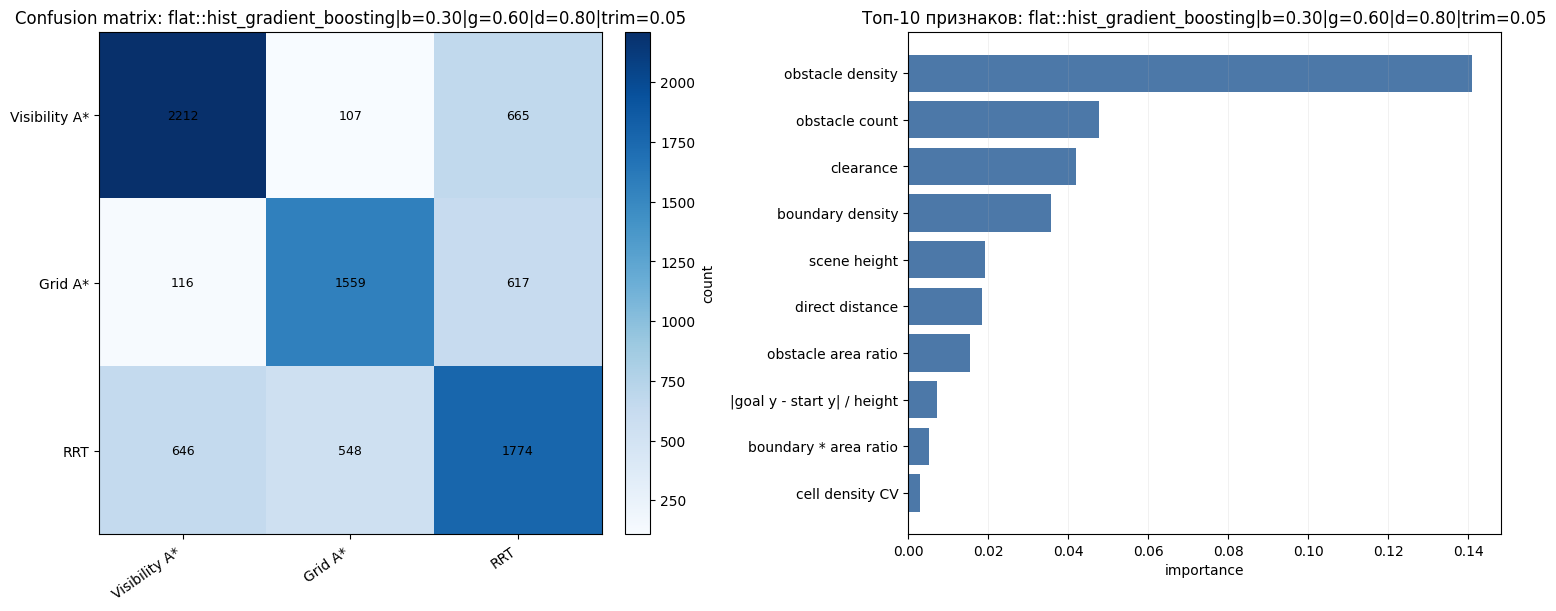

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

conf_image = axes[0].imshow(confusion_df.values, cmap='Blues')
axes[0].set_title(f'Confusion matrix: {selected_candidate_name}')
axes[0].set_xticks(range(len(confusion_df.columns)))
axes[0].set_xticklabels(confusion_df.columns, rotation=35, ha='right')
axes[0].set_yticks(range(len(confusion_df.index)))
axes[0].set_yticklabels(confusion_df.index)
for row_index in range(len(confusion_df.index)):
    for col_index in range(len(confusion_df.columns)):
        axes[0].text(col_index, row_index, int(confusion_df.iloc[row_index, col_index]), ha='center', va='center', fontsize=9)
fig.colorbar(conf_image, ax=axes[0], fraction=0.046, pad=0.04, label='count')

plot_importance_df = feature_importance_df.iloc[:10].sort_values('importance', ascending=True)
axes[1].barh(plot_importance_df['feature_label'], plot_importance_df['importance'], color='#4c78a8')
axes[1].set_title(f'Топ-10 признаков: {selected_candidate_name}')
axes[1].set_xlabel('importance')
axes[1].grid(axis='x', alpha=0.25, linewidth=0.5)

ml_figure_path = OUTPUT_DIR / f'{MODEL_OUTPUT_PREFIX}_summary.png'
fig.savefig(ml_figure_path, dpi=180, bbox_inches='tight')

print('Selected candidate:', selected_candidate_name)
print('Selected score params:', {'beta': SCORE_BETA, 'gamma': SCORE_GAMMA, 'delta': SCORE_DELTA})
print('Selected train trim quantile:', selected_train_trim_quantile)
print('Saved:', validation_results_path)
print('Saved:', selected_score_params_path)
print('Saved:', recommendation_scored_path)
print('Saved:', ml_scene_dataset_path)
print('Saved:', class_distribution_path)
print('Saved:', metrics_path)
print('Saved:', classification_report_path)
print('Saved:', confusion_path)
print('Saved:', feature_importance_path)
print('Saved:', test_prediction_path)
print('Saved:', ml_figure_path)

display(selected_score_params_df)
display(class_distribution_df)
display(validation_results_df.head(20).round(4))
display(metrics_df)
display(classification_report_df.round(4))
display(feature_importance_df.head(12))
display(test_prediction_df.head(12))

plt.show()

### Интерпретация ML-блока

Ключевые артефакты сохраняются в analysis_outputs: таблица подбора моделей, выбранные параметры score, метрики классификации, матрица ошибок, важность признаков и прогнозы на тестовой выборке.